# PyPSA-Eurelectric Analysis

**Works for any network** - uses `n.statistics` module which adapts to whatever components exist.

**Imports existing functions from pypsa-eur scripts:**
- `scripts/make_summary.py` → `calculate_costs`, `calculate_capacities`, `calculate_energy_balance`, `calculate_curtailment`, `calculate_prices`, `calculate_market_values`, `calculate_metrics`, `calculate_nodal_*` (all use `n.statistics` internally)
- `scripts/plot_summary.py` → `preferred_order`
- `scripts/_helpers.py` → `rename_techs`

**Flow visualization:** Uses PyPSA's built-in `n.plot(flow="mean")` with networkx backend.

**Outputs:** Energy mix, electricity mix, capacities, CO2, costs, curtailment, prices, flexibility, transmission (with flow maps), dispatch, market values, capacity factors - all with EU aggregate and country-by-country breakdown, exported to CSV/Excel.

> **Note:** This notebook must be placed in the main PyPSA-Eur model directory (where `scripts/` folder exists) because it uses relative imports from `scripts/make_summary.py`, `scripts/plot_summary.py`, and `scripts/_helpers.py`.

In [1]:
import sys
sys.path.insert(0, '.')

import logging
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

# Cartopy for maps (optional)
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    logging.warning("Cartopy not installed - map plots will be skipped")

# Import existing functions from pypsa-eur scripts
from scripts.make_summary import (
    assign_carriers, assign_locations,
    calculate_costs, calculate_capacities, calculate_energy, calculate_energy_balance,
    calculate_nodal_costs, calculate_nodal_capacities, calculate_nodal_energy_balance,
    calculate_capacity_factors, calculate_nodal_capacity_factors,
    calculate_curtailment, calculate_prices, calculate_weighted_prices,
    calculate_market_values, calculate_metrics
)
from scripts.plot_summary import preferred_order, plot_costs, plot_energy, plot_balances
from scripts._helpers import rename_techs

# Logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Style
sns.set_theme("paper", style="whitegrid")
plt.style.use("bmh")

# PyPSA statistics config
pypsa.set_option("params.statistics.round", 3)
pypsa.set_option("params.statistics.drop_zero", False)
pypsa.set_option("params.statistics.nice_names", False)

RESULTS_DIR = Path('results')
OUTPUT_DIR = Path('analysis_output')
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# =============================================================================
# CONFIGURE NETWORK PATH HERE
# =============================================================================
# Provide the path to your solved network file (.nc format)
# Example: NETWORK_PATH = "results/my_run/networks/elec_s_37_lv1.0__Co2L0.7-1H-T-H-B-I-A-dist1_2050.nc"

NETWORK_PATH = "uploaded_networks/base_s_37___2030_very_concervative.nc"  # <-- SET YOUR NETWORK PATH HERE

# If NETWORK_PATH is None, attempt to find the first available network in results/
if NETWORK_PATH is None:
    networks_found = []
    if RESULTS_DIR.exists():
        for d in RESULTS_DIR.iterdir():
            if d.is_dir() and (d / 'networks').exists():
                for nc in (d / 'networks').glob('*.nc'):
                    networks_found.append(nc)
    if networks_found:
        NETWORK_PATH = networks_found[0]
        logger.info(f"Auto-detected network: {NETWORK_PATH}")
    else:
        raise FileNotFoundError(
            "No networks found. Please set NETWORK_PATH manually, e.g.:\n"
            "NETWORK_PATH = 'results/my_run/networks/elec_s_37_lv1.0__Co2L0.7-1H-T-H-B-I-A-dist1_2050.nc'"
        )
else:
    NETWORK_PATH = Path(NETWORK_PATH)
    if not NETWORK_PATH.exists():
        raise FileNotFoundError(f"Network file not found: {NETWORK_PATH}")

print(f"Using network: {NETWORK_PATH}")

Using network: uploaded_networks/base_s_37___2030_very_concervative.nc


In [5]:
n = pypsa.Network(NETWORK_PATH)
n.links.to_csv("links.csv")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [41]:
# Load the network
n = pypsa.Network(str(NETWORK_PATH))

# Use existing helper functions from make_summary.py
assign_carriers(n)
assign_locations(n)

# Load plotting config
with open('config/plotting.default.yaml', 'r') as f:
    plotting_config = yaml.safe_load(f).get('plotting', {})
tech_colors = plotting_config.get('tech_colors', {})

# Update carrier colors
n.carriers.update({"color": tech_colors})
mask = n.carriers.color.isna() | n.carriers.color.eq("")
n.carriers["color"] = n.carriers.color.mask(mask, "lightgrey")

logger.info(f"Loaded: {NETWORK_PATH}")
print(f"Network: {NETWORK_PATH.name}")
print(f"Snapshots: {len(n.snapshots)}, Buses: {len(n.buses)}")
print(f"Generators: {len(n.generators)}, Links: {len(n.links)}, Stores: {len(n.stores)}")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.5)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
/home/abi/projects/pypsa-eurelectric/scripts/make_summary.py:43: DeprecatedWarning:

iterate_components is deprecated as of 1.0rc1 and will be removed in 2.0. Use `for component in n.components` instead.

/home/abi/projects/pypsa-eurelectric/scripts/make_summary.py:44: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

/home/abi/projects/pypsa-eurelectric/scripts/make_summary.py:44: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

/home/abi/projects/pypsa-eurelectric/scripts/make_summary.py:44: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

/home/abi/projects/pypsa-eurelectric/scripts/make_summar

Network: base_s_37___2030_very_concervative.nc
Snapshots: 2920, Buses: 977
Generators: 601, Links: 2793, Stores: 815


In [43]:
# Export helper
def export_df(df, name, excel_writer=None):
    """Export DataFrame to CSV and optionally to Excel sheet."""
    csv_path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(csv_path)
    logger.info(f"Exported: {csv_path}")
    if excel_writer is not None:
        df.to_excel(excel_writer, sheet_name=name[:31])
    return df

def get_country(bus):
    """Extract 2-letter country code from bus name."""
    return str(bus)[:2]

# Colors for plotting
colors = n.carriers.set_index("nice_name").color.where(lambda s: s != "", "lightgrey")

# AC buses (needed for price calculations)
ac_buses = n.buses[n.buses.carrier == 'AC'].index

# Renewable generators
re_carriers = ['solar', 'solar-hsat', 'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float']
re_g = n.generators[n.generators.carrier.isin(re_carriers)].index

# Flexibility link indices (battery, H2)
bc = n.links[n.links.carrier == 'battery charger'].index
bd = n.links[n.links.carrier == 'battery discharger'].index
he = n.links[n.links.carrier == 'H2 electrolysis'].index
hf = n.links[n.links.carrier == 'H2 fuel cell'].index

## 1. Energy Mix (All Vectors)

In [44]:
# FINAL ENERGY DEMAND + MIX (includes time-series + static loads)

import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

w = n.snapshot_weightings.objective if hasattr(n.snapshot_weightings, "objective") else pd.Series(1.0, index=n.snapshots)
hours = float(w.sum())

# --- Build annual MWh per load (robust: time-series + static) ---
all_loads = n.loads.index
ts_cols = n.loads_t.p_set.columns if hasattr(n.loads_t, "p_set") else pd.Index([])
static_loads = all_loads.difference(ts_cols)

# time-varying loads
energy_ts = (
    n.loads_t.p_set[ts_cols].mul(w, axis=0).sum(axis=0)
    if len(ts_cols) else pd.Series(dtype=float)
)

# static loads (MW * weighted hours)
if "p_set" in n.loads.columns and len(static_loads):
    energy_static = n.loads.loc[static_loads, "p_set"].fillna(0.0) * hours
else:
    energy_static = pd.Series(dtype=float)

load_energy_mwh = pd.concat([energy_ts, energy_static]).groupby(level=0).sum()

# --- Metadata and grouping ---
meta = n.loads.loc[load_energy_mwh.index].copy()
meta["bus_carrier"] = meta["bus"].map(n.buses["carrier"])
meta["energy_mwh"] = load_energy_mwh.values

# final demand by vector
final_by_vector_twh = (meta.groupby("bus_carrier")["energy_mwh"].sum() / 1e6).sort_values(ascending=False)
final_by_vector_twh = final_by_vector_twh[final_by_vector_twh > 0.01]

# final demand by load carrier (this is where industry/agriculture should appear)
final_by_load_carrier_twh = (meta.groupby("carrier")["energy_mwh"].sum() / 1e6).sort_values(ascending=False)
final_by_load_carrier_twh = final_by_load_carrier_twh[final_by_load_carrier_twh > 0.01]

# tables
vec_df = pd.DataFrame({
    "TWh": final_by_vector_twh.round(2),
    "Share (%)": (final_by_vector_twh / final_by_vector_twh.sum() * 100).round(1),
})

car_df = pd.DataFrame({
    "TWh": final_by_load_carrier_twh.round(2),
    "Share (%)": (final_by_load_carrier_twh / final_by_load_carrier_twh.sum() * 100).round(1),
})

print("=== FINAL ENERGY DEMAND BY VECTOR ===")
print(vec_df.to_string())
print(f"\nTotal final demand: {final_by_vector_twh.sum():.2f} TWh")

print("\n=== FINAL ENERGY MIX BY LOAD CARRIER ===")
print(car_df.to_string())

# quick check for missing categories
print("\nIndustry/Agriculture check:")
print(car_df[car_df.index.str.contains("industry|agriculture", case=False, na=False)].to_string())

# save
vec_df.to_csv(OUTPUT_DIR / "final_energy_by_vector.csv")
car_df.to_csv(OUTPUT_DIR / "final_energy_by_load_carrier.csv")

=== FINAL ENERGY DEMAND BY VECTOR ===
                                TWh  Share (%)
bus_carrier                                   
low voltage                 2764.94       23.6
urban decentral heat        1589.02       13.6
land transport oil          1563.41       13.3
gas for industry             994.73        8.5
rural heat                   828.01        7.1
urban central heat           803.37        6.9
naphtha for industry         790.97        6.7
kerosene for aviation        741.23        6.3
shipping oil                 490.88        4.2
solid biomass for industry   423.67        3.6
coal for industry            376.93        3.2
EV battery                   120.62        1.0
H2                            99.28        0.8
shipping methanol             75.33        0.6
agriculture machinery oil     51.24        0.4
industry methanol              8.74        0.1

Total final demand: 11722.36 TWh

=== FINAL ENERGY MIX BY LOAD CARRIER ===
                                       T

## 2. Electricity Mix

=== ELECTRICITY MIX (TWh and %) - Bus carriers: ['AC', 'low voltage'] ===
                                   TWh  Share (%)
electricity distribution grid  2737.41       36.8
transmission lines             1310.63       17.6
nuclear                         650.46        8.7
onshore wind                    564.75        7.6
hydroelectricity                513.64        6.9
solar rooftop                   429.83        5.8
offshore wind (AC)              336.71        4.5
CHP                             323.38        4.3
solar PV                        231.43        3.1
solar-hsat                      130.22        1.7
CCGT                            121.29        1.6
offshore wind (DC)               57.88        0.8
industry dsr discharge           27.18        0.4
OCGT                              7.49        0.1
V2G                               0.18        0.0

Total Electricity Supply: 7442.47 TWh


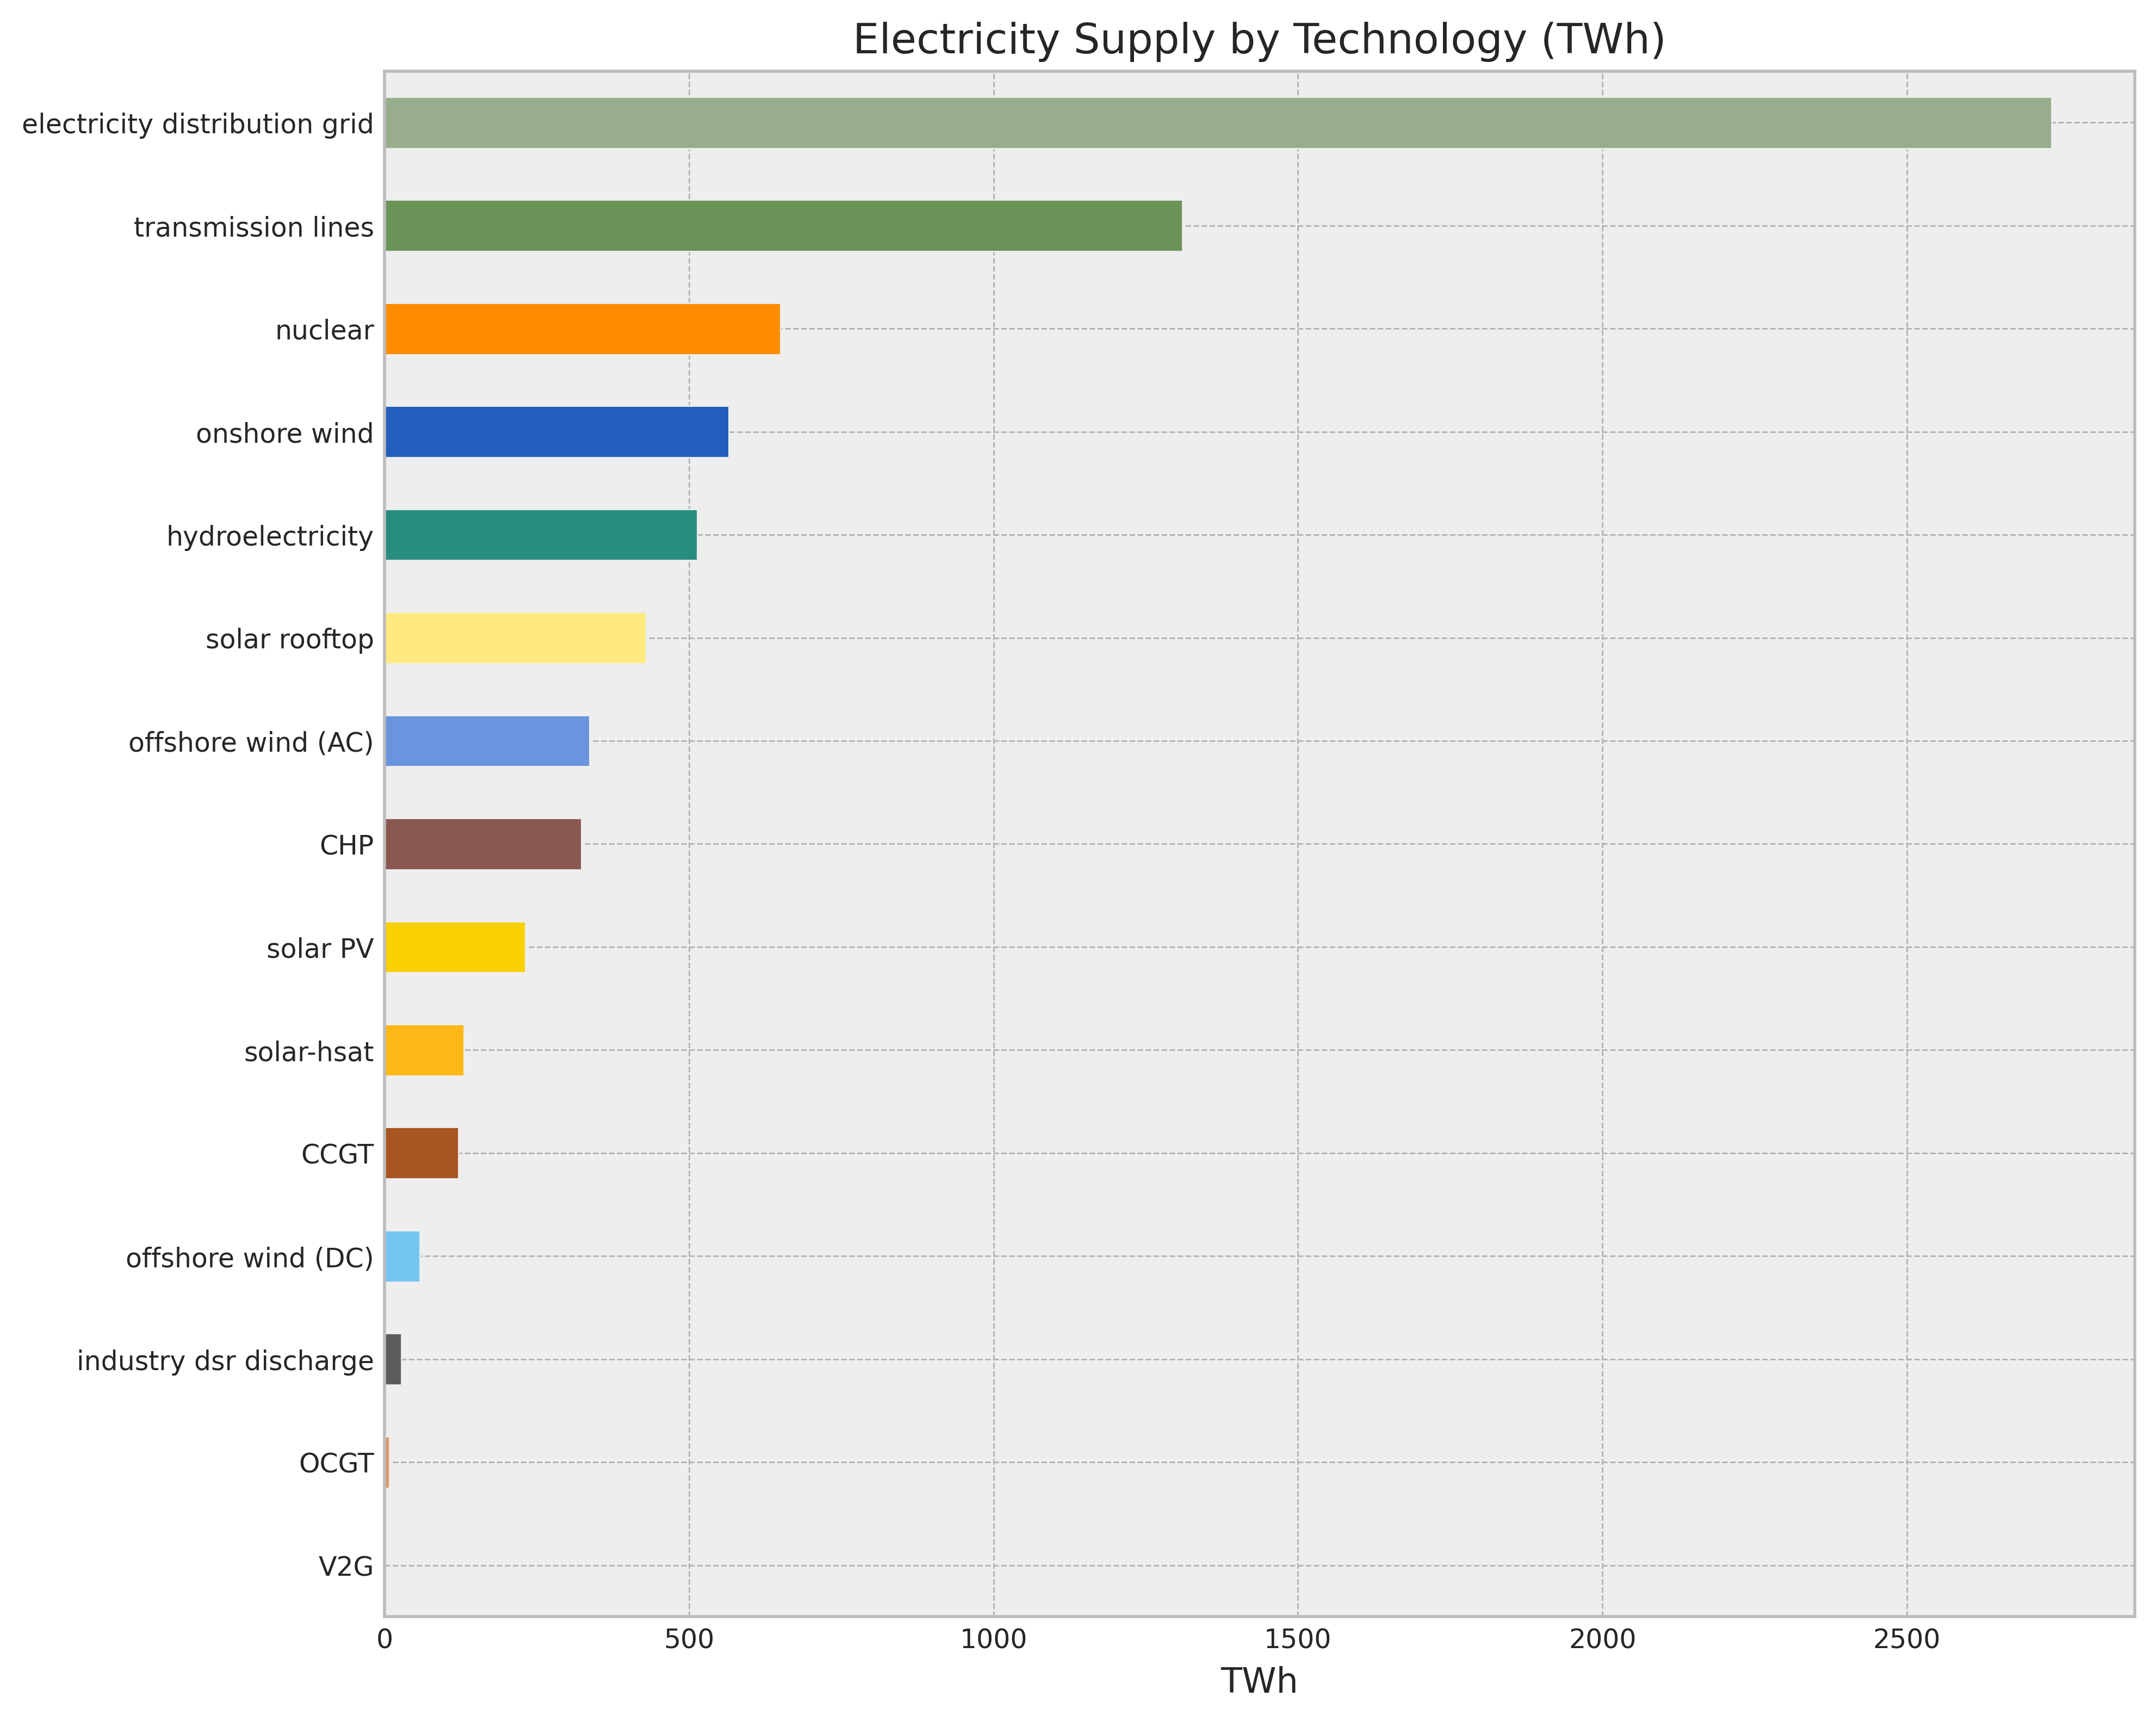

In [45]:
# 2. ELECTRICITY MIX - Using n.statistics.supply() for proper snapshot weighting
# Filter to only electricity-delivering technologies (AC and low voltage buses)

# Dynamically detect available electricity bus carriers in this network
desired_elec_carriers = ['AC', 'low voltage']
available_carriers = n.buses.carrier.unique()
elec_carriers = [c for c in desired_elec_carriers if c in available_carriers]

if not elec_carriers:
    print("No electricity bus carriers (AC, low voltage) found in network")
    supply_renamed = pd.Series(dtype=float)
    elec_mix_df = pd.DataFrame()
    total_supply = 0
else:
    # Get supply using n.statistics (accounts for snapshot_weightings)
    supply = n.statistics.supply(bus_carrier=elec_carriers) / 1e6  # TWh
    supply = supply[supply.abs() > 0.1]

    # Group by carrier (supply has MultiIndex: component, carrier)
    if isinstance(supply.index, pd.MultiIndex):
        carrier_idx = supply.index.get_level_values('carrier')
        supply_by_carrier = supply.groupby(carrier_idx).sum()
    else:
        supply_by_carrier = supply

    # Rename techs using existing function
    supply_renamed = supply_by_carrier.groupby(supply_by_carrier.index.map(rename_techs)).sum()
    supply_renamed = supply_renamed.reindex(
        preferred_order.intersection(supply_renamed.index).append(
            supply_renamed.index.difference(preferred_order)
        )
    )

    # Calculate relative shares
    total_supply = supply_renamed[supply_renamed > 0].sum()
    supply_shares = (supply_renamed / total_supply * 100).round(1)

    # Create summary DataFrame with TWh and %
    elec_mix_df = pd.DataFrame({
        'TWh': supply_renamed.round(2),
        'Share (%)': supply_shares
    })
    elec_mix_df = elec_mix_df[elec_mix_df['TWh'] > 0].sort_values('TWh', ascending=False)

    print(f"=== ELECTRICITY MIX (TWh and %) - Bus carriers: {elec_carriers} ===")
    print(elec_mix_df)
    print(f"\nTotal Electricity Supply: {total_supply:.2f} TWh")

# Visualize
if len(elec_mix_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    pos = elec_mix_df['TWh'].sort_values(ascending=True)
    c = [tech_colors.get(t, 'lightgrey') for t in pos.index]
    pos.plot.barh(ax=ax, color=c)
    ax.set_title('Electricity Supply by Technology (TWh)')
    ax.set_xlabel('TWh')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'electricity_mix.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No electricity supply data available for plotting")

## Electicity demand (Cursor generated)

In [46]:
# ============================================================
# EU-ONLY RECONCILIATION TOTALS (excluding electrolysis)
# ============================================================

import pandas as pd
import numpy as np

# Required basics (in case this is a fresh cell)
w = n.snapshot_weightings.objective if hasattr(n.snapshot_weightings, "objective") else pd.Series(1.0, index=n.snapshots)
hours = float(w.sum())

# Define bus sets locally (fixes lv_buses not defined)
lv_buses = n.buses.index[n.buses.carrier == "low voltage"]
elec_buses = n.buses.index[n.buses.carrier.isin(["AC", "low voltage"])]

lv_bus_set = set(lv_buses)
elec_bus_set = set(elec_buses)
EU27 = {
    "AT","BE","BG","HR","CY","CZ","DK","EE","FI","FR","DE","GR","HU","IE","IT",
    "LV","LT","LU","MT","NL","PL","PT","RO","SK","SI","ES","SE"
}

# Helper sets
eu_lv_buses = set(lv_buses[n.buses.loc[lv_buses, "country"].isin(EU27)])
eu_elec_buses = set(elec_buses[n.buses.loc[elec_buses, "country"].isin(EU27)])

# ---------------------------
# A) EU LV direct demand (same category logic as your script)
# ---------------------------
eu_categories = {
    "Classic electricity": 0.0,
    "Industry electricity": 0.0,
    "Agriculture": 0.0,
    "EV charging (net)": 0.0,
    "Heat pumps": 0.0,
    "Resistive heaters": 0.0,
    "Electrolysers": 0.0,
    "Industry DSR charge": 0.0,
    "Battery charging": 0.0,
    "Other": 0.0,
}

# Loads on EU LV buses
for l in n.loads.index[n.loads.bus.isin(eu_lv_buses)]:
    c = str(n.loads.carrier[l]).lower()
    if l in n.loads_t.p_set.columns:
        twh = (n.loads_t.p_set[l] * w).sum() / 1e6
    else:
        twh = float(n.loads.p_set[l]) * hours / 1e6

    if c == "electricity":
        eu_categories["Classic electricity"] += twh
    elif "industry" in c:
        eu_categories["Industry electricity"] += twh
    elif "agriculture" in c:
        eu_categories["Agriculture"] += twh
    else:
        eu_categories["Other"] += twh

# Links with bus0 on EU LV buses
for l in n.links.index[n.links.bus0.isin(eu_lv_buses)]:
    if l not in n.links_t.p0.columns:
        continue
    c = str(n.links.carrier[l]).lower()
    twh = float((n.links_t.p0[l].clip(lower=0) * w).sum() / 1e6)

    if "bev charger" in c:
        eu_categories["EV charging (net)"] += twh
    elif "electrolysis" in c or "electrolyser" in c:
        eu_categories["Electrolysers"] += twh
    elif "resistive heater" in c:
        eu_categories["Resistive heaters"] += twh
    elif "dsr" in c and "charge" in c:
        eu_categories["Industry DSR charge"] += twh
    elif "battery" in c and "charger" in c:
        eu_categories["Battery charging"] += twh
    elif "distribution grid" in c:
        pass
    else:
        eu_categories["Other"] += twh

# Links with bus1 on EU LV buses
for l in n.links.index[n.links.bus1.isin(eu_lv_buses)]:
    if l not in n.links_t.p1.columns:
        continue
    c = str(n.links.carrier[l]).lower()
    twh = float((n.links_t.p1[l].clip(lower=0) * w).sum() / 1e6)
    if "heat pump" in c:
        eu_categories["Heat pumps"] += twh
    else:
        eu_categories["Other"] += twh

# V2G subtraction on EU LV
for l in n.links.index[(n.links.carrier == "V2G") & (n.links.bus1.isin(eu_lv_buses))]:
    if l in n.links_t.p1.columns:
        eu_categories["EV charging (net)"] -= float((-(n.links_t.p1[l].clip(upper=0) * w).sum()) / 1e6)

eu_lv_direct_excl_elx = (
    eu_categories["Classic electricity"]
    + eu_categories["Industry electricity"]
    + eu_categories["Agriculture"]
    + eu_categories["EV charging (net)"]
    + eu_categories["Heat pumps"]
    + eu_categories["Resistive heaters"]
)

eu_lv_allcats_excl_elx = (
    eu_lv_direct_excl_elx
    + eu_categories["Industry DSR charge"]
    + eu_categories["Battery charging"]
    + eu_categories["Other"]
)

# Robust electrolysis calc (EU27, AC+LV)
EU27 = {"AT","BE","BG","HR","CY","CZ","DK","EE","FI","FR","DE","GR","HU","IE","IT",
        "LV","LT","LU","MT","NL","PL","PT","RO","SK","SI","ES","SE"}

eu_elec_buses = set(n.buses.index[n.buses.country.isin(EU27) & n.buses.carrier.isin(["AC","low voltage"])])
eu_lv_buses   = set(n.buses.index[n.buses.country.isin(EU27) & (n.buses.carrier == "low voltage")])

elx_links = n.links.index[
    n.links.carrier.astype(str).str.lower().str.contains("electrolysis|electrolyser|h2 electrolysis", na=False)
]
elx_links = [l for l in elx_links if l in n.links_t.p0.columns and n.links.at[l, "bus0"] in eu_elec_buses]

eu_elx_twh = float(n.links_t.p0[elx_links].clip(lower=0).mul(w, axis=0).sum().sum() / 1e6) if elx_links else 0.0

# LV-only (for your category table)
elx_lv_links = [l for l in elx_links if n.links.at[l, "bus0"] in eu_lv_buses]
eu_categories["Electrolysers"] = float(
    n.links_t.p0[elx_lv_links].clip(lower=0).mul(w, axis=0).sum().sum() / 1e6
) if elx_lv_links else 0.0

print("EU27 electrolysis demand AC+LV (TWh):", round(eu_elx_twh, 2))
print("EU27 electrolysis demand LV-only (TWh):", round(eu_categories['Electrolysers'], 2))
print("electrolysis links counted:", len(elx_links))

# ---------------------------
# C) EU AC+LV full electricity withdrawals (excluding electrolysis)
# ---------------------------
# Loads on EU AC+LV buses (TS + static)
eu_loads = n.loads.index[n.loads.bus.isin(eu_elec_buses)]
eu_ts = n.loads_t.p_set.columns.intersection(eu_loads)
eu_st = eu_loads.difference(eu_ts)

eu_loads_twh = float((n.loads_t.p_set[eu_ts] * w).sum().sum() / 1e6) if len(eu_ts) else 0.0
if len(eu_st):
    eu_loads_twh += float((n.loads.loc[eu_st, "p_set"].fillna(0.0) * hours).sum() / 1e6)

# Link withdrawals at bus0 on EU AC+LV, excluding electrolysis and grid transfer markers
exclude_carriers = {"electricity distribution grid", "DC"}
eu_bus0 = n.links.index[n.links.bus0.isin(eu_elec_buses)]
eu_bus0 = [l for l in eu_bus0 if l in n.links_t.p0.columns]
eu_bus0 = [
    l for l in eu_bus0
    if str(n.links.at[l, "carrier"]) not in exclude_carriers
    and "electrolysis" not in str(n.links.at[l, "carrier"]).lower()
    and "electrolyser" not in str(n.links.at[l, "carrier"]).lower()
]
eu_link0_twh = float((n.links_t.p0[eu_bus0].clip(lower=0) * w).sum().sum() / 1e6) if eu_bus0 else 0.0

# Link withdrawals at bus1 on EU AC+LV, excluding electrolysis and grid transfer markers
eu_bus1 = n.links.index[n.links.bus1.isin(eu_elec_buses)]
eu_bus1 = [l for l in eu_bus1 if l in n.links_t.p1.columns]
eu_bus1 = [
    l for l in eu_bus1
    if str(n.links.at[l, "carrier"]) not in exclude_carriers
    and "electrolysis" not in str(n.links.at[l, "carrier"]).lower()
    and "electrolyser" not in str(n.links.at[l, "carrier"]).lower()
]
eu_link1_twh = float((n.links_t.p1[eu_bus1].clip(lower=0) * w).sum().sum() / 1e6) if eu_bus1 else 0.0

eu_aclv_excl_elx = eu_loads_twh + eu_link0_twh + eu_link1_twh
eu_aclv_incl_elx = eu_aclv_excl_elx + eu_elx_twh

# ---------------------------
# Print reconciliation
# ---------------------------
print("\n" + "=" * 78)
print("EU-ONLY ELECTRICITY DEMAND RECONCILIATION (TWh)")
print("=" * 78)
print(f"EU LV direct demand excl electrolysis:         {eu_lv_direct_excl_elx:12.2f}")
print(f"EU LV all-categories demand excl electrolysis: {eu_lv_allcats_excl_elx:12.2f}")
print(f"EU AC+LV full withdrawals excl electrolysis:   {eu_aclv_excl_elx:12.2f}")
print(f"EU electrolysis demand (AC+LV):                {eu_elx_twh:12.2f}")
print(f"EU AC+LV full withdrawals incl electrolysis:   {eu_aclv_incl_elx:12.2f}")
print("-" * 78)
print("EU countries counted:", sorted(EU27))

# ---------------------------
# EU category printout (from eu_categories)
# ---------------------------
eu_pure_keys = [
    "Classic electricity",
    "Industry electricity",
    "Agriculture",
    "EV charging (net)",
    "Heat pumps",
    "Resistive heaters",
    "Electrolysers",
]
eu_flex_keys = ["Industry DSR charge", "Battery charging"]

eu_pure_total = sum(eu_categories[k] for k in eu_pure_keys)
eu_flex_total = sum(eu_categories[k] for k in eu_flex_keys)

print("\n" + "=" * 78)
print("EU-ONLY CATEGORY SPLIT (TWh)")
print("=" * 78)

print("\n--- Pure demand categories ---")
print(f"{'Category':<32s} {'TWh':>12s} {'Share':>8s}")
print("-" * 58)
for k in eu_pure_keys:
    twh = eu_categories[k]
    pct = (twh / eu_pure_total * 100) if eu_pure_total > 0 else 0.0
    print(f"{k:<32s} {twh:>12.2f} {pct:>7.1f}%")
print("-" * 58)
print(f"{'TOTAL PURE DEMAND':<32s} {eu_pure_total:>12.2f} {'100.0%':>8s}")

print("\n--- Flex / storage categories ---")
for k in eu_flex_keys:
    print(f"{k:<32s} {eu_categories[k]:>12.2f} TWh")
print(f"{'TOTAL FLEX':<32s} {eu_flex_total:>12.2f} TWh")

if eu_categories["Other"] > 0.01:
    print(f"\n{'Other / unclassified':<32s} {eu_categories['Other']:>12.2f} TWh")

EU27 electrolysis demand AC+LV (TWh): 0.0
EU27 electrolysis demand LV-only (TWh): 0.0
electrolysis links counted: 33

EU-ONLY ELECTRICITY DEMAND RECONCILIATION (TWh)
EU LV direct demand excl electrolysis:              2682.65
EU LV all-categories demand excl electrolysis:      2709.08
EU AC+LV full withdrawals excl electrolysis:          57.05
EU electrolysis demand (AC+LV):                        0.00
EU AC+LV full withdrawals incl electrolysis:          57.05
------------------------------------------------------------------------------
EU countries counted: ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']

EU-ONLY CATEGORY SPLIT (TWh)

--- Pure demand categories ---
Category                                  TWh    Share
----------------------------------------------------------
Classic electricity                   1259.41    46.9%
Industry electricity                  1

## 3. Installed Capacity (Electricity)

=== INSTALLED CAPACITY (GW and %) ===
                                      GW  Share (%)
co2                                  inf        NaN
coal                         23537117.23        0.0
gas                           1390825.17        0.0
unsustainable solid biomass    769884.37        0.0
non-sequestered HVC            709469.21        0.0
...                                  ...        ...
hot water storage                   0.70        0.0
oil                                 0.21        0.0
heat vent                           0.15        0.0
co2 sequestered                     0.11        0.0
H2 turbine                          0.02        0.0

[61 rows x 2 columns]

Total Capacity: inf GW


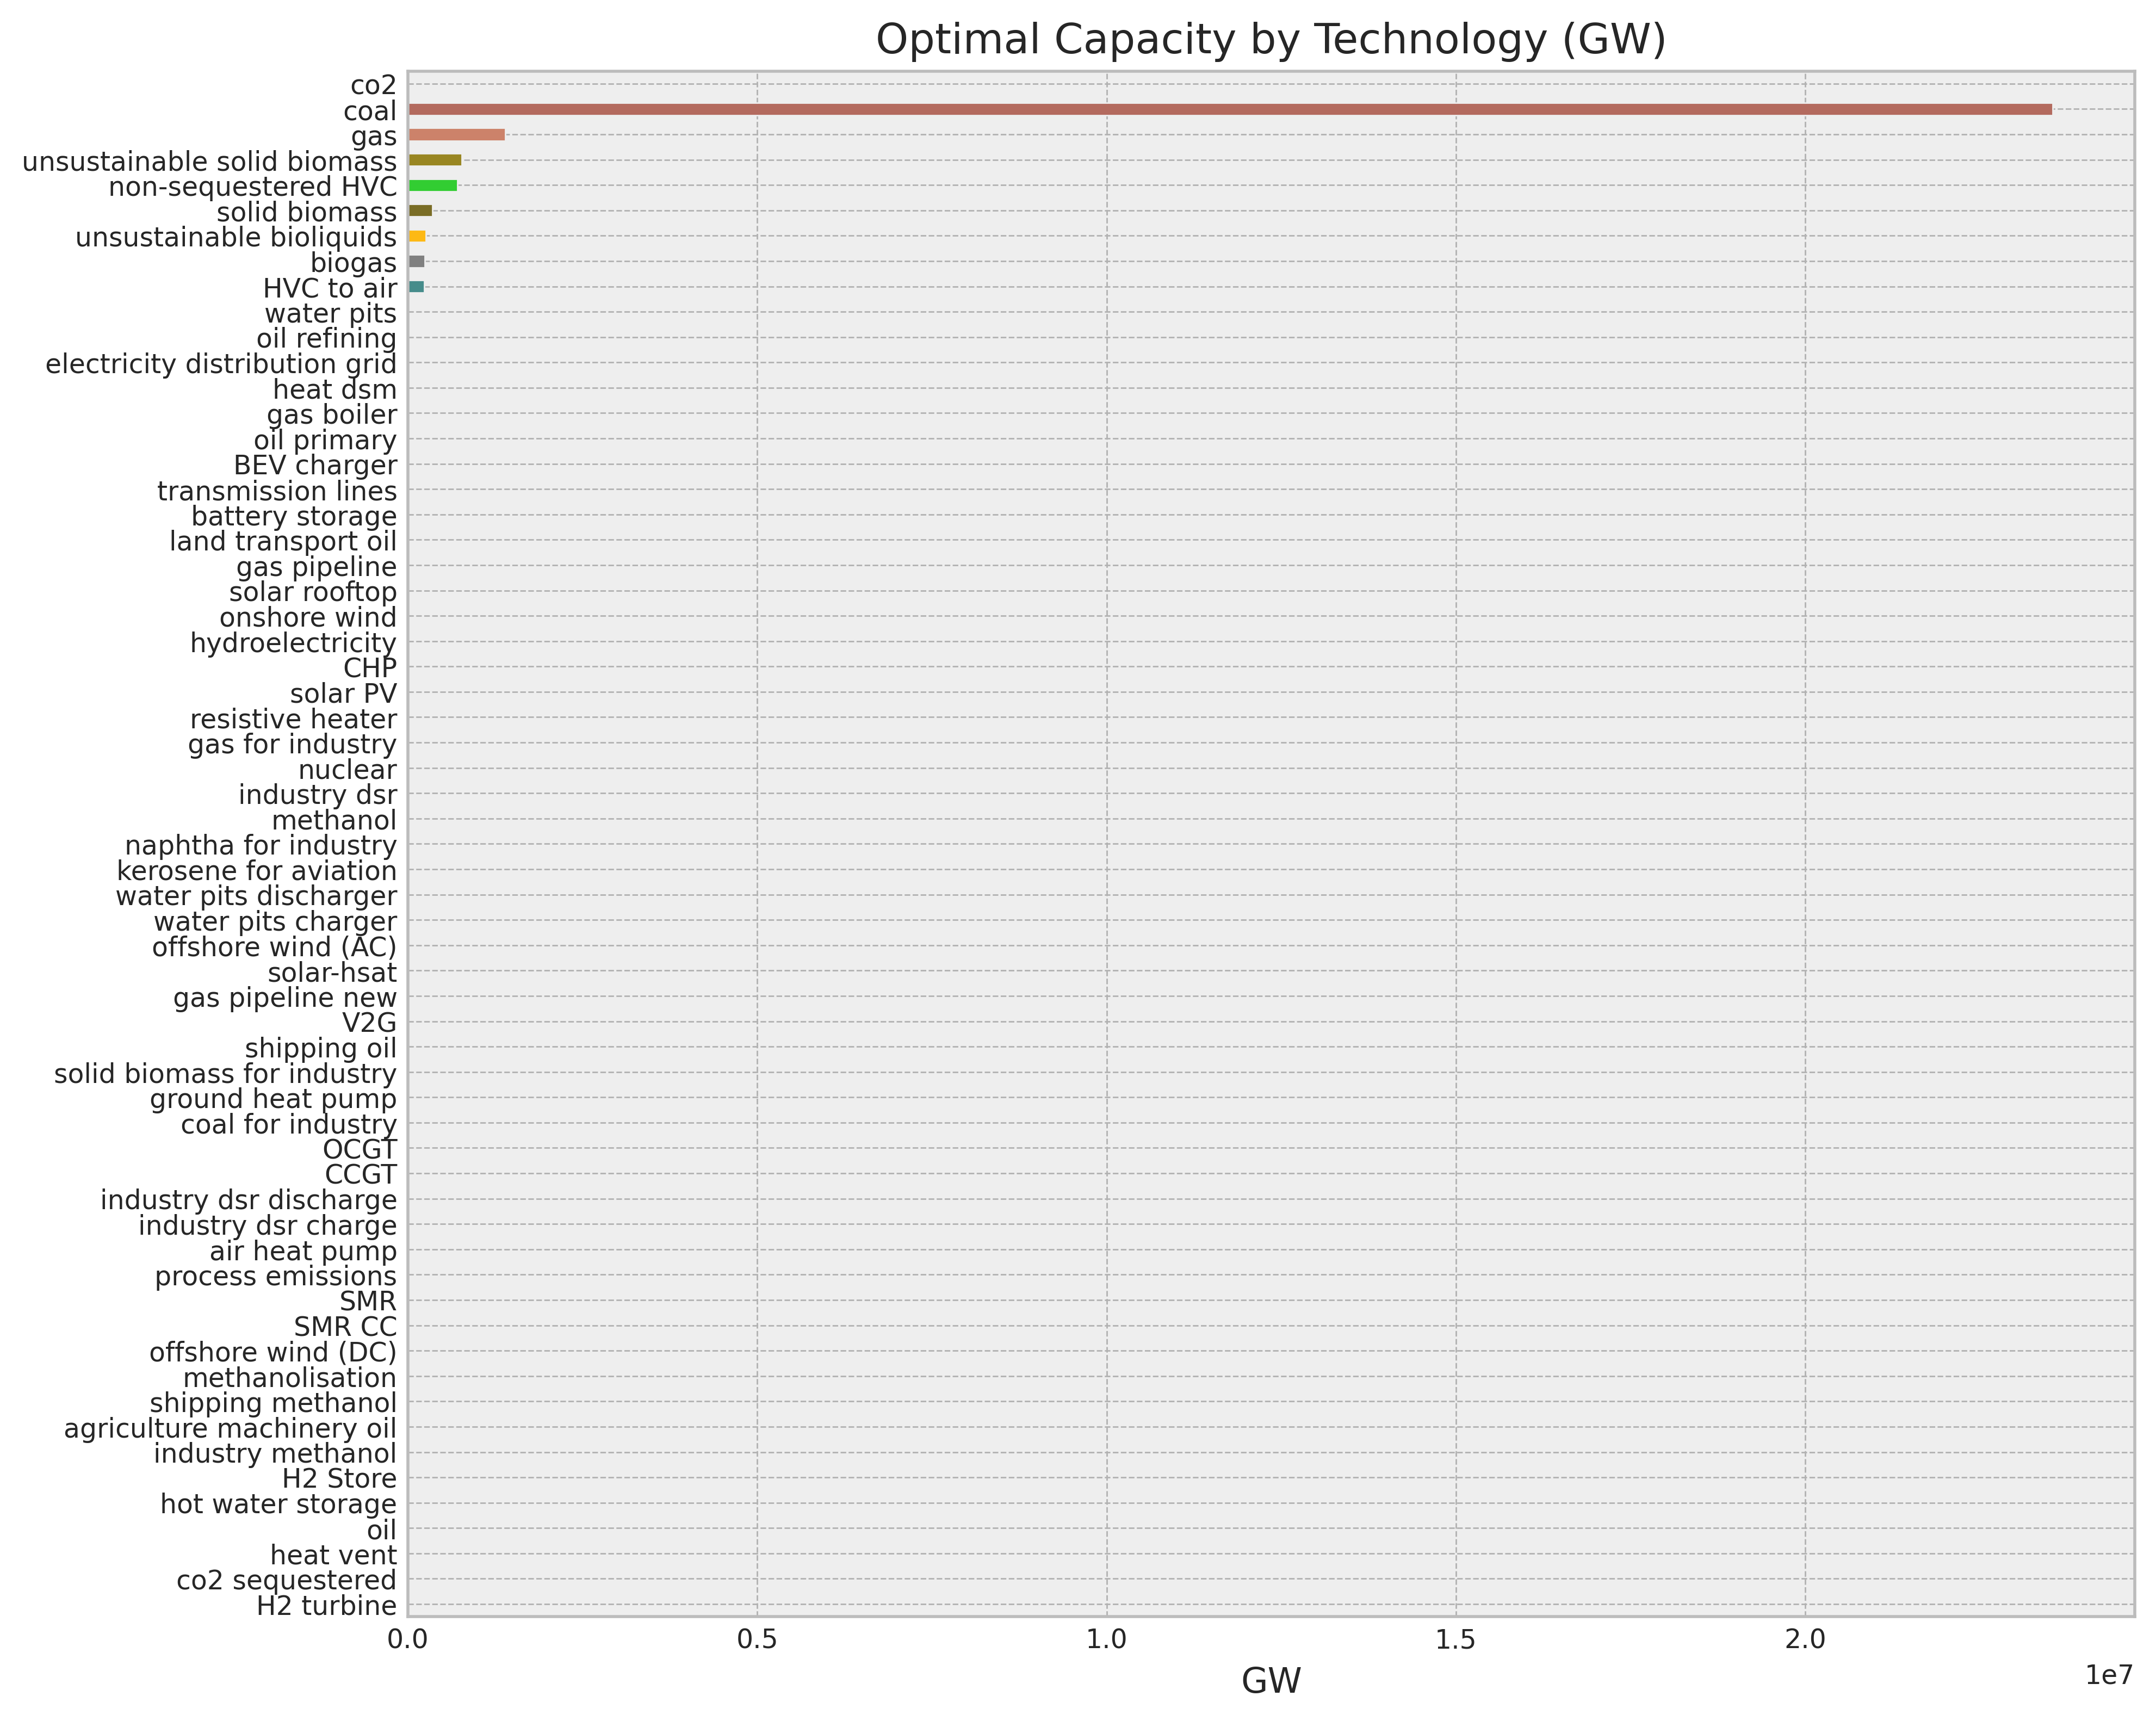

In [47]:
# 3. INSTALLED CAPACITY - Using calculate_capacities from make_summary.py
capacities = calculate_capacities(n) / 1e3  # GW
capacities = capacities[capacities > 0.01]

# Capacities has MultiIndex (component, carrier) - extract carrier level
carrier_idx = capacities.index.get_level_values('carrier')
cap_by_carrier = capacities.groupby(carrier_idx).sum()

# Rename and order
cap_renamed = cap_by_carrier.groupby(cap_by_carrier.index.map(rename_techs)).sum()
cap_renamed = cap_renamed.reindex(
    preferred_order.intersection(cap_renamed.index).append(
        cap_renamed.index.difference(preferred_order)
    )
)

# Calculate relative shares
total_cap = cap_renamed.sum()
cap_shares = (cap_renamed / total_cap * 100).round(1)

# Create summary DataFrame
cap_df = pd.DataFrame({
    'GW': cap_renamed.round(2),
    'Share (%)': cap_shares
}).sort_values('GW', ascending=False)

print("=== INSTALLED CAPACITY (GW and %) ===")
print(cap_df)
print(f"\nTotal Capacity: {total_cap:.2f} GW")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
c = [tech_colors.get(t, 'lightgrey') for t in cap_renamed.index]
cap_renamed.sort_values(ascending=True).plot.barh(ax=ax, color=c)
ax.set_title('Optimal Capacity by Technology (GW)')
ax.set_xlabel('GW')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'installed_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

## Electricity capacity

=== ELECTRICITY CAPACITY (GW, AC+low voltage) ===
                            GW  Share (%)
solar rooftop           365.27      23.84
onshore wind            261.59      17.07
hydroelectricity        198.57      12.96
solar PV                186.99      12.20
nuclear                 105.29       6.87
offshore wind (AC)       73.68       4.81
CHP                      72.35       4.72
solar-hsat               69.23       4.52
V2G                      56.25       3.67
ground heat pump         44.99       2.94
industry dsr discharge   26.91       1.76
air heat pump            25.23       1.65
CCGT                     18.70       1.22
OCGT                     15.60       1.02
offshore wind (DC)       11.45       0.75
battery storage           0.03       0.00

Total electricity capacity: 1532.13 GW

=== COMPONENT BREAKDOWN BY CARRIER (GW) ===
                                 generators_GW  links_input_GW  links_electric_output_GW  storage_units_GW  electric_total_GW
carrier                  

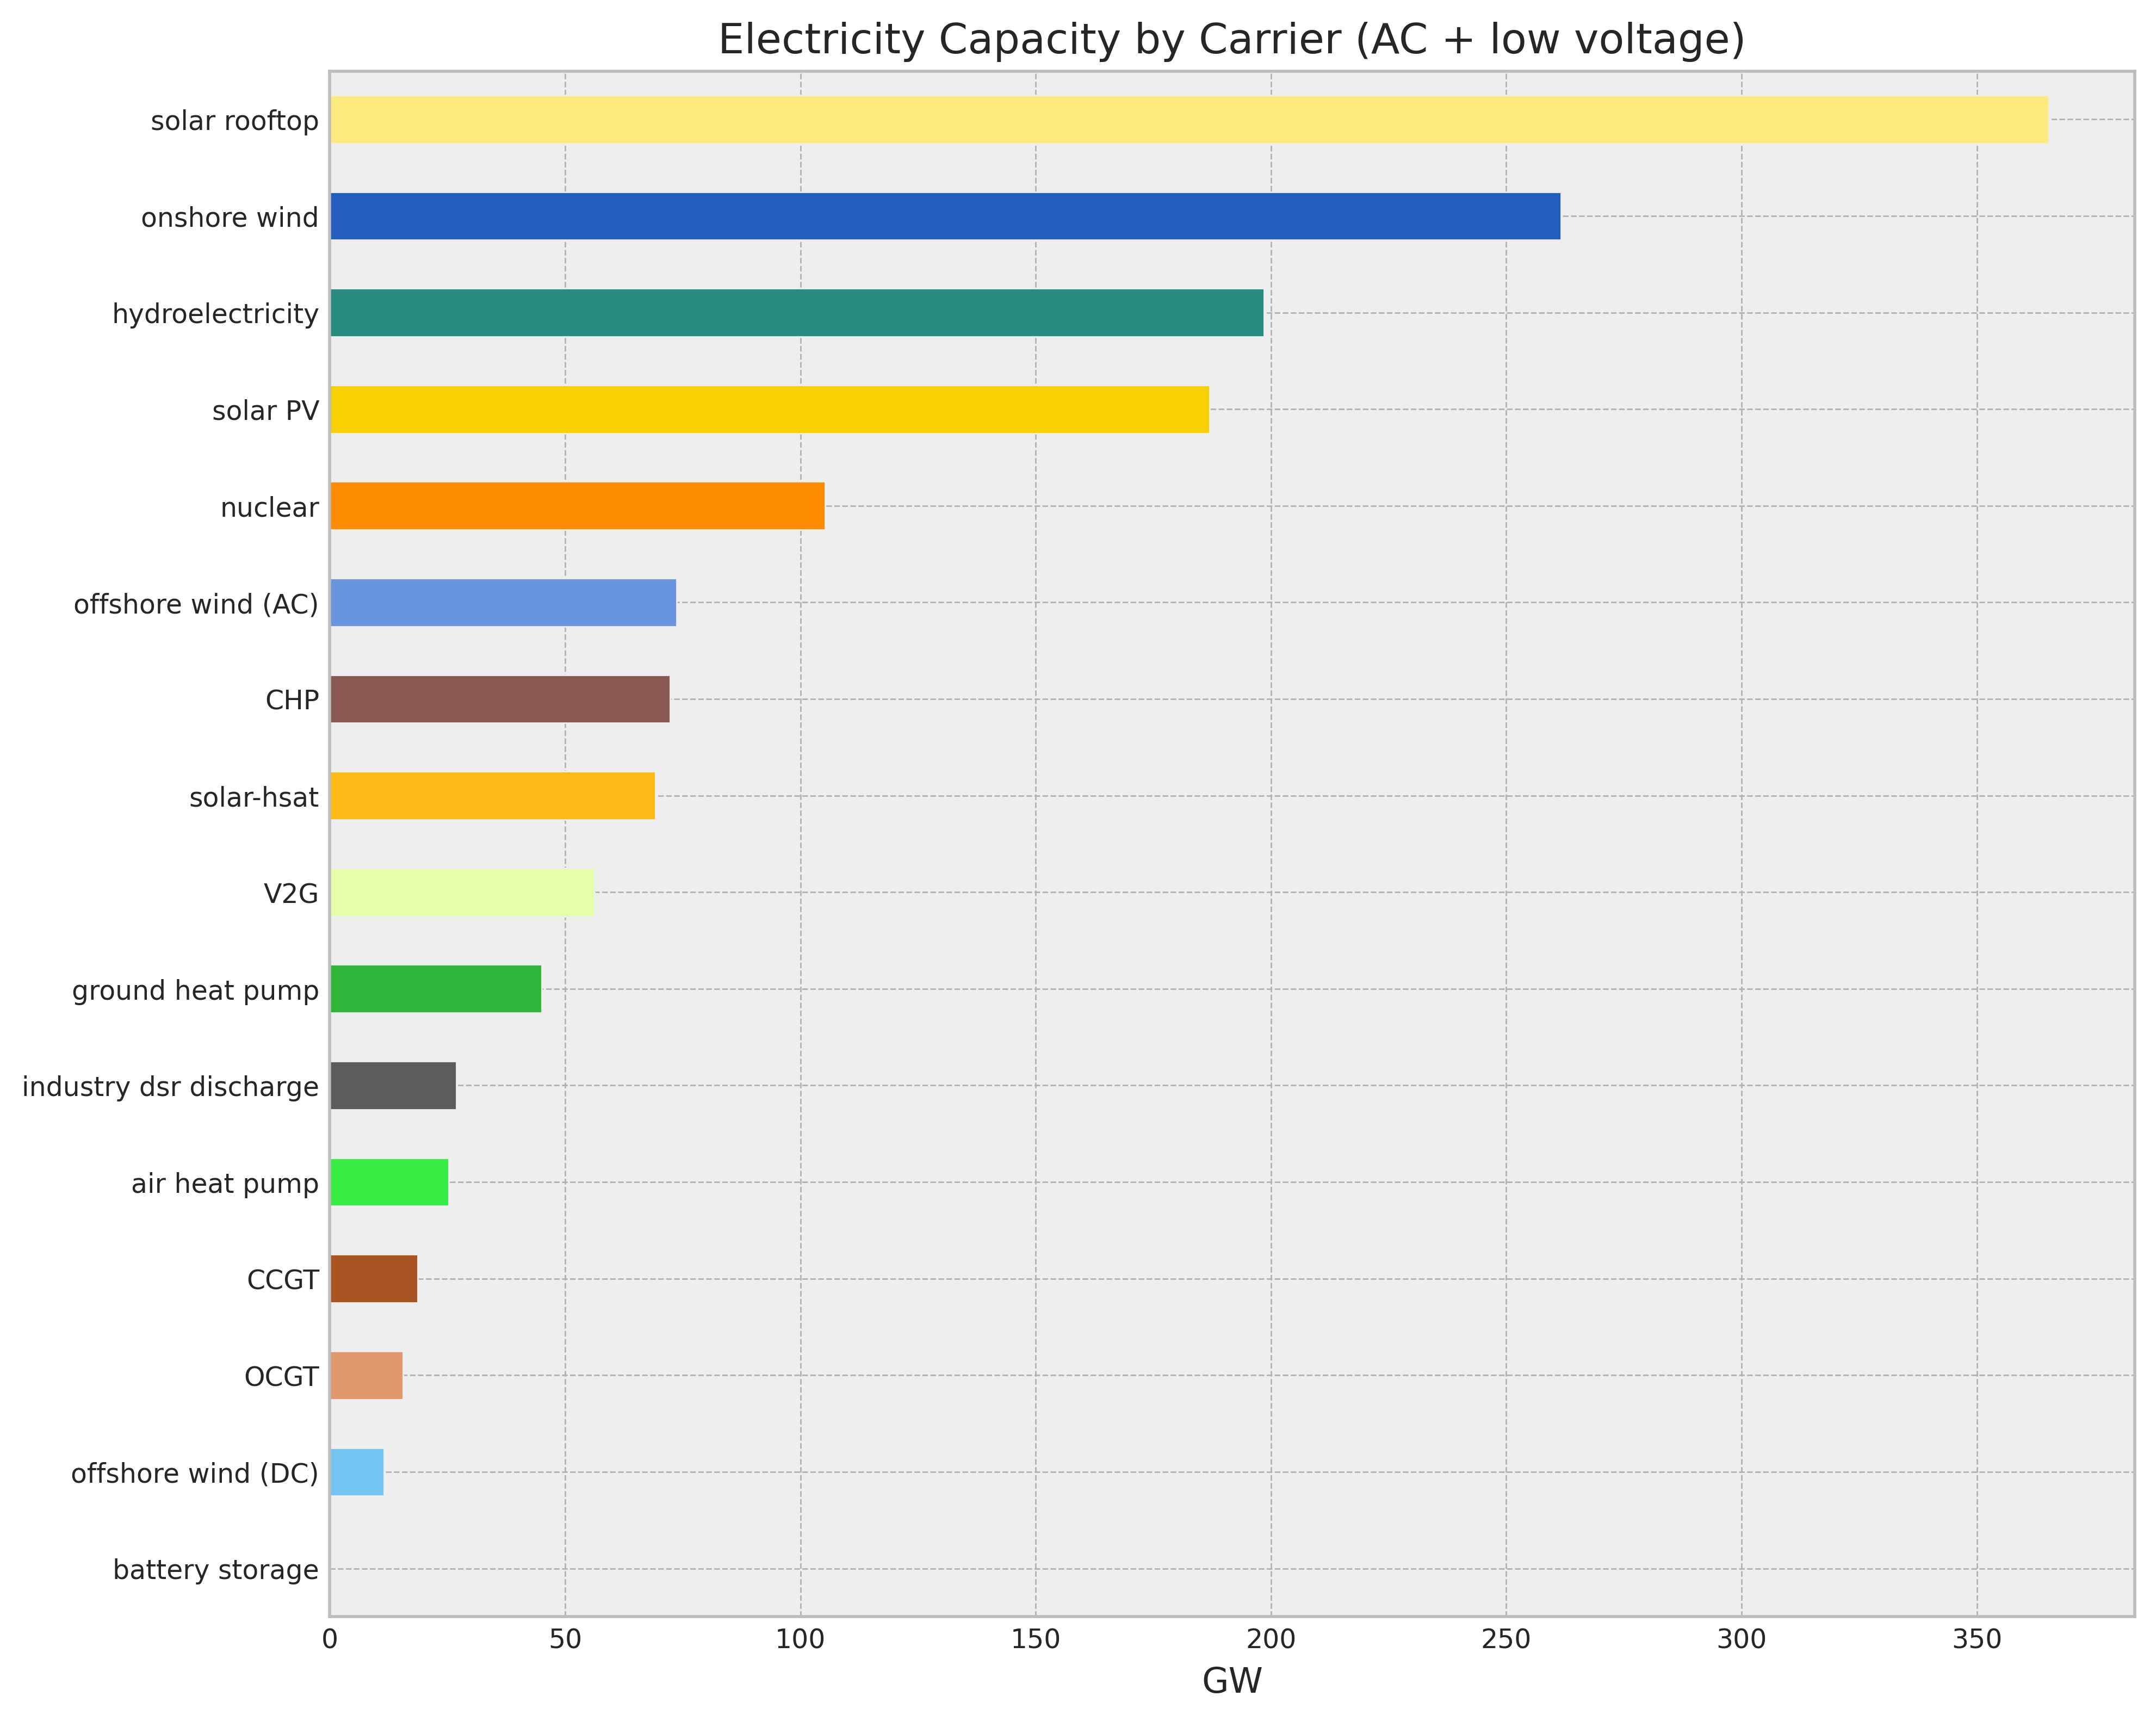

In [48]:
# Installed electricity capacities with GAS on input-side (standard), plus output-side reference
# Includes generators, links, storage_units; excludes electricity distribution grid links.
# Saves CSV + Excel with clear separation of metrics.

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Settings
# -----------------------------
ELEC_BUS_CARRIERS = {"AC", "low voltage"}
EXCLUDE_LINK_CARRIERS = {"electricity distribution grid", "DC", "gas pipeline", "gas pipeline new"}

# If you have these in your notebook, keep using them:
# - rename_techs
# - preferred_order
# - tech_colors

# -----------------------------
# Helpers
# -----------------------------
def cap_col(df):
    return "p_nom_opt" if "p_nom_opt" in df.columns else "p_nom"

def is_gas_carrier(c):
    s = str(c).lower()
    if "biogas" in s:
        return False
    return ("gas" in s) or ("ocgt" in s) or ("ccgt" in s)

def is_hydro_carrier(c):
    s = str(c).lower()
    return ("ror" in s) or ("hydro" in s) or ("phs" in s) or ("pumped" in s)

def maybe_rename_index(series):
    if "rename_techs" in globals():
        return series.groupby(series.index.map(rename_techs)).sum()
    return series

def maybe_reorder_index(series):
    if "preferred_order" in globals():
        po = preferred_order.intersection(series.index).append(series.index.difference(preferred_order))
        return series.reindex(po)
    return series

# -----------------------------
# Buses
# -----------------------------
elec_buses = set(n.buses.index[n.buses.carrier.isin(ELEC_BUS_CARRIERS)])

# -----------------------------
# 1) Generators (electric buses)
# -----------------------------
gcol = cap_col(n.generators)
gen = n.generators[n.generators.bus.isin(elec_buses)].copy()
gen = gen[gen[gcol] > 0]
gen_by_carrier = gen.groupby("carrier")[gcol].sum() / 1e3  # GW

# -----------------------------
# 2) Links
#   A) Input-side GW (p_nom_opt) -> use this as standard for gas fleet capacity
#   B) Output-side electric GW (p_nom_opt * efficiency at elec terminals)
# -----------------------------
lcol = cap_col(n.links)
link_input_rows = []
link_output_rows = []

for _, r in n.links.iterrows():
    carrier = str(r.get("carrier", ""))
    if carrier in EXCLUDE_LINK_CARRIERS:
        continue

    p_nom = r.get(lcol, np.nan)
    if pd.isna(p_nom) or p_nom <= 0:
        continue

    # Does the link touch electricity at output terminals?
    elec_eff_sum = 0.0
    for bus_col, eff_col in [("bus1", "efficiency"), ("bus2", "efficiency2"), ("bus3", "efficiency3"), ("bus4", "efficiency4")]:
        if bus_col not in n.links.columns:
            continue
        b = r.get(bus_col, np.nan)
        if pd.isna(b) or b not in elec_buses:
            continue

        eff = r.get(eff_col, np.nan)
        if pd.isna(eff) and bus_col == "bus1":
            eff = 1.0
        if pd.notna(eff) and eff > 0:
            elec_eff_sum += float(eff)

    if elec_eff_sum > 0:
        # input-side capacity
        link_input_rows.append((carrier, float(p_nom) / 1e3))
        # electric output-side equivalent
        link_output_rows.append((carrier, float(p_nom) * elec_eff_sum / 1e3))

link_input_by_carrier = (
    pd.DataFrame(link_input_rows, columns=["carrier", "GW"]).groupby("carrier")["GW"].sum()
    if link_input_rows else pd.Series(dtype=float)
)
link_output_by_carrier = (
    pd.DataFrame(link_output_rows, columns=["carrier", "GW"]).groupby("carrier")["GW"].sum()
    if link_output_rows else pd.Series(dtype=float)
)

# -----------------------------
# 3) Storage units (electric buses, power GW)
# -----------------------------
scol = cap_col(n.storage_units)
su = n.storage_units[n.storage_units.bus.isin(elec_buses)].copy()
su = su[su[scol] > 0]
su_by_carrier = su.groupby("carrier")[scol].sum() / 1e3  # GW

# -----------------------------
# Main total table (electricity capacity perspective)
# - generators: GW
# - links: output-side GW
# - storage_units: GW
# -----------------------------
cap_electric_by_carrier = gen_by_carrier.add(link_output_by_carrier, fill_value=0).add(su_by_carrier, fill_value=0)
cap_electric_by_carrier = cap_electric_by_carrier[cap_electric_by_carrier > 0.01]

cap_electric_by_carrier = maybe_reorder_index(maybe_rename_index(cap_electric_by_carrier))
total_electric = cap_electric_by_carrier.sum()

cap_df = pd.DataFrame({
    "GW": cap_electric_by_carrier.round(2),
    "Share (%)": (cap_electric_by_carrier / total_electric * 100).round(2)
}).sort_values("GW", ascending=False)

print("=== ELECTRICITY CAPACITY (GW, AC+low voltage) ===")
print(cap_df.to_string())
print(f"\nTotal electricity capacity: {total_electric:.2f} GW")

# -----------------------------
# Component audit table by carrier
# -----------------------------
component_df = pd.DataFrame({
    "generators_GW": gen_by_carrier,
    "links_input_GW": link_input_by_carrier,          # standard for gas capacity reporting
    "links_electric_output_GW": link_output_by_carrier,
    "storage_units_GW": su_by_carrier
}).fillna(0.0)

# For general electricity total use output-side links
component_df["electric_total_GW"] = (
    component_df["generators_GW"] + component_df["links_electric_output_GW"] + component_df["storage_units_GW"]
)
component_df = component_df[component_df["electric_total_GW"] > 0.01].sort_values("electric_total_GW", ascending=False)

print("\n=== COMPONENT BREAKDOWN BY CARRIER (GW) ===")
print(component_df.round(2).to_string())

# -----------------------------
# Gas and Hydro separated
# Gas: report BOTH metrics, with input-side as primary
# Hydro: report electricity GW
# -----------------------------
gas_df = component_df[component_df.index.map(is_gas_carrier)].copy()
hydro_df = component_df[component_df.index.map(is_hydro_carrier)].copy()

gas_input_total = float(gas_df["links_input_GW"].sum())  # primary gas fleet metric
gas_electric_total = float(gas_df["electric_total_GW"].sum())  # reference

hydro_total = float(hydro_df["electric_total_GW"].sum())

print("\n=== GAS CAPACITY (separate) ===")
if len(gas_df):
    print(gas_df.round(2).to_string())
else:
    print("No gas carriers found.")
print(f"\nGas capacity (INPUT-side, standard): {gas_input_total:.2f} GW")
print(f"Gas capacity (electric output-equivalent): {gas_electric_total:.2f} GW")

print("\n=== HYDRO CAPACITY (separate) ===")
if len(hydro_df):
    print(hydro_df.round(2).to_string())
else:
    print("No hydro carriers found.")
print(f"\nHydro electricity capacity: {hydro_total:.2f} GW")

# -----------------------------
# Save files
# -----------------------------
cap_df.to_csv(OUTPUT_DIR / "capacity_electricity_by_carrier.csv")
component_df.to_csv(OUTPUT_DIR / "capacity_component_breakdown_with_link_metrics.csv")
gas_df.to_csv(OUTPUT_DIR / "capacity_gas_breakdown_input_and_output.csv")
hydro_df.to_csv(OUTPUT_DIR / "capacity_hydro_breakdown.csv")

excel_path = OUTPUT_DIR / "capacity_electricity_gas_hydro_input_output_split.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    cap_df.to_excel(writer, sheet_name="electricity_total")
    component_df.to_excel(writer, sheet_name="component_breakdown")
    gas_df.to_excel(writer, sheet_name="gas")
    hydro_df.to_excel(writer, sheet_name="hydro")
    pd.DataFrame({
        "metric": [
            "total_electricity_capacity_GW",
            "gas_capacity_input_side_GW",
            "gas_capacity_electric_output_GW",
            "hydro_capacity_electric_GW",
        ],
        "value": [total_electric, gas_input_total, gas_electric_total, hydro_total],
    }).to_excel(writer, sheet_name="summary", index=False)

print(f"\nSaved CSV + Excel to {OUTPUT_DIR}")
print(f"Excel file: {excel_path}")

# -----------------------------
# Plot (electricity perspective)
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 8))
plot_series = cap_df["GW"].sort_values(ascending=True)
if "tech_colors" in globals():
    colors = [tech_colors.get(t, "lightgrey") for t in plot_series.index]
else:
    colors = "lightgrey"

plot_series.plot.barh(ax=ax, color=colors)
ax.set_title("Electricity Capacity by Carrier (AC + low voltage)")
ax.set_xlabel("GW")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "installed_capacity_electricity_ac_lv.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. CO2 Emissions (Energy Sector & Electricity)

=== CO2 FROM ELECTRICITY (Mt) ===
Series([], dtype: float64)
Total Electricity CO2: 0.00 Mt

=== CO2 BY ENERGY SECTOR (Mt) ===
Industry    949.96
dtype: float64
Total: 949.96 Mt


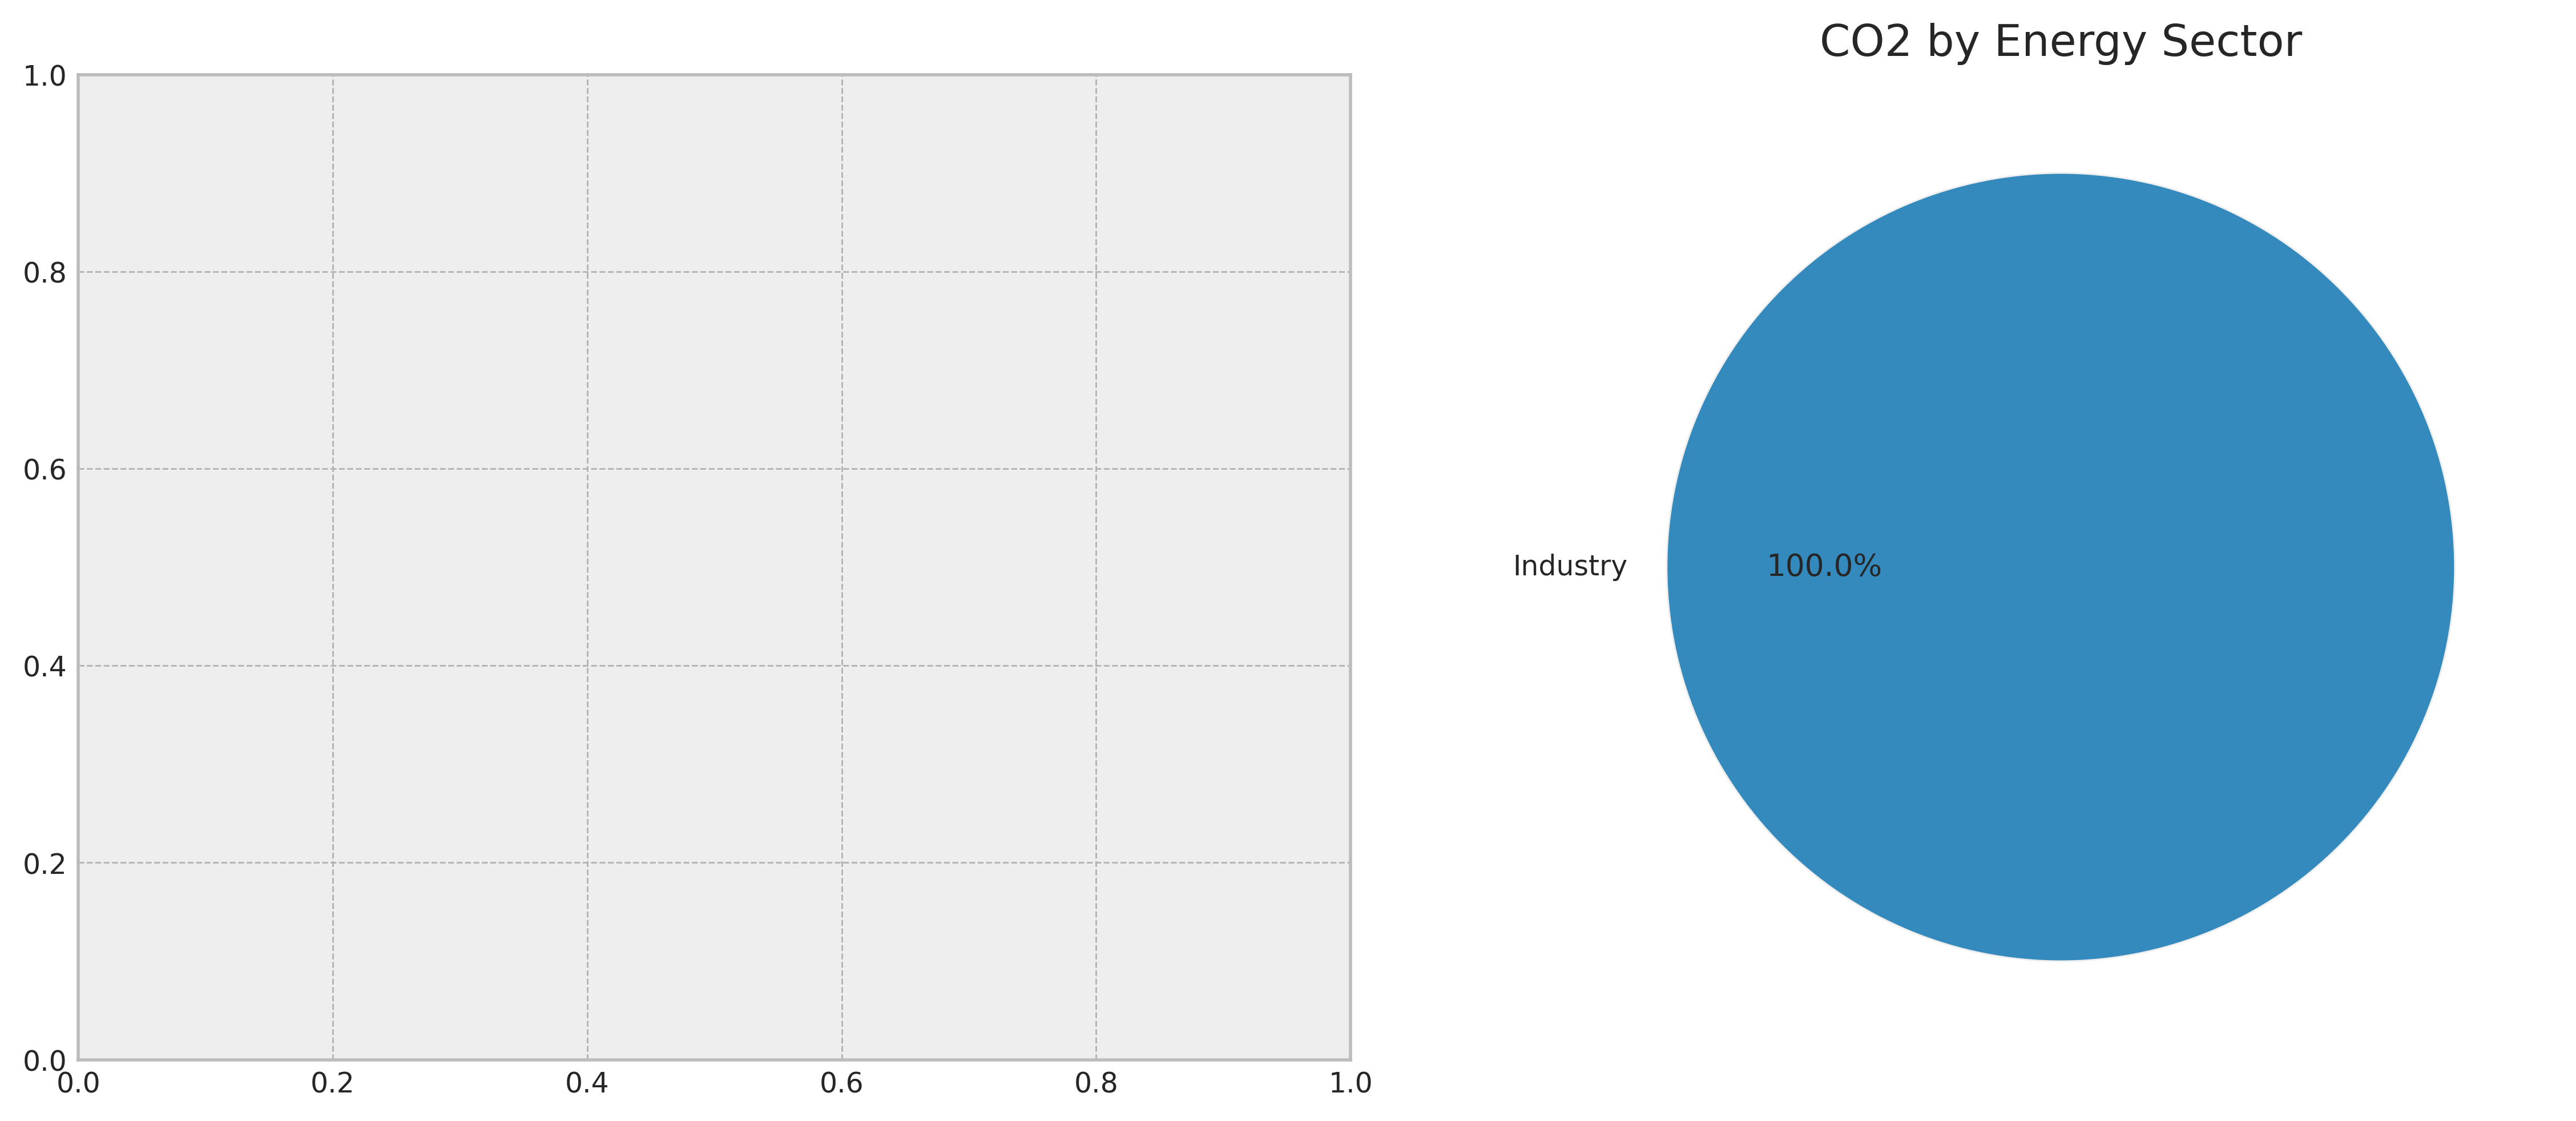

In [49]:
# 4. CO2 EMISSIONS
co2_by_sector = {}

# Electricity generation CO2
if 'co2_emissions' in n.carriers.columns:
    gen_output = n.generators_t.p.sum()
    gen_carriers = n.generators.carrier
    gen_co2_factor = gen_carriers.map(n.carriers['co2_emissions']).fillna(0)
    elec_co2 = (gen_output * gen_co2_factor).groupby(gen_carriers).sum() / 1e6  # Mt
    co2_by_sector['Electricity'] = elec_co2.sum()

    print("=== CO2 FROM ELECTRICITY (Mt) ===")
    elec_co2_pos = elec_co2[elec_co2 > 0].sort_values(ascending=False)
    print(elec_co2_pos.round(3))
    print(f"Total Electricity CO2: {elec_co2.sum():.2f} Mt")

# Heating CO2 (from gas boilers, etc.)
heat_carriers_co2 = ['gas boiler', 'resistive heater', 'oil boiler']
heat_links = n.links[n.links.carrier.isin(heat_carriers_co2)]
if len(heat_links) > 0:
    heat_output = n.links_t.p0[heat_links.index].sum()
    heat_co2_factor = heat_links.carrier.map(n.carriers['co2_emissions']).fillna(0)
    heat_co2 = (heat_output * heat_co2_factor).sum() / 1e6
    co2_by_sector['Heating'] = heat_co2

# Transport CO2 (from ICE vehicles if modeled)
transport_carriers = ['ICE', 'land transport oil']
for tc in transport_carriers:
    tc_loads = n.loads[n.loads.carrier == tc]
    if len(tc_loads) > 0:
        tc_output = n.loads_t.p_set[tc_loads.index].sum().sum()
        tc_co2 = tc_output * n.carriers.loc[tc, 'co2_emissions'] / 1e6 if tc in n.carriers.index else 0
        co2_by_sector['Transport'] = co2_by_sector.get('Transport', 0) + tc_co2

# Industry CO2
ind_carriers = ['process emissions', 'industry']
for ic in ind_carriers:
    ic_links = n.links[n.links.carrier.str.contains(ic, case=False, na=False)]
    if len(ic_links) > 0:
        co2_by_sector['Industry'] = co2_by_sector.get('Industry', 0) + n.links_t.p0[ic_links.index].sum().sum() / 1e6

co2_sectors = pd.Series(co2_by_sector)
co2_sectors = co2_sectors[co2_sectors > 0]

print("\n=== CO2 BY ENERGY SECTOR (Mt) ===")
print(co2_sectors.round(2))
print(f"Total: {co2_sectors.sum():.2f} Mt")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Electricity by technology
if 'elec_co2_pos' in dir() and len(elec_co2_pos) > 0:
    c = elec_co2_pos.index.map(lambda x: n.carriers.color.get(x, 'lightgrey'))
    elec_co2_pos.plot.bar(ax=axes[0], color=c)
    axes[0].set_title('Electricity CO2 by Technology (Mt)')
    axes[0].set_ylabel('Mt CO2')
    axes[0].tick_params(axis='x', rotation=45)

# By sector
if len(co2_sectors) > 0:
    co2_sectors.plot.pie(ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('CO2 by Energy Sector')
    axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'co2_emissions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. System Costs (by Technology)

=== SYSTEM COSTS BY TECHNOLOGY (bn EUR) ===
cost                           capital  marginal   total
carrier                                                 
oil primary                       0.00    195.69  195.69
gas                              24.80     97.42  122.22
nuclear                          79.36      9.12   88.48
gas boiler                       67.23      0.02   67.25
hydroelectricity                 42.03      0.01   42.03
onshore wind                     30.27      0.01   30.29
electricity distribution grid    24.47      0.03   24.50
unsustainable bioliquids          0.00     17.60   17.60
solar rooftop                    16.63      0.01   16.64
offshore wind (AC)               15.08      0.01   15.09
CHP                               9.26      4.22   13.48
biogas                            3.11      8.61   11.72
unsustainable solid biomass       0.00     11.19   11.19
transmission lines               10.17      0.00   10.17
solar PV                          9.79      

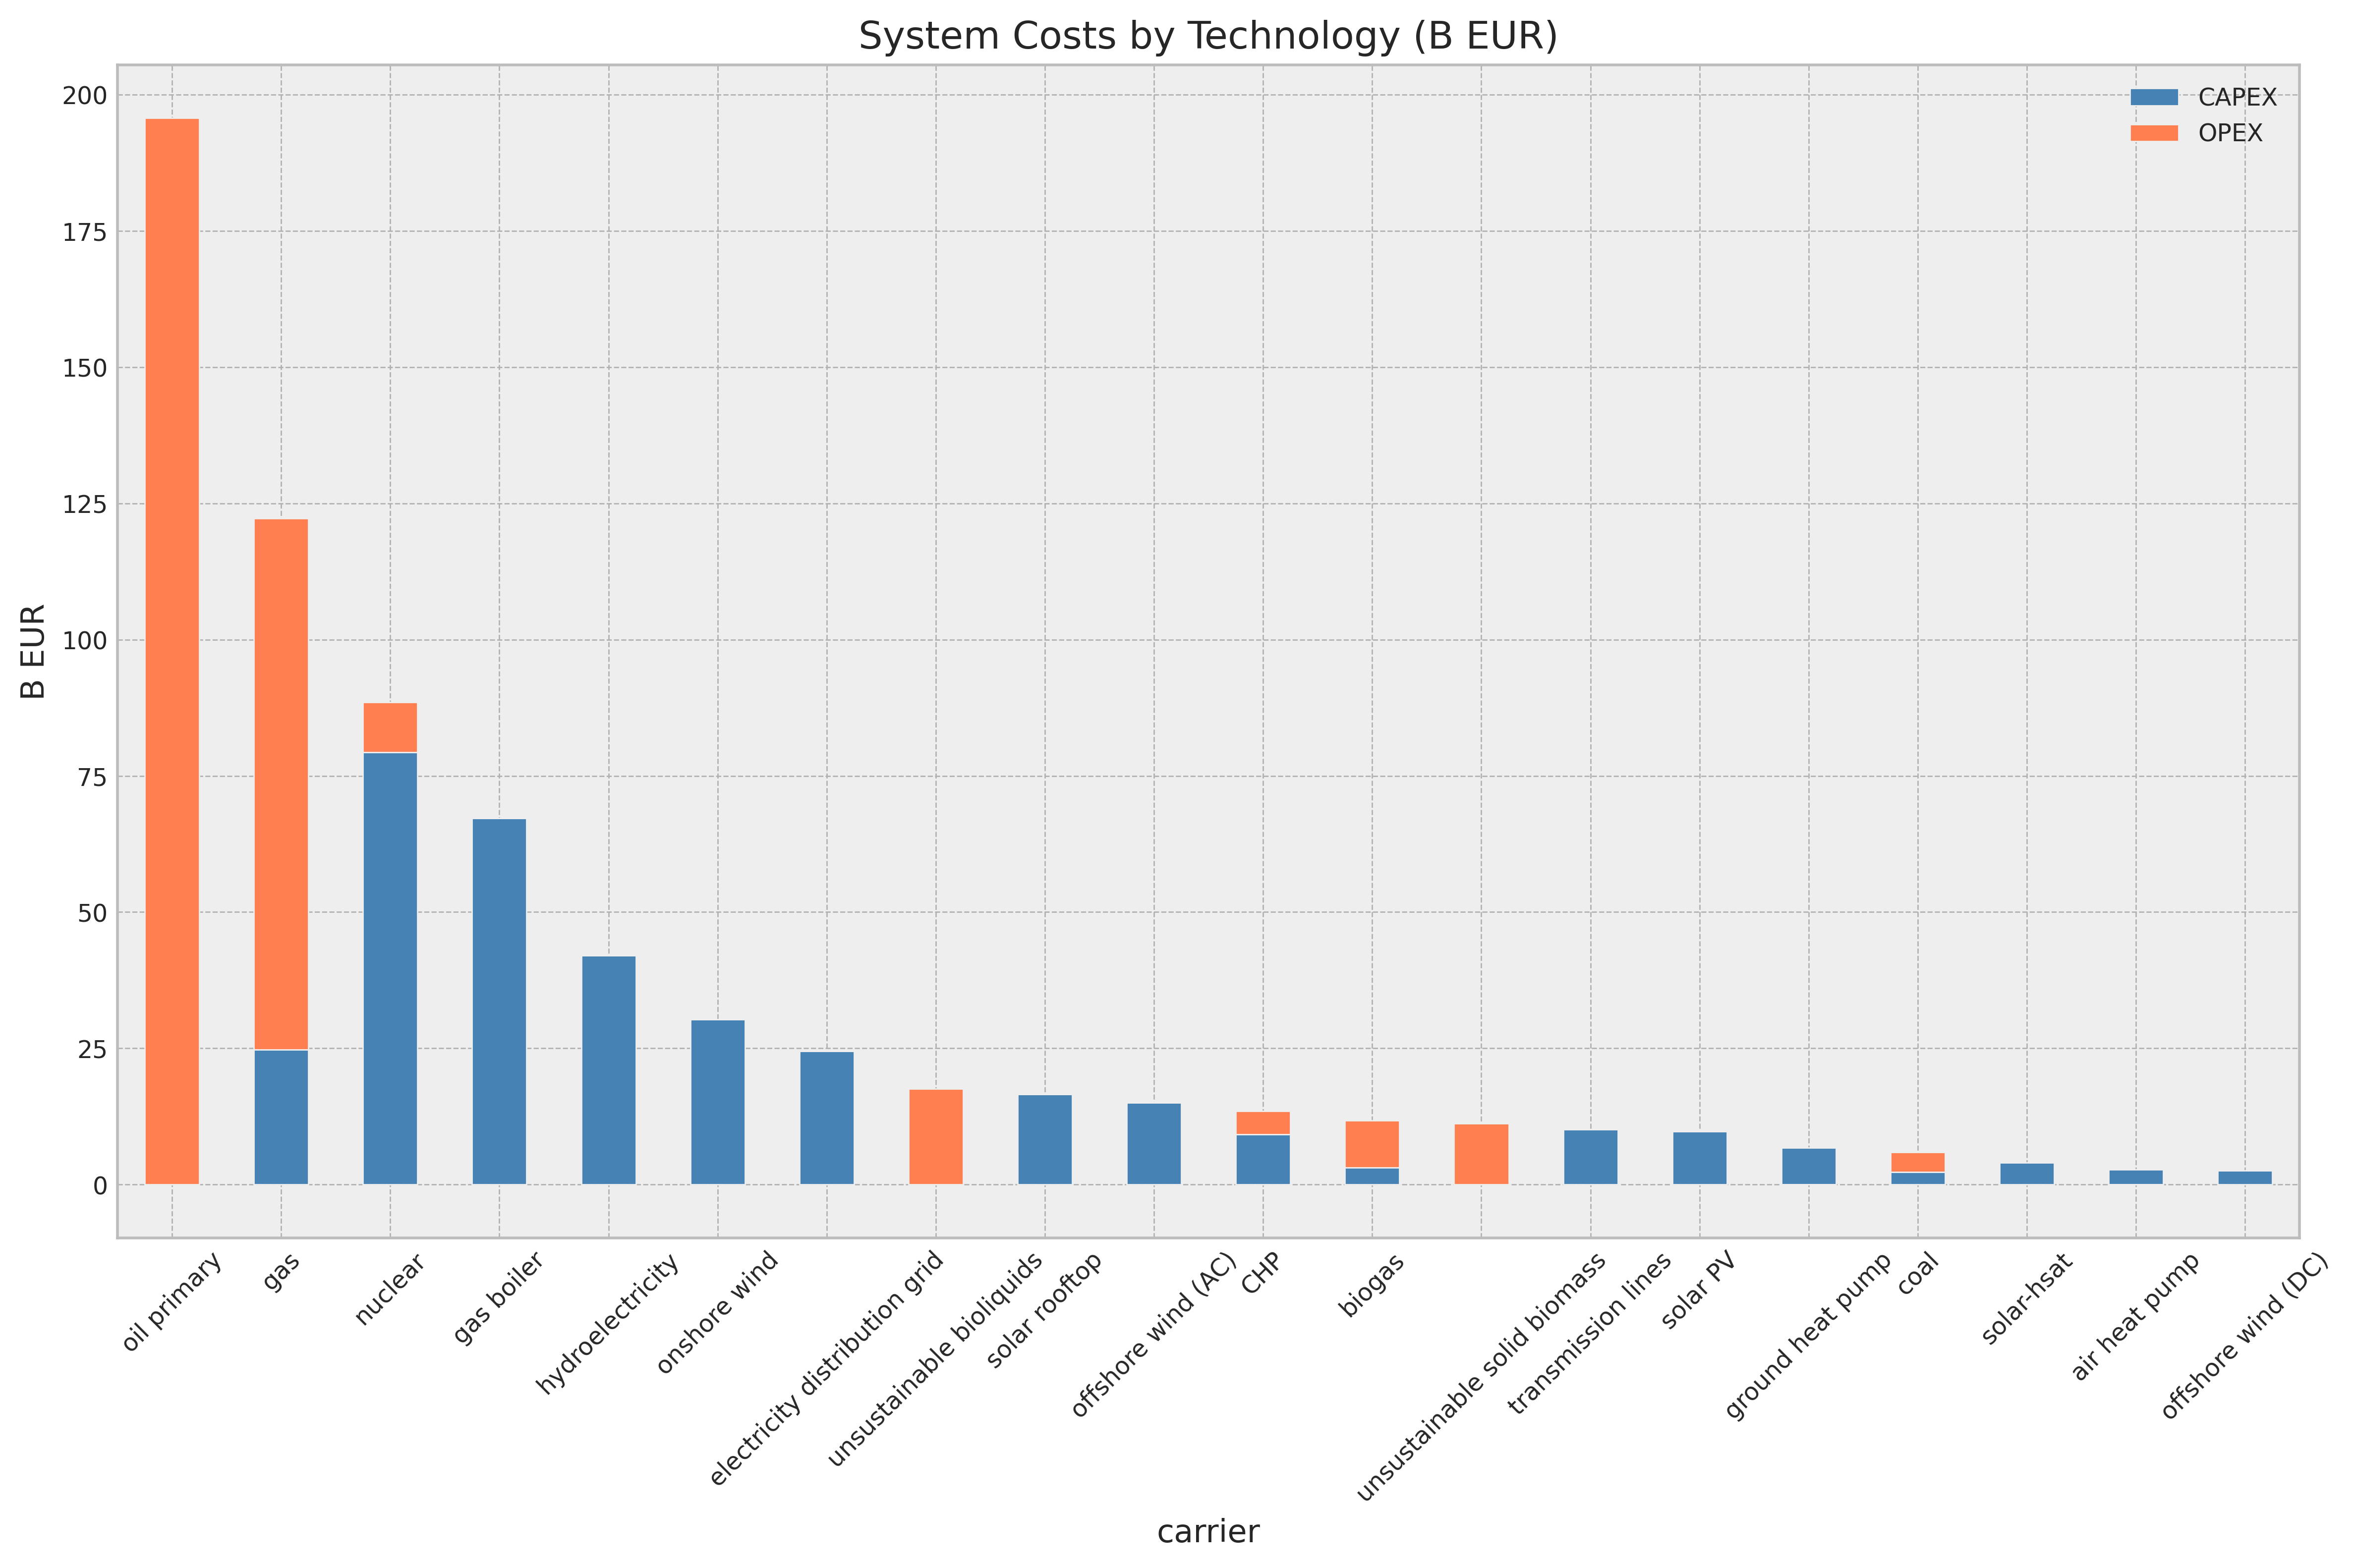


=== SYSTEM COSTS BY SECTOR (bn EUR) ===
cost         capital  marginal   total
carrier                               
Other         189.54    326.53  516.07
Electricity    91.59     21.92  113.50
Heating        78.32      0.02   78.33
Transport       0.00      0.03    0.03


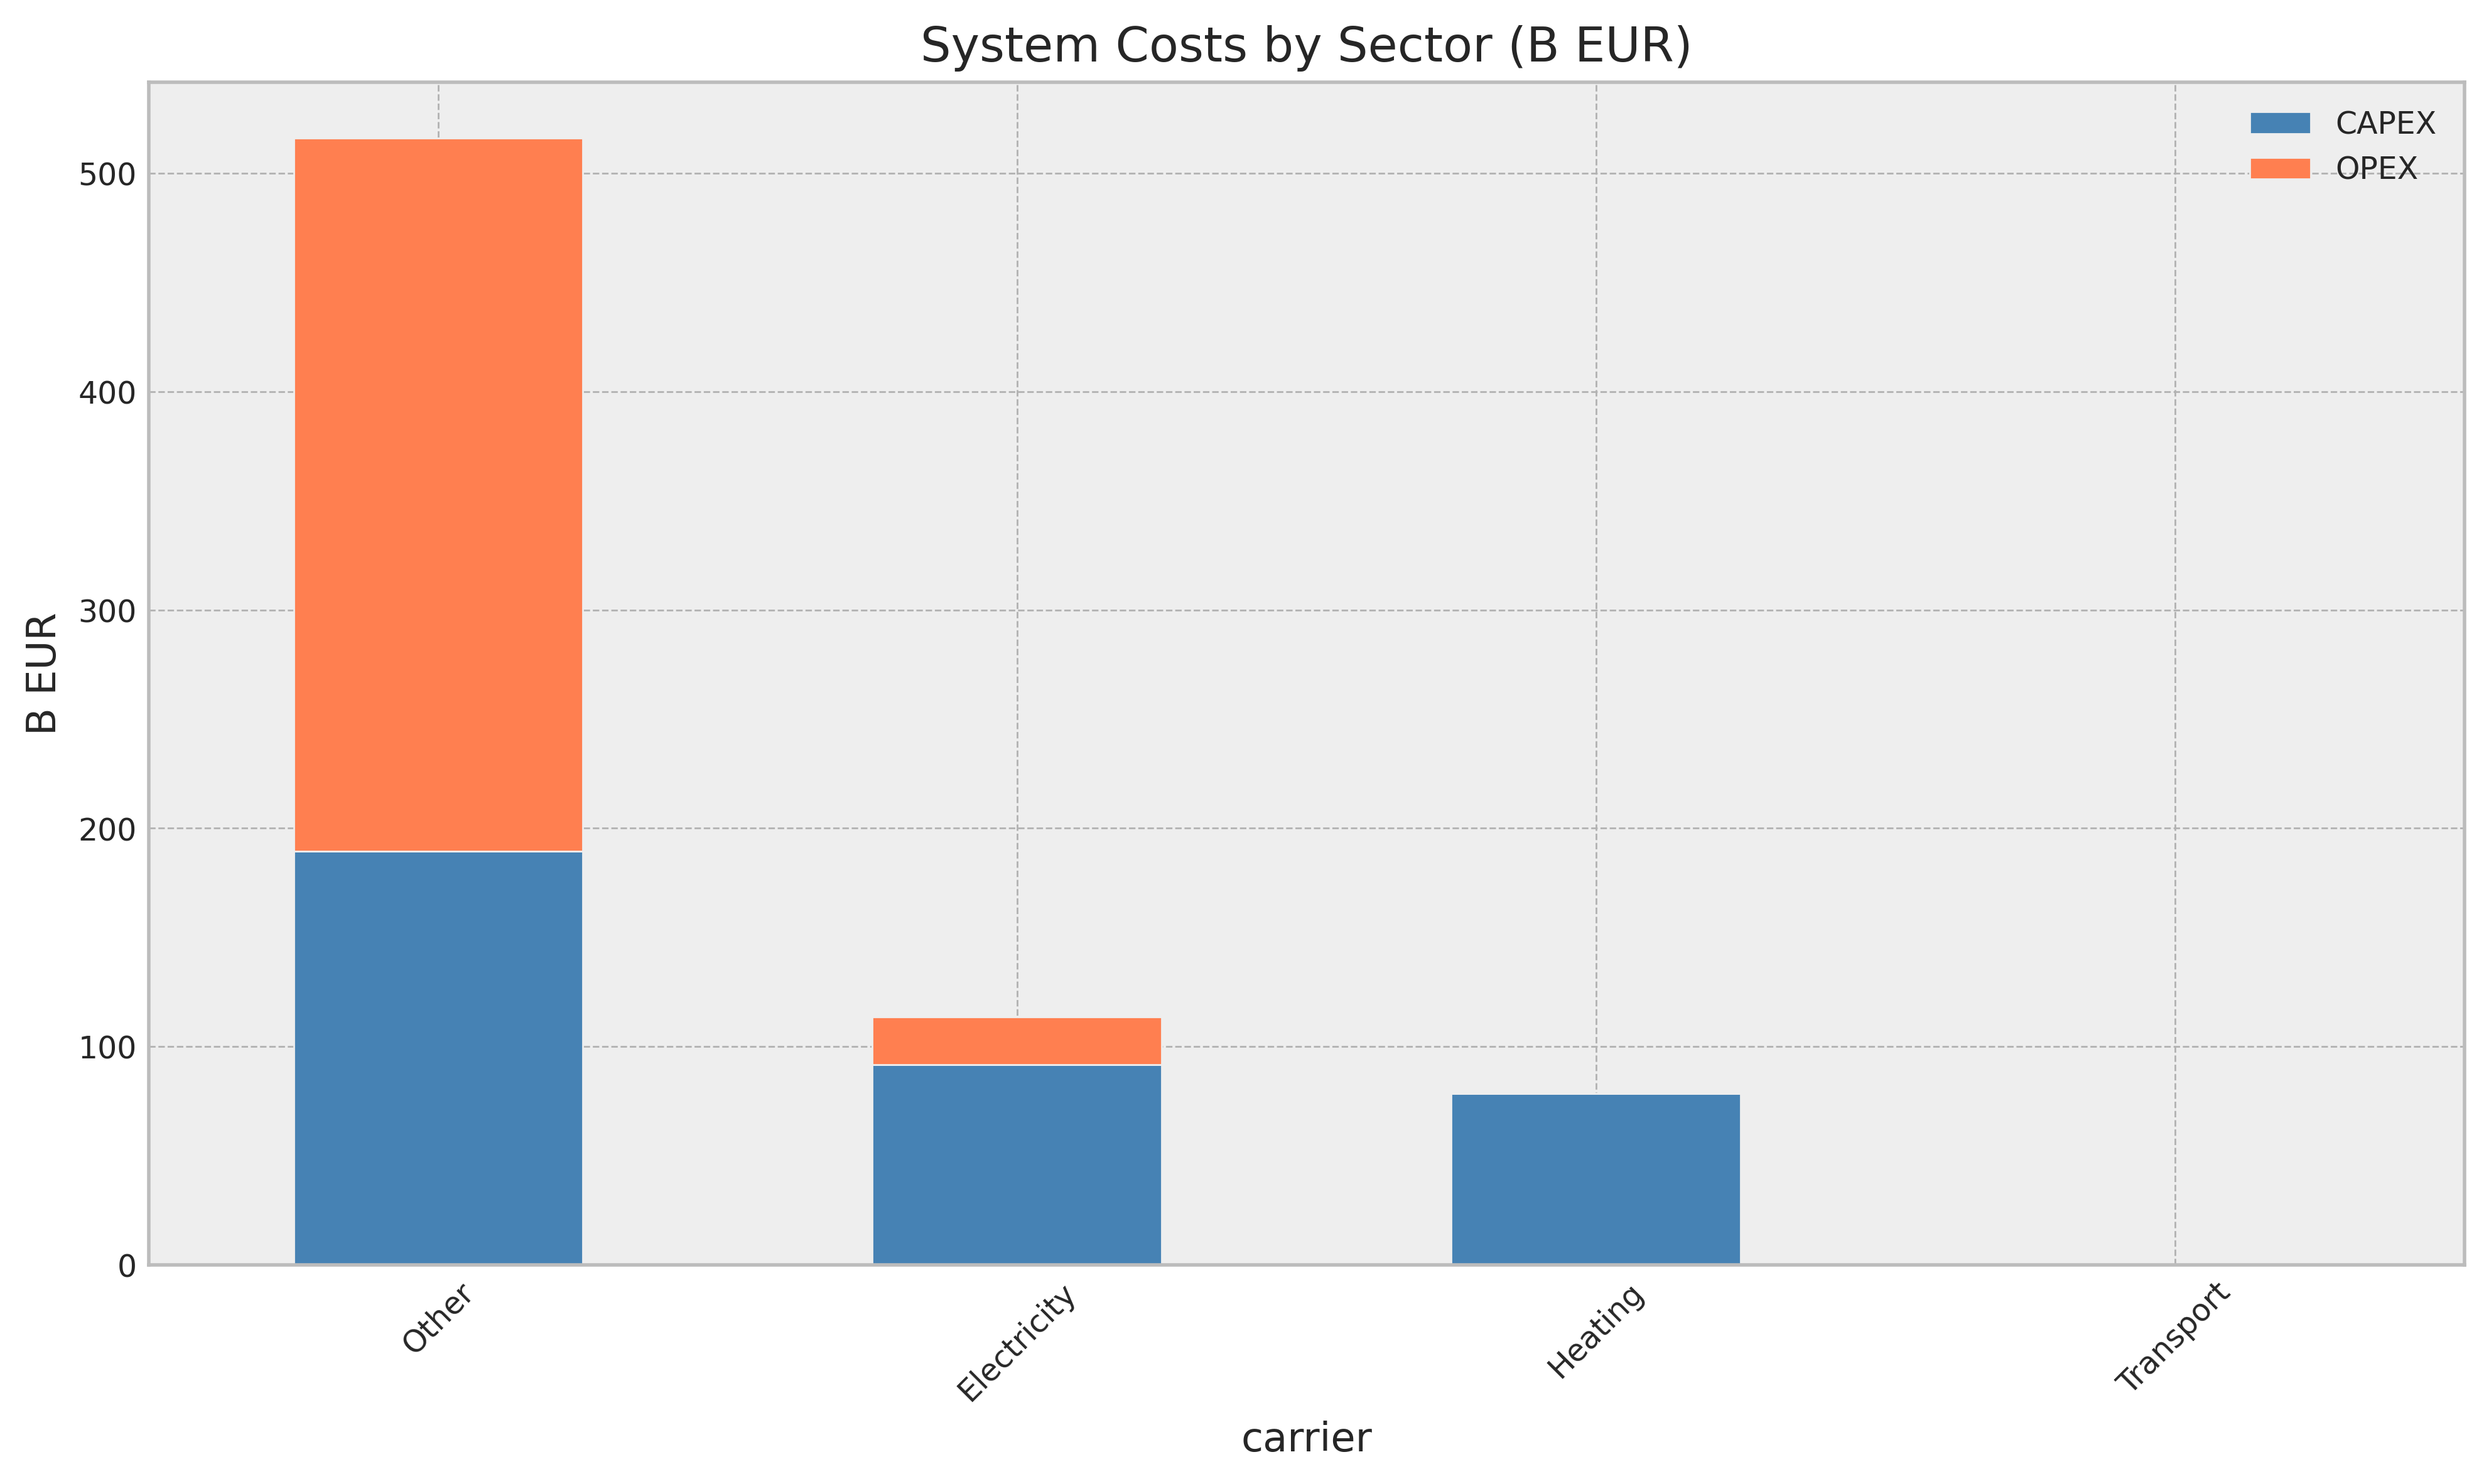

In [50]:
# 5. SYSTEM COSTS - Using calculate_costs from make_summary.py
costs_raw = calculate_costs(n) / 1e9  # B EUR

# Costs has MultiIndex (cost, component, carrier) - get carrier level
# First, sum across components to get by (cost, carrier)
costs_by_cost_carrier = costs_raw.groupby(['cost', 'carrier']).sum()

# Unstack cost level to get DataFrame with carrier index and capital/marginal columns
costs_df = costs_by_cost_carrier.unstack(level='cost').fillna(0)
costs_df['total'] = costs_df.sum(axis=1)
costs_df = costs_df[costs_df['total'] > 0.01].sort_values('total', ascending=False)

# Rename techs (costs_df now has simple carrier index, not MultiIndex)
costs_renamed = costs_df.groupby(costs_df.index.map(rename_techs)).sum()
costs_renamed = costs_renamed.sort_values('total', ascending=False)

print("=== SYSTEM COSTS BY TECHNOLOGY (bn EUR) ===")
print(costs_renamed.round(2))
print(f"\nTotal System Cost: {costs_renamed['total'].sum():.2f} B EUR")

# Visualize by technology
fig, ax = plt.subplots(figsize=(12, 8))
costs_renamed[['capital', 'marginal']].head(20).plot.bar(ax=ax, stacked=True, color=['steelblue', 'coral'])
ax.set_title('System Costs by Technology (B EUR)')
ax.set_ylabel('B EUR')
ax.tick_params(axis='x', rotation=45)
ax.legend(['CAPEX', 'OPEX'])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'system_costs.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# EXAMPLE: Grouping Technologies into Sectors
# =============================================================================
# Customize this mapping to match your analysis needs
tech_to_sector = {
    # Electricity generation
    'solar': 'Electricity', 'solar-hsat': 'Electricity', 'onwind': 'Electricity',
    'offwind-ac': 'Electricity', 'offwind-dc': 'Electricity', 'offwind-float': 'Electricity',
    'CCGT': 'Electricity', 'OCGT': 'Electricity', 'nuclear': 'Electricity',
    'coal': 'Electricity', 'lignite': 'Electricity', 'oil': 'Electricity',
    'ror': 'Electricity', 'hydro': 'Electricity', 'PHS': 'Electricity',
    'biomass': 'Electricity', 'biogas': 'Electricity',
    # Storage
    'battery': 'Storage', 'battery charger': 'Storage', 'battery discharger': 'Storage',
    'H2 electrolysis': 'Storage', 'H2 fuel cell': 'Storage', 'H2 Store': 'Storage',
    # Heating
    'gas boiler': 'Heating', 'resistive heater': 'Heating', 'air heat pump': 'Heating',
    'ground heat pump': 'Heating', 'oil boiler': 'Heating', 'biomass boiler': 'Heating',
    'urban central heat': 'Heating', 'residential rural heat': 'Heating',
    # Transport
    'EV charger': 'Transport', 'V2G': 'Transport', 'land transport oil': 'Transport',
    'BEV charger': 'Transport',
    # Transmission
    'AC': 'Transmission', 'DC': 'Transmission', 'H2 pipeline': 'Transmission',
    # Industry
    'H2 for industry': 'Industry', 'low-temperature heat for industry': 'Industry',
}

# Map technologies to sectors (use 'Other' for unmapped techs)
def map_to_sector(tech):
    return tech_to_sector.get(tech, 'Other')

# Aggregate costs by sector
costs_by_sector = costs_renamed.groupby(costs_renamed.index.map(map_to_sector)).sum()
costs_by_sector = costs_by_sector.sort_values('total', ascending=False)

print("\n=== SYSTEM COSTS BY SECTOR (bn EUR) ===")
print(costs_by_sector.round(2))

# Visualize by sector
if len(costs_by_sector) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    costs_by_sector[['capital', 'marginal']].plot.bar(ax=ax, stacked=True, color=['steelblue', 'coral'])
    ax.set_title('System Costs by Sector (B EUR)')
    ax.set_ylabel('B EUR')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['CAPEX', 'OPEX'])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'system_costs_by_sector.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Curtailment

In [51]:
# 6. CURTAILMENT - Using n.statistics.curtailment() as primary method
# The calculate_curtailment(n) function may fail if network lacks AC/low voltage generators

# Get absolute curtailment using n.statistics (most reliable)
curt_abs = n.statistics.curtailment() / 1e6  # TWh
curt_abs = curt_abs[curt_abs > 0]

print("=== CURTAILMENT (TWh) ===")
if len(curt_abs) > 0:
    print(curt_abs.round(3))
    print(f"\nTotal Curtailment: {curt_abs.sum():.2f} TWh")
else:
    print("No curtailment in this network")

# Try to calculate relative curtailment (may not work for all networks)
print("\n=== CURTAILMENT (%) ===")
try:
    curtailment_pct = calculate_curtailment(n)
    curtailment_pct = curtailment_pct[curtailment_pct > 0]
    if len(curtailment_pct) > 0:
        print(curtailment_pct.round(2))
    else:
        print("No curtailment percentage data available")
except Exception as e:
    # calculate_curtailment requires generators with AC/low voltage bus carriers
    # Fall back to manual calculation
    logger.warning(f"calculate_curtailment failed: {e}")
    print("Relative curtailment calculation not available for this network structure")

    # Manual fallback: calculate for renewable generators
    re_carriers_curt = ['solar', 'solar-hsat', 'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float']
    re_gens_curt = n.generators[n.generators.carrier.isin(re_carriers_curt)]
    if len(re_gens_curt) > 0 and len(n.generators_t.p_max_pu.columns.intersection(re_gens_curt.index)) > 0:
        re_idx = re_gens_curt.index.intersection(n.generators_t.p_max_pu.columns)
        p_max_pot = (n.generators_t.p_max_pu[re_idx] * n.generators.loc[re_idx, 'p_nom_opt']).sum().sum()
        p_actual = n.generators_t.p[re_idx].sum().sum()
        if p_max_pot > 0:
            curt_pct_manual = (p_max_pot - p_actual) / p_max_pot * 100
            print(f"Renewable curtailment (manual calc): {curt_pct_manual:.1f}%")

=== CURTAILMENT (TWh) ===
component    carrier                      
Generator    biogas                            965250.335
             coal                                   0.001
             gas                                 9085.338
             nuclear                               15.270
             offwind-ac                             0.312
             offwind-dc                             0.121
             offwind-float                          0.000
             oil primary                         1959.066
             onwind                                 1.181
             ror                                    0.036
             rural heat vent                        0.008
             rural solar thermal                    0.000
             solar                                  0.378
             solar rooftop                          0.827
             solar-hsat                             0.708
             solid biomass                    3060786.982
   

/home/abi/miniconda3/envs/pypsa-eurelectric/lib/python3.12/site-packages/pypsa/statistics/abstract.py:215: DeprecationWarning:

Passing `aggregate_across_components` was Deprecated in <!-- md:badge-version v1.0.0 -->.0 and will be removed with v2.0.0. Use e.g. `n.statistics.installed_capacity.groupby(<col_name>).sum() instead.



RE potential: 441.23 TWh, actual: 440.33 TWh
Curtailment: 0.90 TWh (0.2%)


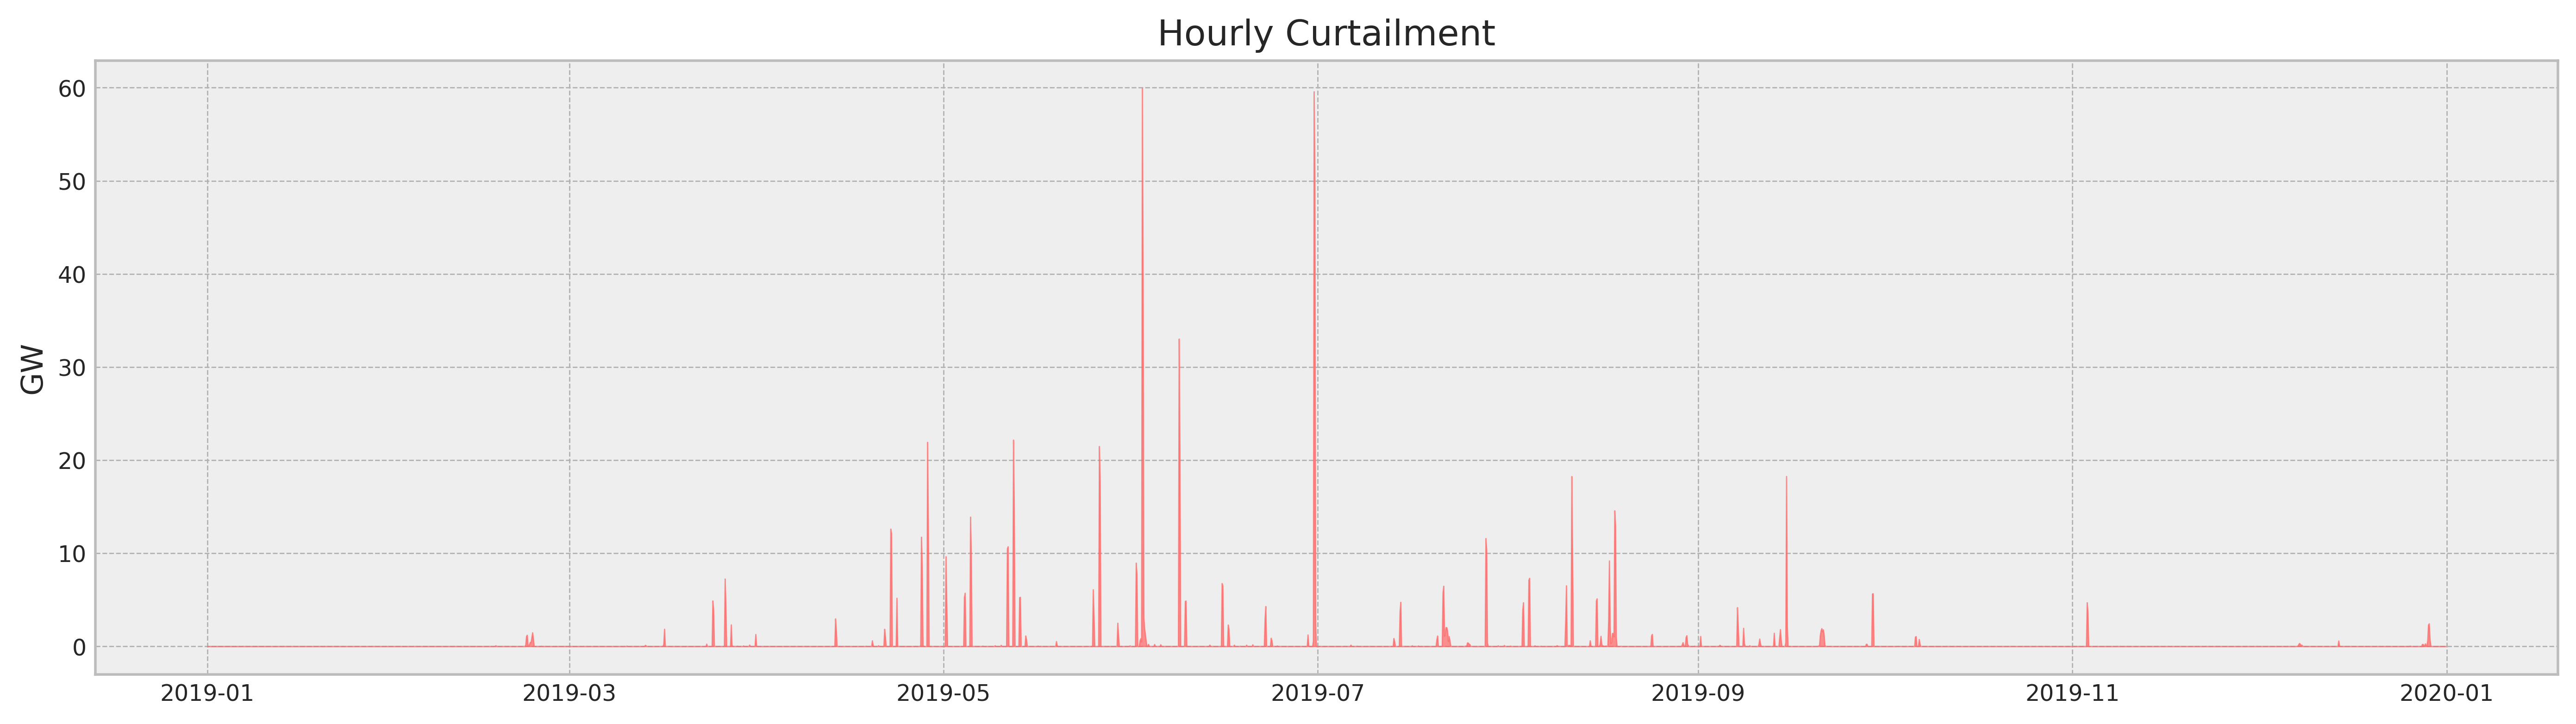

In [52]:
# Hourly curtailment (uses re_g defined in helpers)
p_max = n.generators_t.p_max_pu[re_g] * n.generators.loc[re_g, 'p_nom_opt']
p_act = n.generators_t.p[re_g]
curt_h = (p_max - p_act).clip(lower=0).sum(axis=1) / 1e3  # GW

pot = p_max.sum().sum() / 1e6  # TWh
act = p_act.sum().sum() / 1e6  # TWh
print(f"RE potential: {pot:.2f} TWh, actual: {act:.2f} TWh")
print(f"Curtailment: {pot-act:.2f} TWh ({(pot-act)/pot*100:.1f}%)")

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(curt_h.index, curt_h.values, alpha=0.7, color='#ff6666')
ax.set_ylabel('GW')
ax.set_title('Hourly Curtailment')
plt.savefig(OUTPUT_DIR / 'curtailment_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Prices

/home/abi/miniconda3/envs/pypsa-eurelectric/lib/python3.12/site-packages/pypsa/statistics/expressions.py:249: DeprecationWarning:

`aggregate_time` is deprecated as an argument to `withdrawal`; use `groupby_time` instead. Deprecated in version 1.0. Will be removed in version 2.0.

/home/abi/miniconda3/envs/pypsa-eurelectric/lib/python3.12/site-packages/pypsa/statistics/abstract.py:215: DeprecationWarning:

Passing `aggregate_across_components` was Deprecated in <!-- md:badge-version v1.0.0 -->.0 and will be removed with v2.0.0. Use e.g. `n.statistics.installed_capacity.groupby(<col_name>).sum() instead.

/home/abi/miniconda3/envs/pypsa-eurelectric/lib/python3.12/site-packages/pypsa/statistics/expressions.py:249: DeprecationWarning:

`aggregate_time` is deprecated as an argument to `withdrawal`; use `groupby_time` instead. Deprecated in version 1.0. Will be removed in version 2.0.

/home/abi/miniconda3/envs/pypsa-eurelectric/lib/python3.12/site-packages/pypsa/statistics/abstract.py:215:

=== AVERAGE PRICES BY CARRIER (EUR/MWh) ===
carrier
AC                             54.34
EV battery                     63.26
H2                             44.13
agriculture machinery oil      57.51
battery                        54.20
biogas                          0.23
co2                            -6.47
co2 sequestered               -17.51
co2 stored                     17.91
coal                            9.57
coal for industry              11.75
gas                            24.83
gas for industry               26.12
home battery                   61.35
industry dsr flexibility       64.43
industry methanol              78.23
kerosene for aviation          57.51
land transport oil             57.51
low voltage                    61.91
methanol                       76.62
naphtha for industry           56.02
non-sequestered HVC            -1.67
none                            0.00
oil                            55.84
oil primary                    52.92
process emissions      

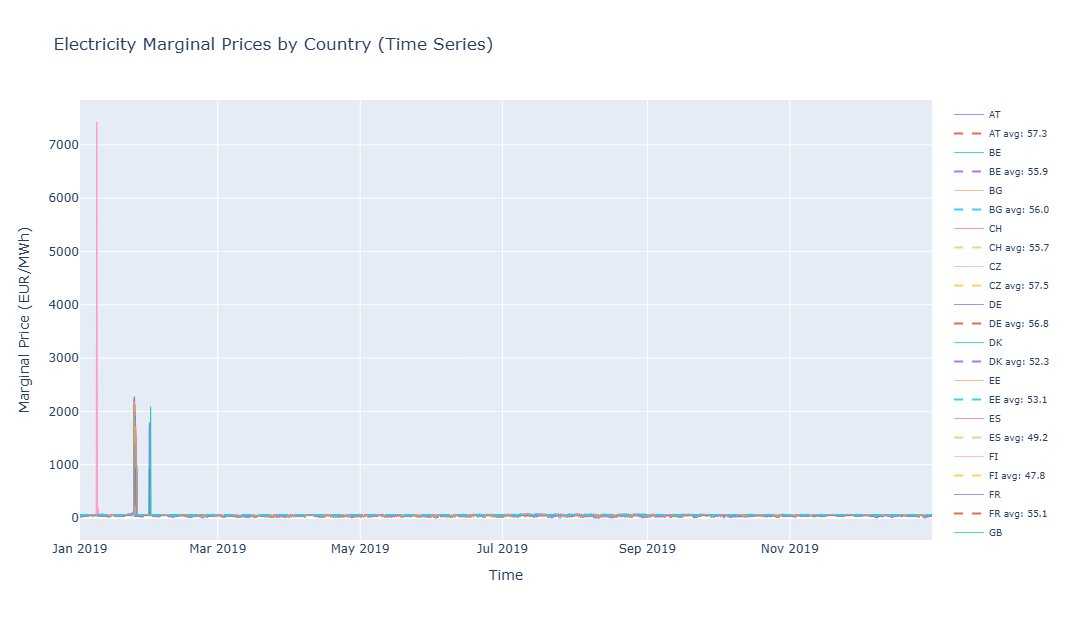

In [53]:
# 5. PRICES - Using calculate_prices and calculate_weighted_prices from make_summary.py
avg_prices = calculate_prices(n)
weighted_prices = calculate_weighted_prices(n)

print("=== AVERAGE PRICES BY CARRIER (EUR/MWh) ===")
print(avg_prices.round(2))

print("\n=== LOAD-WEIGHTED PRICES (EUR/MWh) ===")
print(weighted_prices.round(2))

# Also get metrics for price statistics
metrics = calculate_metrics(n)
print("\n=== PRICE METRICS ===")
price_metrics = metrics[metrics.index.str.contains('price')]
print(price_metrics.round(2))

# Get hourly AC prices for duration curve (load-weighted average across buses)
if len(ac_buses) > 0:
    prices_hourly = n.buses_t.marginal_price[ac_buses]
    load_ac = n.loads_t.p_set[n.loads[n.loads.bus.isin(ac_buses)].index]
    weights = load_ac.sum(axis=1)
    lw_price = (prices_hourly.multiply(weights, axis=0).sum(axis=1) / weights).fillna(prices_hourly.mean(axis=1))
else:
    lw_price = pd.Series(0, index=n.snapshots)

print(f"\nLoad-weighted electricity price (EU average): {lw_price.mean():.2f} EUR/MWh")

# === MARGINAL PRICES BY COUNTRY ===
if len(ac_buses) > 0:
    import plotly.graph_objects as go
    
    countries = pd.Series({b: get_country(b) for b in ac_buses})
    avg_price_by_country = prices_hourly.mean().groupby(countries).mean()

    print("\n=== MARGINAL PRICES BY COUNTRY (EUR/MWh) ===")
    print(avg_price_by_country.sort_values(ascending=False).round(2))

    # Time series plot of marginal prices by country (interactive with plotly)
    price_by_country_ts = prices_hourly.T.groupby(countries).mean().T  # Time series by country
    
    fig = go.Figure()
    
    for country in price_by_country_ts.columns:
        country_avg = avg_price_by_country[country]
        # Add time series
        fig.add_trace(go.Scatter(
            x=price_by_country_ts.index,
            y=price_by_country_ts[country],
            mode='lines',
            name=f'{country}',
            opacity=0.7,
            line=dict(width=1)
        ))
        # Add average line for this country
        fig.add_trace(go.Scatter(
            x=[price_by_country_ts.index[0], price_by_country_ts.index[-1]],
            y=[country_avg, country_avg],
            mode='lines',
            name=f'{country} avg: {country_avg:.1f}',
            line=dict(dash='dash', width=2),
            opacity=0.9
        ))
    
    fig.update_layout(
        title='Electricity Marginal Prices by Country (Time Series)',
        xaxis_title='Time',
        yaxis_title='Marginal Price (EUR/MWh)',
        legend=dict(x=1.02, y=1, font=dict(size=9)),
        hovermode='x unified',
        height=600,
        width=1200
    )
    
    fig.show()

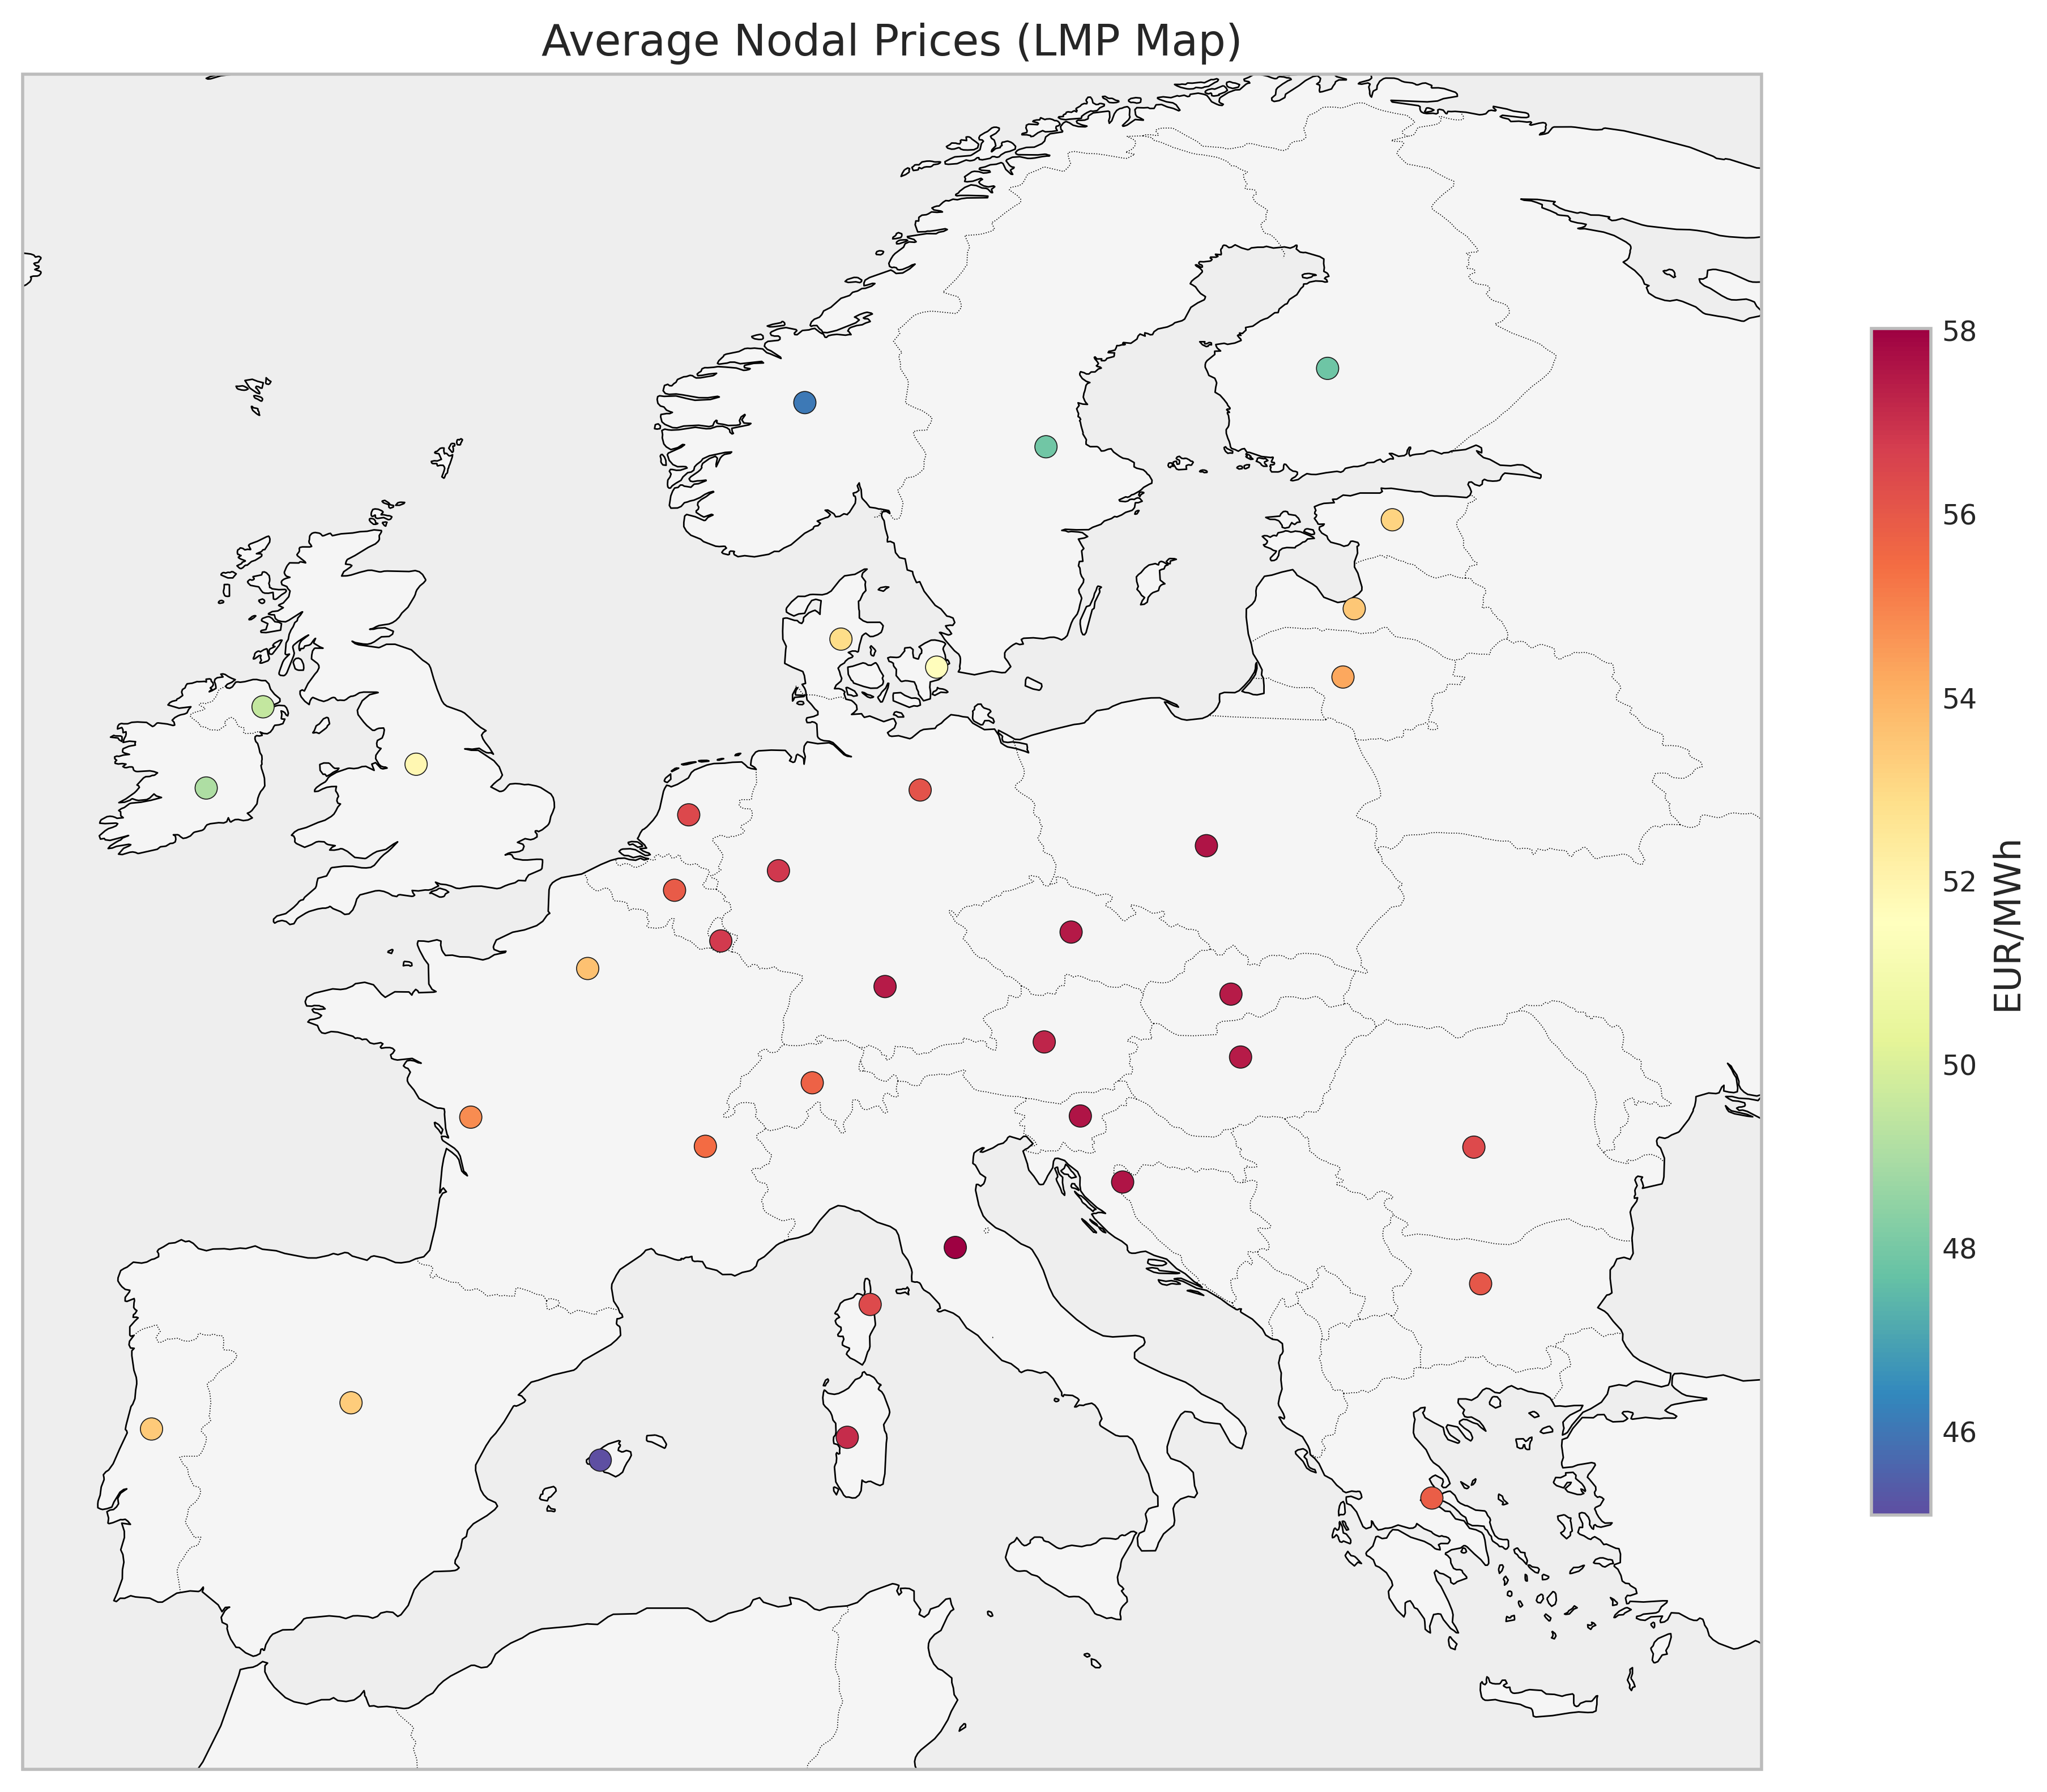

In [54]:
# LMP Map (requires cartopy)
if HAS_CARTOPY and len(ac_buses) > 0:
    avg_p = prices_hourly.mean()
    bus_xy = n.buses.loc[ac_buses, ['x', 'y']].copy()
    bus_xy['price'] = avg_p
    bus_xy = bus_xy.dropna()

    # Use EqualEarth projection directly
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.EqualEarth()})
    bounds = plotting_config.get('map', {}).get('boundaries', [-11, 30, 34, 71])
    ax.set_extent(bounds, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='whitesmoke')

    sc = ax.scatter(bus_xy['x'], bus_xy['y'], c=bus_xy['price'], s=50, cmap='Spectral_r',
                    transform=ccrs.PlateCarree(), edgecolor='k', linewidth=0.3, zorder=10)
    plt.colorbar(sc, ax=ax, label='EUR/MWh', shrink=0.7)
    ax.set_title('Average Nodal Prices (LMP Map)')
    plt.savefig(OUTPUT_DIR / 'lmp_map.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    logger.info("Skipping LMP map (cartopy not available or no AC buses)")

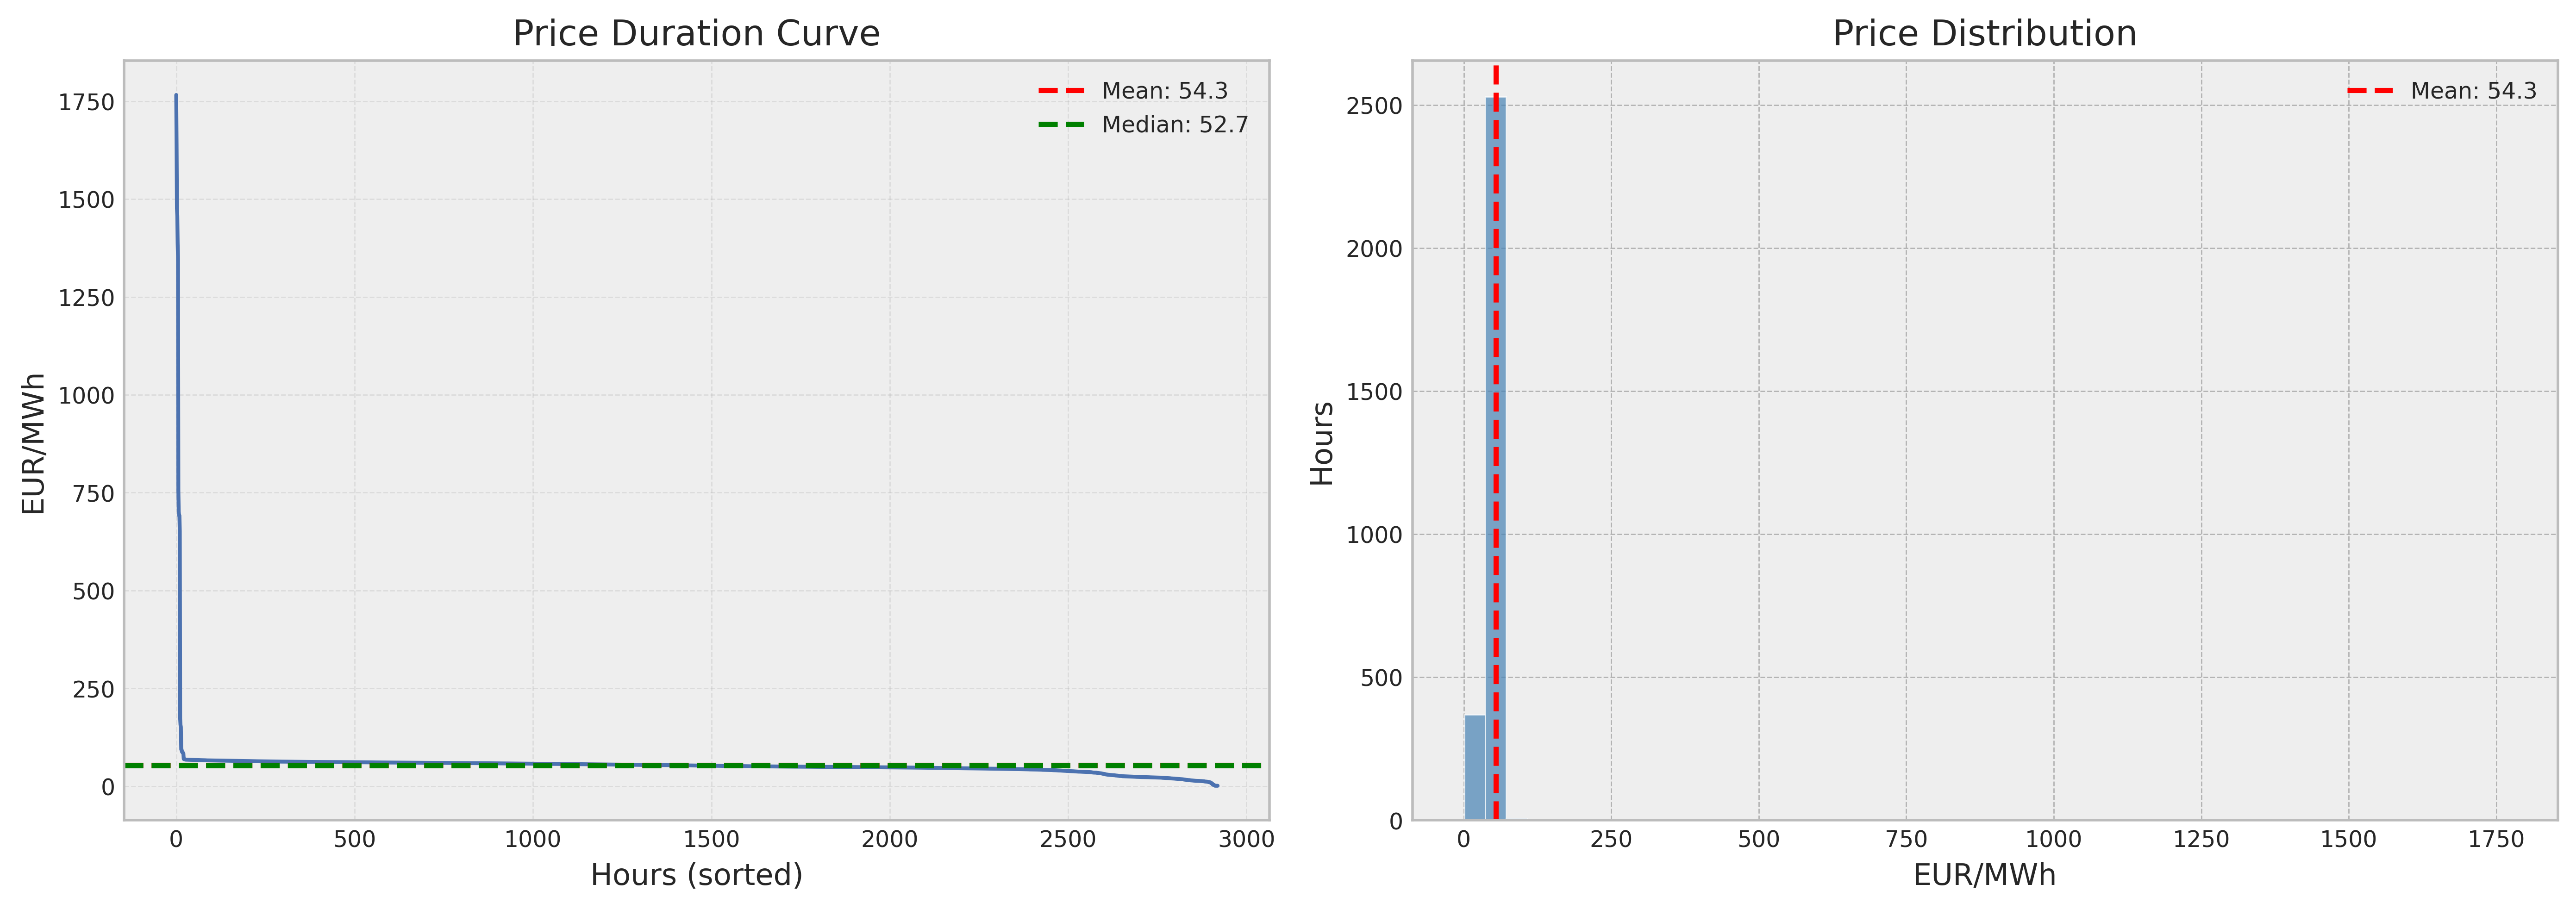

=== WHOLESALE PRICE STATISTICS ===
Mean: 54.34 EUR/MWh
Median: 52.75 EUR/MWh
Std Dev: 72.96 EUR/MWh
Min: 1.09 EUR/MWh
Max: 1765.96 EUR/MWh
Hours < 0: 0 (0.0%)
Hours > 100: 14 (0.5%)


In [55]:
# 5b. PRICE DURATION CURVE
price_sorted = lw_price.sort_values(ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration curve
axes[0].plot(price_sorted.values, 'b-', lw=1.5)
axes[0].axhline(lw_price.mean(), color='red', linestyle='--', label=f'Mean: {lw_price.mean():.1f}')
axes[0].axhline(lw_price.median(), color='green', linestyle='--', label=f'Median: {lw_price.median():.1f}')
axes[0].set_xlabel('Hours (sorted)')
axes[0].set_ylabel('EUR/MWh')
axes[0].set_title('Price Duration Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(lw_price.values, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(lw_price.mean(), color='red', linestyle='--', lw=2, label=f'Mean: {lw_price.mean():.1f}')
axes[1].set_xlabel('EUR/MWh')
axes[1].set_ylabel('Hours')
axes[1].set_title('Price Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'price_duration.png', dpi=150, bbox_inches='tight')
plt.show()

# Price statistics
print("=== WHOLESALE PRICE STATISTICS ===")
print(f"Mean: {lw_price.mean():.2f} EUR/MWh")
print(f"Median: {lw_price.median():.2f} EUR/MWh")
print(f"Std Dev: {lw_price.std():.2f} EUR/MWh")
print(f"Min: {lw_price.min():.2f} EUR/MWh")
print(f"Max: {lw_price.max():.2f} EUR/MWh")
print(f"Hours < 0: {(lw_price < 0).sum()} ({(lw_price < 0).mean()*100:.1f}%)")
print(f"Hours > 100: {(lw_price > 100).sum()} ({(lw_price > 100).mean()*100:.1f}%)")

## 8. Marginal Technology

##new heuristic method

In [56]:
import numpy as np
import pandas as pd

ac_mask = (n.buses.carrier == 'AC') & (n.buses.country != '')
ac_buses_by_country = n.buses.loc[ac_mask].groupby('country').groups

w = n.snapshot_weightings.objective
hours = w.sum()

all_country_results_heuristic = {}

for ct, ct_buses in ac_buses_by_country.items():
    ct_buses_set = set(ct_buses)
    ct_price = n.buses_t.marginal_price[list(ct_buses)].mean(axis=1)

    ct_gens = n.generators.index[
        n.generators.bus.isin(ct_buses_set) & (n.generators.p_nom_opt > 1)
    ]
    ct_links = n.links.index[
        n.links.bus1.isin(ct_buses_set)
        & (~n.links.carrier.isin(['DC', 'electricity distribution grid']))
        & (n.links.p_nom_opt > 1)
    ]

    marg = []
    for t in n.snapshots:
        p = ct_price[t]
        best_carrier = None
        best_diff = float('inf')

        for g in ct_gens:
            d = n.generators_t.p.at[t, g]
            cap = n.generators.p_nom_opt[g]
            c = n.generators.carrier[g]

            # FIX: Use p_max_pu for ALL generators (not just RES)
            # Time-varying p_max_pu takes priority, else use static value
            if g in n.generators_t.p_max_pu.columns:
                p_max_pu = n.generators_t.p_max_pu.at[t, g]
            else:
                p_max_pu = n.generators.p_max_pu[g]
            avail = p_max_pu * cap

            mc = (
                n.generators_t.marginal_cost.at[t, g]
                if g in n.generators_t.marginal_cost.columns
                else n.generators.marginal_cost[g]
            )

            if d > 1 and d < (avail - 1):
                diff = abs(p - mc)
                if diff < best_diff:
                    best_diff = diff
                    best_carrier = c

        for l in ct_links:
            d = n.links_t.p0.at[t, l]
            cap = n.links.p_nom_opt[l]
            eff = n.links.efficiency[l]
            mc = n.links.marginal_cost[l] / eff if eff > 0 else 0

            if d > 1 and d < (cap - 1):
                diff = abs(p - mc)
                if diff < best_diff:
                    best_diff = diff
                    best_carrier = n.links.carrier[l]

        if best_carrier is None:
            if p <= 0:
                best_carrier = 'RES curtailment'
            elif p > 300:
                best_carrier = 'Scarcity'
            else:
                best_carrier = 'Imports/other'

        marg.append(best_carrier)

    marg = pd.Series(marg, index=n.snapshots)
    weighted = marg.groupby(marg).apply(lambda x: w.loc[x.index].sum())
    all_country_results_heuristic[ct] = (weighted / hours * 100).round(1)

    print(f"\n=== {ct} ===")
    for tech, pct in weighted.sort_values(ascending=False).items():
        print(f"  {tech:<35s} {pct:>7.0f}h  ({pct/hours*100:>5.1f}%)")

summary_heuristic = pd.DataFrame(all_country_results_heuristic).fillna(0).T
print("\n\n=== ALL COUNTRIES (% of hours) ===")
print(summary_heuristic.to_string())

print("\n\n=== EU AVERAGE (simple mean across countries) ===")
eu_avg = summary_heuristic.mean().sort_values(ascending=False).round(1)
for tech, pct in eu_avg.items():
    if pct > 0.1:
        print(f"  {tech:<35s} {pct:>5.1f}%")


=== AT ===
  Imports/other                          7908h  ( 90.3%)
  urban central gas CHP                   672h  (  7.7%)
  urban central solid biomass CHP         102h  (  1.2%)
  Scarcity                                 30h  (  0.3%)
  onwind                                   27h  (  0.3%)
  solar                                     9h  (  0.1%)
  ror                                       6h  (  0.1%)
  solar-hsat                                6h  (  0.1%)

=== BE ===
  Imports/other                          6600h  ( 75.3%)
  urban central gas CHP                  1968h  ( 22.5%)
  nuclear                                  96h  (  1.1%)
  urban central solid biomass CHP          36h  (  0.4%)
  Scarcity                                 30h  (  0.3%)
  offwind-ac                               27h  (  0.3%)
  onwind                                    3h  (  0.0%)

=== BG ===
  Imports/other                          6675h  ( 76.2%)
  urban central gas CHP                  1635h  ( 18

luis's corrected version by cursor

In [60]:
# Marginal Price Setting Technology - Shadow Price Approach
# Uses mu_upper and mu_lower to identify truly marginal generators
# Enhanced: Traces import source via DC links AND AC lines

from collections import Counter

MU_TOL = 1.0  # Tolerance for shadow prices (EUR/MWh)

# Get DC links and cross-border AC lines for import tracing
dc_links_all = n.links[n.links.carrier == 'DC']

bus_country = n.buses.country
cross_border_lines = n.lines[
    n.lines.bus0.map(lambda b: bus_country.get(b, '')) != 
    n.lines.bus1.map(lambda b: bus_country.get(b, ''))
]

def find_marginal_in_country(country_code, t):
    # AC buses only
    country_buses = set(n.buses.index[(n.buses.country == country_code) & (n.buses.carrier == "AC")])
    if not country_buses:
        return None

    carriers = []

    # generators on AC buses
    gens = n.generators.index[n.generators.bus.isin(country_buses) & (n.generators.p_nom_opt > 1)]
    for g in gens:
        if g not in n.generators_t.mu_upper.columns:
            continue
        mu_up = abs(n.generators_t.mu_upper.at[t, g])
        mu_lo = abs(n.generators_t.mu_lower.at[t, g])
        dispatch = n.generators_t.p.at[t, g]
        lam = n.buses_t.marginal_price.at[t, n.generators.bus[g]]
        mc = n.generators_t.marginal_cost.at[t, g] if g in n.generators_t.marginal_cost.columns else n.generators.marginal_cost[g]

        if mu_up < 1e-2 and mu_lo < 1e-2 and dispatch > 0.1 and abs(mc - lam) < 5.0:
            carriers.append(n.generators.carrier[g])

    # electricity-relevant links injecting to AC bus
    links = n.links.index[
        n.links.bus1.isin(country_buses)
        & (~n.links.carrier.isin(["DC", "electricity distribution grid", "gas pipeline", "gas pipeline new"]))
        & (n.links.p_nom_opt > 1)
    ]
    for l in links:
        if l not in n.links_t.mu_upper.columns:
            continue
        mu_up = abs(n.links_t.mu_upper.at[t, l])
        mu_lo = abs(n.links_t.mu_lower.at[t, l])
        dispatch = n.links_t.p0.at[t, l]
        if mu_up < 1e-2 and mu_lo < 1e-2 and dispatch > 0.1:
            carriers.append(n.links.carrier[l])

    return Counter(carriers).most_common(1)[0][0] if carriers else None

all_country_results_shadow = {}
all_country_hours_shadow = {}

for ct, ct_buses in ac_buses_by_country.items():
    ct_buses_set = set(ct_buses)
    ct_price = n.buses_t.marginal_price[list(ct_buses)].mean(axis=1)

    ct_gens = n.generators.index[
        n.generators.bus.isin(ct_buses_set) & (n.generators.p_nom_opt > 1)
    ]
    ct_links = n.links.index[
        n.links.bus1.isin(ct_buses_set)
        & (~n.links.carrier.isin(['DC', 'electricity distribution grid']))
        & (n.links.p_nom_opt > 1)
    ]
    
    ct_dc = dc_links_all[dc_links_all.bus0.isin(ct_buses_set) | dc_links_all.bus1.isin(ct_buses_set)]
    ct_ac_lines = cross_border_lines[
        cross_border_lines.bus0.isin(ct_buses_set) | cross_border_lines.bus1.isin(ct_buses_set)
    ]

    marg = []
    for t in n.snapshots:
        marginal_carriers = []
        p = ct_price[t]

        for g in ct_gens:
            mu_upper = n.generators_t.mu_upper.at[t, g] if g in n.generators_t.mu_upper.columns else 0.0
            mu_lower = n.generators_t.mu_lower.at[t, g] if g in n.generators_t.mu_lower.columns else 0.0
            dispatch = n.generators_t.p.at[t, g]

            if (abs(mu_upper) < MU_TOL) and (abs(mu_lower) < MU_TOL) and dispatch > 0.1:
                marginal_carriers.append(n.generators.carrier[g])

        for l in ct_links:
            mu_upper = n.links_t.mu_upper.at[t, l] if l in n.links_t.mu_upper.columns else 0.0
            mu_lower = n.links_t.mu_lower.at[t, l] if l in n.links_t.mu_lower.columns else 0.0
            dispatch = n.links_t.p0.at[t, l]

            if (abs(mu_upper) < MU_TOL) and (abs(mu_lower) < MU_TOL) and dispatch > 0.1:
                marginal_carriers.append(n.links.carrier[l])

        if len(marginal_carriers) > 0:
            best_carrier = Counter(marginal_carriers).most_common(1)[0][0]
        else:
            best_carrier = None
            import_sources = []
            
            for link in ct_dc.index:
                if n.links.bus1[link] in ct_buses_set:
                    flow = n.links_t.p0.at[t, link]
                    importing = flow > 1
                    exporter_bus = n.links.bus0[link]
                else:
                    flow = n.links_t.p0.at[t, link]
                    importing = flow < -1
                    exporter_bus = n.links.bus1[link]
                
                if importing:
                    exp_country = bus_country[exporter_bus]
                    import_sources.append((abs(flow), exp_country, 'DC'))
            
            for line in ct_ac_lines.index:
                bus0, bus1 = n.lines.bus0[line], n.lines.bus1[line]
                flow = n.lines_t.p0.at[t, line] if line in n.lines_t.p0.columns else 0
                
                if bus0 in ct_buses_set:
                    importing = flow < -1
                    exporter_bus = bus1
                else:
                    importing = flow > 1
                    exporter_bus = bus0
                
                if importing:
                    exp_country = bus_country[exporter_bus]
                    import_sources.append((abs(flow), exp_country, 'AC'))
            
            import_sources.sort(reverse=True)
            
            for flow, exp_country, link_type in import_sources:
                exp_marginal = find_marginal_in_country(exp_country, t)
                if exp_marginal:
                    best_carrier = f'Imports ({exp_country}: {exp_marginal})'
                    break
            
            if best_carrier is None:
                if p <= 0:
                    best_carrier = 'RES curtailment'
                elif p > 300:
                    best_carrier = 'Scarcity'
                else:
                    best_carrier = 'Imports/other'

        marg.append(best_carrier)

    marg = pd.Series(marg, index=n.snapshots)
    weighted = marg.groupby(marg).apply(lambda x: w.loc[x.index].sum())
    all_country_results_shadow[ct] = (weighted / hours * 100).round(1)
    all_country_hours_shadow[ct] = weighted.round(1)
    
from pathlib import Path
summary_shadow = pd.DataFrame(all_country_results_shadow).fillna(0).T
hours_shadow = pd.DataFrame(all_country_hours_shadow).fillna(0).T
print("\n\n=== ALL COUNTRIES (% of hours) ===")
print(summary_shadow.to_string())
print("\n\n=== EU AVERAGE (simple mean across countries) ===")
eu_avg = summary_shadow.mean().sort_values(ascending=False).round(1)
for tech, pct in eu_avg.items():
    if pct > 0.1:
        print(f"  {tech:<45s} {pct:>5.1f}%")
# Save to Excel
OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
excel_path = OUTPUT_DIR / "marginal_tech_shadow_results.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    summary_shadow.sort_index().to_excel(writer, sheet_name="country_pct_hours")
    hours_shadow.sort_index().to_excel(writer, sheet_name="country_hours")
    eu_avg.to_frame(name="EU_average_pct").to_excel(writer, sheet_name="eu_average")
print(f"\nSaved Excel: {excel_path}")



=== ALL COUNTRIES (% of hours) ===
    CCGT  Imports (AT: ror)  Imports (AT: solar)  Imports (AT: urban central gas CHP)  Imports (AT: urban central solid biomass CHP)  Imports (BE: nuclear)  Imports (BE: urban central gas CHP)  Imports (BE: urban central solid biomass CHP)  Imports (BG: nuclear)  Imports (BG: urban central gas CHP)  Imports (CH: nuclear)  Imports (CH: urban central solid biomass CHP)  Imports (CZ: nuclear)  Imports (CZ: urban central gas CHP)  Imports (CZ: urban central solid biomass CHP)  Imports (DE: CCGT)  Imports (DE: OCGT)  Imports (DE: onwind)  Imports (DE: urban central gas CHP)  Imports (DE: urban central solid biomass CHP)  Imports (DK: offwind-ac)  Imports (DK: onwind)  Imports (DK: urban central solid biomass CHP)  Imports (EE: onwind)  Imports (EE: urban central solid biomass CHP)  Imports (ES: nuclear)  Imports (ES: onwind)  Imports (ES: solar)  Imports (ES: urban central solid biomass CHP)  Imports (FI: urban central solid biomass CHP)  Imports (FR: nu

## 8. Marginal Technology
8b. Marginal Price Setting - Country-Level (Heuristic Approach)
Identifies the price-setting technology per country and hour using a heuristic approach:

Find generators/links operating at partial load (not at min or max capacity)
Among those, the one with marginal cost closest to the nodal price is the price-setter
Fallback categories for hours where no marginal unit is found

In [57]:
import numpy as np
import pandas as pd

ac_mask = (n.buses.carrier == 'AC') & (n.buses.country != '')
ac_buses_by_country = n.buses.loc[ac_mask].groupby('country').groups

RES = {'solar', 'solar rooftop', 'solar-hsat', 'onwind', 'offwind-ac', 'offwind-dc'}
w = n.snapshot_weightings.objective
hours = w.sum()

all_country_results = {}

for ct, ct_buses in ac_buses_by_country.items():
    ct_buses_set = set(ct_buses)
    ct_price = n.buses_t.marginal_price[list(ct_buses)].mean(axis=1)

    ct_gens = n.generators.index[
        n.generators.bus.isin(ct_buses_set) & (n.generators.p_nom_opt > 1)
    ]
    ct_links = n.links.index[
        n.links.bus1.isin(ct_buses_set)
        & (~n.links.carrier.isin(['DC', 'electricity distribution grid']))
        & (n.links.p_nom_opt > 1)
    ]

    marg = []
    for t in n.snapshots:
        p = ct_price[t]
        best_carrier = None
        best_diff = float('inf')

        for g in ct_gens:
            d = n.generators_t.p.at[t, g]
            cap = n.generators.p_nom_opt[g]
            c = n.generators.carrier[g]

            if c in RES:
                avail = (
                    n.generators_t.p_max_pu.at[t, g] * cap
                    if g in n.generators_t.p_max_pu.columns
                    else cap
                )
            else:
                avail = cap

            mc = (
                n.generators_t.marginal_cost.at[t, g]
                if g in n.generators_t.marginal_cost.columns
                else n.generators.marginal_cost[g]
            )

            if d > 1 and d < (avail - 1):
                diff = abs(p - mc)
                if diff < best_diff:
                    best_diff = diff
                    best_carrier = c

        for l in ct_links:
            d = n.links_t.p0.at[t, l]
            cap = n.links.p_nom_opt[l]
            eff = n.links.efficiency[l]
            mc = n.links.marginal_cost[l] / eff if eff > 0 else 0

            if d > 1 and d < (cap - 1):
                diff = abs(p - mc)
                if diff < best_diff:
                    best_diff = diff
                    best_carrier = n.links.carrier[l]

        if best_carrier is None:
            if p <= 0:
                best_carrier = 'RES curtailment'
            elif p > 300:
                best_carrier = 'Scarcity'
            else:
                best_carrier = 'Imports/other'

        marg.append(best_carrier)

    marg = pd.Series(marg, index=n.snapshots)
    weighted = marg.groupby(marg).apply(lambda x: w.loc[x.index].sum())
    all_country_results[ct] = (weighted / hours * 100).round(1)

    print(f"\n=== {ct} ===")
    for tech, pct in weighted.sort_values(ascending=False).items():
        print(f"  {tech:<35s} {pct:>7.0f}h  ({pct/hours*100:>5.1f}%)")

summary = pd.DataFrame(all_country_results).fillna(0).T
print("\n\n=== ALL COUNTRIES (% of hours) ===")
print(summary.to_string())
print("\n\n=== EU AVERAGE (simple mean across countries) ===")
eu_avg = summary.mean().sort_values(ascending=False).round(1)
for tech, pct in eu_avg.items():
    if pct > 0.1:
        print(f"  {tech:<35s} {pct:>5.1f}%")


=== AT ===
  ror                                    7230h  ( 82.5%)
  Imports/other                           714h  (  8.2%)
  urban central gas CHP                   672h  (  7.7%)
  urban central solid biomass CHP         102h  (  1.2%)
  onwind                                   27h  (  0.3%)
  solar                                     9h  (  0.1%)
  solar-hsat                                6h  (  0.1%)

=== BE ===
  nuclear                                8607h  ( 98.3%)
  ror                                      72h  (  0.8%)
  urban central solid biomass CHP          36h  (  0.4%)
  offwind-ac                               27h  (  0.3%)
  Imports/other                            15h  (  0.2%)
  onwind                                    3h  (  0.0%)

=== BG ===
  nuclear                                8571h  ( 97.8%)
  ror                                      96h  (  1.1%)
  onwind                                   66h  (  0.8%)
  solar                                    27h  (  0

## 8c. Marginal Price Setting - Country-Level (Shadow Prices + MC Verification)
Uses optimization shadow prices (dual values) with MC verification for rigorous identification:

A generator is marginal when mu_upper ≈ 0 and mu_lower ≈ 0 (neither capacity bound is binding)
Verification: Confirm MC ≈ price (from KKT: when unconstrained, price = MC)
From KKT conditions: price = MC + mu_upper - mu_lower, so when both μ = 0, price = MC
This is mathematically exact, not a heuristic

In [59]:
# Marginal Price Setting Technology - Shadow Price Approach (with MC Verification)
# Uses mu_upper and mu_lower to identify truly marginal generators
# Adds verification that MC ≈ price (from KKT optimality conditions)

MU_TOL = 0.01    # Numerical tolerance for shadow prices
MC_TOL = 5.0     # Tolerance for MC ≈ price verification (EUR/MWh)

all_country_results_shadow = {}

for ct, ct_buses in ac_buses_by_country.items():
    ct_buses_set = set(ct_buses)
    ct_price = n.buses_t.marginal_price[list(ct_buses)].mean(axis=1)

    ct_gens = n.generators.index[
        n.generators.bus.isin(ct_buses_set) & (n.generators.p_nom_opt > 1)
    ]
    ct_links = n.links.index[
        n.links.bus1.isin(ct_buses_set)
        & (~n.links.carrier.isin(['DC', 'electricity distribution grid']))
        & (n.links.p_nom_opt > 1)
    ]

    marg = []
    for t in n.snapshots:
        p = ct_price[t]
        marginal_carriers = []

        # Check generators using shadow prices + MC verification
        for g in ct_gens:
            mu_upper = (
                n.generators_t.mu_upper.at[t, g]
                if g in n.generators_t.mu_upper.columns
                else 0.0
            )
            mu_lower = (
                n.generators_t.mu_lower.at[t, g]
                if g in n.generators_t.mu_lower.columns
                else 0.0
            )
            dispatch = n.generators_t.p.at[t, g]

            # Get marginal cost for verification
            mc = (
                n.generators_t.marginal_cost.at[t, g]
                if g in n.generators_t.marginal_cost.columns
                else n.generators.marginal_cost[g]
            )

            # Generator is marginal if:
            # 1. Neither capacity constraint is binding (mu ≈ 0)
            # 2. It's actually producing
            # 3. Its MC ≈ price (KKT verification)
            is_unconstrained = (abs(mu_upper) < MU_TOL) and (abs(mu_lower) < MU_TOL)
            is_producing = dispatch > 0.1
            mc_matches_price = abs(mc - p) < MC_TOL

            is_marginal = is_unconstrained and is_producing and mc_matches_price

            if is_marginal:
                marginal_carriers.append(n.generators.carrier[g])

        # Check links using shadow prices + MC verification
        for l in ct_links:
            mu_upper = (
                n.links_t.mu_upper.at[t, l]
                if l in n.links_t.mu_upper.columns
                else 0.0
            )
            mu_lower = (
                n.links_t.mu_lower.at[t, l]
                if l in n.links_t.mu_lower.columns
                else 0.0
            )
            dispatch = n.links_t.p0.at[t, l]

            # Get marginal cost
            eff = n.links.efficiency[l]
            mc = n.links.marginal_cost[l] / eff if eff > 0 else 0

            is_unconstrained = (abs(mu_upper) < MU_TOL) and (abs(mu_lower) < MU_TOL)
            is_producing = dispatch > 0.1
            mc_matches_price = abs(mc - p) < MC_TOL

            is_marginal = is_unconstrained and is_producing and mc_matches_price

            if is_marginal:
                marginal_carriers.append(n.links.carrier[l])

        # Determine price-setter
        if len(marginal_carriers) == 0:
            if p <= 0:
                best_carrier = 'RES curtailment'
            elif p > 300:
                best_carrier = 'Scarcity'
            else:
                best_carrier = 'Transmission/other'
        elif len(marginal_carriers) == 1:
            best_carrier = marginal_carriers[0]
        else:
            # Multiple marginal units (all have MC ≈ price) - pick most common
            best_carrier = max(set(marginal_carriers), key=marginal_carriers.count)

        marg.append(best_carrier)

    marg = pd.Series(marg, index=n.snapshots)
    weighted = marg.groupby(marg).apply(lambda x: w.loc[x.index].sum())
    all_country_results_shadow[ct] = (weighted / hours * 100).round(1)

summary_shadow = pd.DataFrame(all_country_results_shadow).fillna(0).T

print("=== MARGINAL TECHNOLOGY BY COUNTRY (Shadow Prices + MC Verification) ===")
print(summary_shadow.to_string())

print("\n=== EU AVERAGE (Shadow Prices + MC Verification) ===")
eu_avg = summary_shadow.mean().sort_values(ascending=False).round(1)
for tech, pct in eu_avg.items():
    if pct > 0.1:
        print(f"  {tech:<35s} {pct:>5.1f}%")

# Save to CSV
summary_shadow.to_csv(OUTPUT_DIR / 'marginal_tech_shadow.csv')
print(f"\nSaved to {OUTPUT_DIR / 'marginal_tech_shadow.csv'}")

=== MARGINAL TECHNOLOGY BY COUNTRY (Shadow Prices + MC Verification) ===
    RES curtailment  Scarcity  Transmission/other  nuclear  offwind-ac  offwind-dc  onwind  ror  solar  solar-hsat  urban central solid biomass CHP
AT              0.0       0.3                99.3      0.0         0.0         0.0     0.2  0.1    0.1         0.0                              0.1
BE              0.0       0.3                98.6      1.0         0.1         0.0     0.0  0.0    0.0         0.0                              0.0
BG              0.0       0.0                97.0      2.5         0.0         0.0     0.3  0.0    0.1         0.0                              0.0
CH              0.0       0.3                99.0      0.5         0.0         0.0     0.0  0.0    0.0         0.0                              0.1
CZ              0.0       0.3                98.9      0.6         0.0         0.0     0.1  0.0    0.0         0.0                              0.0
DE              0.0       0.3          

# Tom Brown methodology

In [ ]:
# v4 FINAL (merged + robust summaries)
# ------------------------------------
# Multi-node KKT-informed marginal price-setter classification
# Includes:
# - generator effective bids with duals
# - link bid reconstruction + incidence-sign side logic
# - storage-unit SOC/intertemporal bids (mu_energy_balance)
# - iterative import resolution
# - explicit bid table
# - robust summary aggregation (no groupby.apply rename issue)

import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from pathlib import Path
import time

# ---------------------------
# User switches
# ---------------------------
TEST_MODE = False
TEST_COUNTRIES = ["DE", "IT"]
TEST_MAX_SNAPSHOTS = 240
VERBOSE_EVERY_COUNTRY = True

# ---------------------------
# Parameters
# ---------------------------
PRICE_MATCH_TOL = 0.2
UTIL_MAX = 0.99
UTIL_MIN = 0.01
ENERGY_MIN_MWH = 10.0
P_EPS = 1e-6
MU_TOL = 1e-6
KKT_RES_TOL = 1e-3
PRICE_COUPLING_TOL = 1.0
SCARCITY_PRICE = 300.0
MAX_IMPORT_ITER = 6

EXCLUDED_LINK_CARRIERS = {"DC", "electricity distribution grid"}

OUTPUT_DIR = Path("analysis_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

t0 = time.time()
print("Start script")

# ---------------------------
# Snapshots and weights
# ---------------------------
all_snapshots = n.snapshots
if TEST_MODE:
    snapshots = all_snapshots[: min(TEST_MAX_SNAPSHOTS, len(all_snapshots))]
    print(f"TEST_MODE=True -> snapshots={len(snapshots)}")
else:
    snapshots = all_snapshots
    print(f"TEST_MODE=False -> snapshots={len(snapshots)}")

w_full = n.snapshot_weightings.objective if hasattr(n.snapshot_weightings, "objective") else pd.Series(1.0, index=all_snapshots)
w = w_full.loc[snapshots]
hours = float(w.sum())

# ---------------------------
# Helpers
# ---------------------------
def has_col(df, col):
    return hasattr(df, "columns") and col in df.columns

def bus_country(bus):
    if "country" in n.buses.columns and pd.notna(n.buses.at[bus, "country"]):
        return str(n.buses.at[bus, "country"])
    return str(bus)[:2]

def ts_or_static(ts_df, static_df, t, name, col, default=np.nan):
    if hasattr(ts_df, col):
        d = getattr(ts_df, col)
        if has_col(d, name):
            return float(d.at[t, name])
    if col in static_df.columns and name in static_df.index:
        return float(static_df.at[name, col])
    return float(default)

def link_terminal_eff(l, terminal_idx):
    c = "efficiency" if terminal_idx == 1 else f"efficiency{terminal_idx}"
    if c in n.links.columns and pd.notna(n.links.at[l, c]):
        return float(n.links.at[l, c])
    return np.nan

def link_terminals(l):
    terms = [("bus0", n.links.at[l, "bus0"], -1.0)]
    if "bus1" in n.links.columns and pd.notna(n.links.at[l, "bus1"]):
        e1 = link_terminal_eff(l, 1)
        if pd.notna(e1):
            terms.append(("bus1", n.links.at[l, "bus1"], e1))
    for idx, bcol in [(2, "bus2"), (3, "bus3"), (4, "bus4")]:
        if bcol in n.links.columns and pd.notna(n.links.at[l, bcol]):
            ei = link_terminal_eff(l, idx)
            if pd.notna(ei):
                terms.append((bcol, n.links.at[l, bcol], ei))
    return terms

def cross_border_links_dc(ct_buses_set):
    mask = (
        (n.links.carrier == "DC")
        & (n.links.bus0.isin(ct_buses_set) != n.links.bus1.isin(ct_buses_set))
    )
    return n.links.index[mask]

def cross_border_lines(ct_buses_set):
    mask = n.lines.bus0.isin(ct_buses_set) != n.lines.bus1.isin(ct_buses_set)
    return n.lines.index[mask]

def neighbor_country_from_element(local_set, b0, b1):
    if b0 in local_set and b1 not in local_set:
        return bus_country(b1), b0, b1
    if b1 in local_set and b0 not in local_set:
        return bus_country(b0), b1, b0
    return None, None, None

# ---------------------------
# Dual checks
# ---------------------------
need = [
    hasattr(n.generators_t, "mu_upper"),
    hasattr(n.generators_t, "mu_lower"),
    hasattr(n.links_t, "mu_upper"),
    hasattr(n.links_t, "mu_lower"),
]
if not all(need):
    raise RuntimeError("Missing generator/link duals. Re-run with assign_all_duals: true")

have_line_mu = hasattr(n.lines_t, "mu_upper") and hasattr(n.lines_t, "mu_lower")
have_su_psi = hasattr(n.storage_units_t, "mu_energy_balance")
print("Dual availability:",
      f"gen={all(need[:2])}, links={all(need[2:])}, lines={have_line_mu}, su_psi={have_su_psi}")

# ---------------------------
# KKT core
# ---------------------------
def gen_mc(t, g):
    return ts_or_static(n.generators_t, n.generators, t, g, "marginal_cost", default=0.0)

def gen_stationarity_residual(t, g, dual_sign=+1.0):
    lam = float(n.buses_t.marginal_price.at[t, n.generators.at[g, "bus"]])
    mc = gen_mc(t, g)
    mu_u = float(n.generators_t.mu_upper.at[t, g]) if has_col(n.generators_t.mu_upper, g) else 0.0
    mu_l = float(n.generators_t.mu_lower.at[t, g]) if has_col(n.generators_t.mu_lower, g) else 0.0
    return mc - lam + dual_sign * (mu_u - mu_l)

def effective_gen_bid(t, g, dual_sign=+1.0):
    mc = gen_mc(t, g)
    mu_u = float(n.generators_t.mu_upper.at[t, g]) if has_col(n.generators_t.mu_upper, g) else 0.0
    mu_l = float(n.generators_t.mu_lower.at[t, g]) if has_col(n.generators_t.mu_lower, g) else 0.0
    return mc + dual_sign * (mu_l - mu_u)

def link_stationarity_residual(t, l, dual_sign=+1.0):
    o_k = float(n.links.at[l, "marginal_cost"]) if "marginal_cost" in n.links.columns else 0.0
    s = 0.0
    for _, b, coeff in link_terminals(l):
        if b in n.buses.index:
            s += coeff * float(n.buses_t.marginal_price.at[t, b])
    mu_u = float(n.links_t.mu_upper.at[t, l]) if has_col(n.links_t.mu_upper, l) else 0.0
    mu_l = float(n.links_t.mu_lower.at[t, l]) if has_col(n.links_t.mu_lower, l) else 0.0
    return o_k - s + dual_sign * (mu_u - mu_l)

def reconstructed_local_bid_for_terminal(t, l, local_bus_name, dual_sign=+1.0):
    terms = link_terminals(l)
    local = [x for x in terms if x[1] == local_bus_name]
    if not local:
        return np.nan
    _, _, c_local = local[0]
    if abs(c_local) <= 1e-12:
        return np.nan

    o_k = float(n.links.at[l, "marginal_cost"]) if "marginal_cost" in n.links.columns else 0.0
    mu_u = float(n.links_t.mu_upper.at[t, l]) if has_col(n.links_t.mu_upper, l) else 0.0
    mu_l = float(n.links_t.mu_lower.at[t, l]) if has_col(n.links_t.mu_lower, l) else 0.0
    rhs = o_k + dual_sign * (mu_u - mu_l)

    other = 0.0
    for _, b, coeff in terms:
        if b == local_bus_name or b not in n.buses.index:
            continue
        other += coeff * float(n.buses_t.marginal_price.at[t, b])

    return (rhs - other) / c_local

def infer_gen_sign():
    sample = []
    for g in n.generators.index[: min(400, len(n.generators))]:
        if not has_col(n.generators_t.p, g):
            continue
        active = n.generators_t.p[g]
        active = active[active > 1.0]
        if active.empty:
            continue
        sample.append((active.index[0], g))
    if not sample:
        return +1.0
    rp = np.mean([abs(gen_stationarity_residual(t, g, +1.0)) for t, g in sample])
    rm = np.mean([abs(gen_stationarity_residual(t, g, -1.0)) for t, g in sample])
    return +1.0 if rp <= rm else -1.0

DUAL_SIGN = infer_gen_sign()
print(f"Using generator/link dual sign: {DUAL_SIGN:+.0f}")

def infer_su_sign():
    if not have_su_psi or len(n.storage_units.index) == 0:
        return +1.0
    sample = []
    for su in n.storage_units.index[: min(250, len(n.storage_units))]:
        if not has_col(n.storage_units_t.p_dispatch, su):
            continue
        active = n.storage_units_t.p_dispatch[su]
        active = active[active > 1.0]
        if active.empty:
            continue
        sample.append((active.index[0], su))
    if not sample:
        return +1.0

    def err(sign):
        vals = []
        for t, su in sample:
            b = n.storage_units.at[su, "bus"]
            lam = float(n.buses_t.marginal_price.at[t, b])
            psi = float(n.storage_units_t.mu_energy_balance.at[t, su]) if has_col(n.storage_units_t.mu_energy_balance, su) else 0.0
            eta_dis = float(n.storage_units.at[su, "efficiency_dispatch"]) if "efficiency_dispatch" in n.storage_units.columns else 1.0
            eta_dis = eta_dis if eta_dis > 0 else 1.0
            mc = ts_or_static(n.storage_units_t, n.storage_units, t, su, "marginal_cost", default=0.0)
            bid_dis = mc + sign * psi / eta_dis
            vals.append(abs(bid_dis - lam))
        return np.mean(vals) if vals else 1e9

    return +1.0 if err(+1.0) <= err(-1.0) else -1.0

SU_SIGN = infer_su_sign()
print(f"Using storage-unit SOC sign: {SU_SIGN:+.0f}")

# ---------------------------
# Country AC buses
# ---------------------------
ac_buses = n.buses.index[n.buses.carrier == "AC"]
ac_buses_by_country = defaultdict(list)
for b in ac_buses:
    ac_buses_by_country[bus_country(b)].append(b)

countries = sorted(ac_buses_by_country.keys())
if TEST_MODE:
    countries = [c for c in countries if c in TEST_COUNTRIES]
print("Countries:", countries)

# ---------------------------
# Build explicit bid table
# ---------------------------
print("Step 1: building bids...")
bid_rows = []

for ci, ct in enumerate(countries, start=1):
    if VERBOSE_EVERY_COUNTRY:
        print(f"  Country {ci}/{len(countries)}: {ct}")

    ct_set = set(ac_buses_by_country[ct])

    ct_gens = n.generators.index[n.generators.bus.isin(ct_set) & (n.generators.p_nom_opt > 1)]

    link_mask = n.links.bus0.isin(ct_set) | n.links.bus1.isin(ct_set)
    for bcol in ["bus2", "bus3", "bus4"]:
        if bcol in n.links.columns:
            link_mask = link_mask | n.links[bcol].isin(ct_set)
    ct_links = n.links.index[link_mask & (n.links.p_nom_opt > 1)]

    ct_su = n.storage_units.index[n.storage_units.bus.isin(ct_set) & (n.storage_units.p_nom_opt > 1)]

    for t in snapshots:
        # Generators
        for g in ct_gens:
            p = float(n.generators_t.p.at[t, g]) if has_col(n.generators_t.p, g) else 0.0
            if p <= P_EPS:
                continue

            b = n.generators.at[g, "bus"]
            lam = float(n.buses_t.marginal_price.at[t, b])

            p_nom = float(n.generators.at[g, "p_nom_opt"])
            p_max_pu = ts_or_static(n.generators_t, n.generators, t, g, "p_max_pu", default=1.0)
            cap = max(P_EPS, p_nom * p_max_pu)
            util = p / cap

            bid = effective_gen_bid(t, g, DUAL_SIGN)
            kkt_res = gen_stationarity_residual(t, g, DUAL_SIGN)
            mu_u = float(n.generators_t.mu_upper.at[t, g]) if has_col(n.generators_t.mu_upper, g) else np.nan
            mu_l = float(n.generators_t.mu_lower.at[t, g]) if has_col(n.generators_t.mu_lower, g) else np.nan

            if (
                abs(bid - lam) <= PRICE_MATCH_TOL
                and util < UTIL_MAX
                and ((util > UTIL_MIN) or (p * float(w.at[t]) >= ENERGY_MIN_MWH))
                and abs(kkt_res) <= KKT_RES_TOL
            ):
                bid_rows.append({
                    "snapshot": t, "country": ct, "side": "supply", "component": "generator",
                    "name": g, "carrier": str(n.generators.at[g, "carrier"]),
                    "local_bus": b, "local_price": lam, "bid_price": bid,
                    "price_gap": abs(bid - lam), "quantity_mw": p, "utilization": util,
                    "mu_upper": mu_u, "mu_lower": mu_l, "kkt_residual": kkt_res
                })

        # Links
        for l in ct_links:
            car = str(n.links.at[l, "carrier"])
            if car in EXCLUDED_LINK_CARRIERS:
                continue

            p0 = float(n.links_t.p0.at[t, l]) if has_col(n.links_t.p0, l) else 0.0
            if abs(p0) <= P_EPS:
                continue

            p_nom = float(n.links.at[l, "p_nom_opt"])
            p_max_pu = ts_or_static(n.links_t, n.links, t, l, "p_max_pu", default=1.0)
            cap = max(P_EPS, p_nom * p_max_pu)
            util = abs(p0) / cap

            kkt_res = link_stationarity_residual(t, l, DUAL_SIGN)
            mu_u = float(n.links_t.mu_upper.at[t, l]) if has_col(n.links_t.mu_upper, l) else np.nan
            mu_l = float(n.links_t.mu_lower.at[t, l]) if has_col(n.links_t.mu_lower, l) else np.nan

            terms = link_terminals(l)
            local_terms = [(nm, b, coeff) for (nm, b, coeff) in terms if b in ct_set]
            if not local_terms:
                continue

            for _, b_local, coeff_local in local_terms:
                lam_local = float(n.buses_t.marginal_price.at[t, b_local])
                bid_local = reconstructed_local_bid_for_terminal(t, l, b_local, DUAL_SIGN)
                if not np.isfinite(bid_local):
                    continue

                side = "demand" if coeff_local < 0 else "supply"

                if (
                    abs(bid_local - lam_local) <= PRICE_MATCH_TOL
                    and util < UTIL_MAX
                    and ((util > UTIL_MIN) or (abs(p0) * float(w.at[t]) >= ENERGY_MIN_MWH))
                    and abs(kkt_res) <= KKT_RES_TOL
                ):
                    bid_rows.append({
                        "snapshot": t, "country": ct, "side": side, "component": "link",
                        "name": l, "carrier": car,
                        "local_bus": b_local, "local_price": lam_local, "bid_price": bid_local,
                        "price_gap": abs(bid_local - lam_local), "quantity_mw": abs(p0), "utilization": util,
                        "mu_upper": mu_u, "mu_lower": mu_l, "kkt_residual": kkt_res
                    })

        # Storage units (SOC terms)
        for su in ct_su:
            p_dis = float(n.storage_units_t.p_dispatch.at[t, su]) if has_col(n.storage_units_t.p_dispatch, su) else 0.0
            p_ch = float(n.storage_units_t.p_store.at[t, su]) if has_col(n.storage_units_t.p_store, su) else 0.0
            if p_dis <= P_EPS and p_ch <= P_EPS:
                continue

            b = n.storage_units.at[su, "bus"]
            lam = float(n.buses_t.marginal_price.at[t, b])

            p_nom = float(n.storage_units.at[su, "p_nom_opt"])
            p_max_pu = ts_or_static(n.storage_units_t, n.storage_units, t, su, "p_max_pu", default=1.0)
            p_min_pu = ts_or_static(n.storage_units_t, n.storage_units, t, su, "p_min_pu", default=0.0)
            cap_dis = max(P_EPS, p_nom * max(0.0, p_max_pu))
            cap_ch = max(P_EPS, p_nom * max(0.0, -p_min_pu))

            eta_dis = float(n.storage_units.at[su, "efficiency_dispatch"]) if "efficiency_dispatch" in n.storage_units.columns else 1.0
            eta_ch = float(n.storage_units.at[su, "efficiency_store"]) if "efficiency_store" in n.storage_units.columns else 1.0
            eta_dis = eta_dis if eta_dis > 0 else 1.0
            eta_ch = eta_ch if eta_ch > 0 else 1.0

            mc = ts_or_static(n.storage_units_t, n.storage_units, t, su, "marginal_cost", default=0.0)
            psi = float(n.storage_units_t.mu_energy_balance.at[t, su]) if (have_su_psi and has_col(n.storage_units_t.mu_energy_balance, su)) else 0.0

            bid_dis = mc + SU_SIGN * psi / eta_dis
            bid_ch = SU_SIGN * psi * eta_ch - mc

            if p_dis > P_EPS:
                util = p_dis / cap_dis
                if abs(bid_dis - lam) <= PRICE_MATCH_TOL and util < UTIL_MAX and ((util > UTIL_MIN) or (p_dis * float(w.at[t]) >= ENERGY_MIN_MWH)):
                    bid_rows.append({
                        "snapshot": t, "country": ct, "side": "supply", "component": "storage_unit_dispatch",
                        "name": su, "carrier": str(n.storage_units.at[su, "carrier"]),
                        "local_bus": b, "local_price": lam, "bid_price": bid_dis,
                        "price_gap": abs(bid_dis - lam), "quantity_mw": p_dis, "utilization": util,
                        "mu_upper": np.nan, "mu_lower": np.nan, "kkt_residual": np.nan
                    })

            if p_ch > P_EPS:
                util = p_ch / cap_ch
                if abs(bid_ch - lam) <= PRICE_MATCH_TOL and util < UTIL_MAX and ((util > UTIL_MIN) or (p_ch * float(w.at[t]) >= ENERGY_MIN_MWH)):
                    bid_rows.append({
                        "snapshot": t, "country": ct, "side": "demand", "component": "storage_unit_charge",
                        "name": su, "carrier": str(n.storage_units.at[su, "carrier"]),
                        "local_bus": b, "local_price": lam, "bid_price": bid_ch,
                        "price_gap": abs(bid_ch - lam), "quantity_mw": p_ch, "utilization": util,
                        "mu_upper": np.nan, "mu_lower": np.nan, "kkt_residual": np.nan
                    })

bids = pd.DataFrame(bid_rows)
print("Step 1 done: bids =", len(bids))

# ---------------------------
# Flex rank
# ---------------------------
if len(bids):
    flex_rank = (
        bids.groupby(["country", "carrier"])["bid_price"]
        .var()
        .fillna(0.0)
        .rename("bid_var")
        .reset_index()
    )
else:
    flex_rank = pd.DataFrame(columns=["country", "carrier", "bid_var"])

# ---------------------------
# Local labeling
# ---------------------------
print("Step 2: local classification...")
def choose_stack_label(ct, t):
    cdf = bids[(bids.country == ct) & (bids.snapshot == t)]
    if cdf.empty:
        return "unresolved", "no_local_candidate"

    lam_ct = float(n.buses_t.marginal_price[ac_buses_by_country[ct]].loc[t].mean())

    for side in ["supply", "demand"]:
        part = cdf[cdf.side == side].copy()
        if part.empty:
            continue

        part = part.merge(flex_rank[flex_rank.country == ct], on=["country", "carrier"], how="left")
        part["bid_var"] = part["bid_var"].fillna(999.0)

        if side == "supply":
            part = part.sort_values(["bid_price", "quantity_mw"], ascending=[True, False])
        else:
            part = part.sort_values(["bid_price", "quantity_mw"], ascending=[False, False])

        part["gap_ct"] = (part["bid_price"] - lam_ct).abs()
        chosen = part.sort_values(["gap_ct", "bid_var", "quantity_mw"], ascending=[True, True, False]).iloc[0]["carrier"]
        return f"local_{side}:{chosen}", f"local_{side}_stack"

    return "unresolved", "no_local_candidate"

snap_ct = pd.MultiIndex.from_product([snapshots, countries], names=["snapshot", "country"])
out = pd.DataFrame(index=snap_ct).reset_index()

out[["label", "reason"]] = out.apply(
    lambda rr: pd.Series(choose_stack_label(rr["country"], rr["snapshot"])),
    axis=1
)
print("Step 2 done")

# ---------------------------
# Iterative import/congestion
# ---------------------------
print("Step 3: iterative import/congestion...")
for it in range(MAX_IMPORT_ITER):
    changed = 0
    unresolved_idx = out.index[out["label"] == "unresolved"].tolist()

    for i in unresolved_idx:
        t = out.at[i, "snapshot"]
        ct = out.at[i, "country"]
        ct_set = set(ac_buses_by_country[ct])

        imported_labels = []
        congestion_flag = False

        for l in cross_border_links_dc(ct_set):
            b0 = n.links.at[l, "bus0"]; b1 = n.links.at[l, "bus1"]
            p0 = float(n.links_t.p0.at[t, l]) if has_col(n.links_t.p0, l) else 0.0
            neigh_ct, local_bus, remote_bus = neighbor_country_from_element(ct_set, b0, b1)
            if neigh_ct is None:
                continue

            importing = (local_bus == b1 and p0 > P_EPS) or (local_bus == b0 and p0 < -P_EPS)
            if not importing:
                continue

            lam_local = float(n.buses_t.marginal_price.at[t, local_bus])
            lam_remote = float(n.buses_t.marginal_price.at[t, remote_bus])
            gap = abs(lam_local - lam_remote)

            if has_col(n.links_t.mu_upper, l) and has_col(n.links_t.mu_lower, l):
                mu_u = float(n.links_t.mu_upper.at[t, l]); mu_l = float(n.links_t.mu_lower.at[t, l])
                unconstrained = abs(mu_u) < MU_TOL and abs(mu_l) < MU_TOL
                binding = abs(mu_u) >= MU_TOL or abs(mu_l) >= MU_TOL
            else:
                unconstrained = False; binding = False

            if gap <= PRICE_COUPLING_TOL and unconstrained:
                neigh = out[(out.snapshot == t) & (out.country == neigh_ct)]
                if len(neigh):
                    lbl = str(neigh.iloc[0]["label"])
                    if lbl.startswith(("local_supply:", "local_demand:", "imported:")):
                        imported_labels.append(lbl.split(":", 1)[1])

            if gap > PRICE_COUPLING_TOL and binding:
                congestion_flag = True

        for ln in cross_border_lines(ct_set):
            b0 = n.lines.at[ln, "bus0"]; b1 = n.lines.at[ln, "bus1"]
            p0 = float(n.lines_t.p0.at[t, ln]) if has_col(n.lines_t.p0, ln) else 0.0
            neigh_ct, local_bus, remote_bus = neighbor_country_from_element(ct_set, b0, b1)
            if neigh_ct is None:
                continue

            importing = (local_bus == b1 and p0 > P_EPS) or (local_bus == b0 and p0 < -P_EPS)
            if not importing:
                continue

            lam_local = float(n.buses_t.marginal_price.at[t, local_bus])
            lam_remote = float(n.buses_t.marginal_price.at[t, remote_bus])
            gap = abs(lam_local - lam_remote)

            if have_line_mu and has_col(n.lines_t.mu_upper, ln) and has_col(n.lines_t.mu_lower, ln):
                mu_u = float(n.lines_t.mu_upper.at[t, ln]); mu_l = float(n.lines_t.mu_lower.at[t, ln])
                unconstrained = abs(mu_u) < MU_TOL and abs(mu_l) < MU_TOL
                binding = abs(mu_u) >= MU_TOL or abs(mu_l) >= MU_TOL
            else:
                unconstrained = False; binding = False

            if gap <= PRICE_COUPLING_TOL and unconstrained:
                neigh = out[(out.snapshot == t) & (out.country == neigh_ct)]
                if len(neigh):
                    lbl = str(neigh.iloc[0]["label"])
                    if lbl.startswith(("local_supply:", "local_demand:", "imported:")):
                        imported_labels.append(lbl.split(":", 1)[1])

            if gap > PRICE_COUPLING_TOL and binding:
                congestion_flag = True

        if imported_labels:
            new_label = f"imported:{Counter(imported_labels).most_common(1)[0][0]}"
            new_reason = f"iter_import_resolved_{it+1}"
        elif congestion_flag:
            new_label = "transmission_congestion"
            new_reason = "binding_interconnector_with_price_gap"
        else:
            p_ct = float(n.buses_t.marginal_price[ac_buses_by_country[ct]].loc[t].mean())
            if p_ct > SCARCITY_PRICE:
                new_label = "scarcity_or_global_shadow"
                new_reason = "high_price_no_candidate"
            elif p_ct <= 0:
                new_label = "res_curtailment_or_negative_price"
                new_reason = "nonpositive_price_no_candidate"
            else:
                new_label = "other_shadow_price_driver"
                new_reason = "no_candidate_no_import_no_congestion"

        if out.at[i, "label"] != new_label:
            out.at[i, "label"] = new_label
            out.at[i, "reason"] = new_reason
            changed += 1

    print(f"  Iteration {it+1}/{MAX_IMPORT_ITER}, changed={changed}")
    if changed == 0:
        break
print("Step 3 done")

# ---------------------------
# Supporting carrier
# ---------------------------
if len(bids):
    top_local = (
        bids.sort_values(["snapshot", "country", "bid_price", "quantity_mw"], ascending=[True, True, False, False])
        .groupby(["snapshot", "country"])
        .head(1)[["snapshot", "country", "carrier"]]
        .rename(columns={"carrier": "supporting_carrier"})
    )
else:
    top_local = pd.DataFrame(columns=["snapshot", "country", "supporting_carrier"])

out = out.merge(top_local, on=["snapshot", "country"], how="left")

# ---------------------------
# Robust summaries (fixes your TypeError)
# ---------------------------
tmp = out.copy()
tmp["_w"] = tmp["snapshot"].map(w).astype(float)

summary_long = (
    tmp.groupby(["country", "label"], as_index=False)["_w"]
    .sum()
    .rename(columns={"_w": "w_hours"})
)
summary_long["pct"] = summary_long["w_hours"] / hours * 100.0

summary = (
    summary_long.pivot(index="country", columns="label", values="pct")
    .fillna(0.0)
    .round(2)
)

eu_avg = summary.mean(axis=0).sort_values(ascending=False).round(2)

support_base = out[
    out["label"].isin(["transmission_congestion", "scarcity_or_global_shadow", "other_shadow_price_driver"])
].copy()
support_base = support_base[support_base["supporting_carrier"].notna() & (support_base["supporting_carrier"] != "")]

if len(support_base) > 0:
    support_base["_w"] = support_base["snapshot"].map(w).astype(float)
    support_long = (
        support_base.groupby(["country", "supporting_carrier"], as_index=False)["_w"]
        .sum()
        .rename(columns={"_w": "w_hours"})
    )
    support_long["pct"] = support_long["w_hours"] / hours * 100.0
    support_summary = (
        support_long.pivot(index="country", columns="supporting_carrier", values="pct")
        .fillna(0.0)
        .round(2)
    )
    eu_support_avg = support_summary.mean(axis=0).sort_values(ascending=False).round(2)
else:
    support_summary = pd.DataFrame(index=summary.index)
    eu_support_avg = pd.Series(dtype=float)

# ---------------------------
# Save
# ---------------------------
print("Step 4: saving outputs...")
try:
    bids.to_csv(OUTPUT_DIR / "marginal_bid_table_multinode_v4_debug.csv", index=False)
    out.to_csv(OUTPUT_DIR / "marginal_tech_country_hourly_multinode_v4_debug.csv", index=False)
    summary.to_csv(OUTPUT_DIR / "marginal_tech_country_summary_multinode_v4_debug.csv")
    support_summary.to_csv(OUTPUT_DIR / "marginal_tech_supporting_multinode_v4_debug.csv")
    print("Step 4 done: save successful")
except Exception as e:
    print("Save failed:", repr(e))
    raise

# ---------------------------
# Print summaries
# ---------------------------
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

print("\n=== MARGINAL TECHNOLOGY SUMMARY BY COUNTRY (%) ===")
print(summary.to_string())

print("\n=== EU AVERAGE SUMMARY (%) ===")
print(eu_avg.to_string())

print("\n=== SUPPORTING CARRIER SUMMARY BY COUNTRY (%) ===")
print(support_summary.to_string())

print("\n=== EU AVERAGE SUPPORTING CARRIERS (%) ===")
print(eu_support_avg.to_string())

print("\nSaved files:")
print("-", OUTPUT_DIR / "marginal_bid_table_multinode_v4_debug.csv")
print("-", OUTPUT_DIR / "marginal_tech_country_hourly_multinode_v4_debug.csv")
print("-", OUTPUT_DIR / "marginal_tech_country_summary_multinode_v4_debug.csv")
print("-", OUTPUT_DIR / "marginal_tech_supporting_multinode_v4_debug.csv")
print(f"\nElapsed: {time.time()-t0:.1f} s")

## 9. Flexibility & Storage

In [ ]:
# 7a. STORAGE CAPACITY AND ENERGY PROVIDED
# Uses bc, bd, he, hf defined in helpers cell
storage_data = []

# Storage units
if len(n.storage_units) > 0:
    for carrier in n.storage_units.carrier.unique():
        su = n.storage_units[n.storage_units.carrier == carrier]
        p = n.storage_units_t.p[su.index]
        storage_data.append({
            'Technology': carrier,
            'Power_GW': su.p_nom_opt.sum() / 1e3,
            'Energy_GWh': (su.max_hours * su.p_nom_opt).sum() / 1e3,
            'Discharged_TWh': p.clip(lower=0).sum().sum() / 1e6,
            'Charged_TWh': (-p).clip(lower=0).sum().sum() / 1e6
        })

# Battery stores
batt_stores = n.stores[n.stores.carrier == 'battery']
if len(batt_stores) > 0:
    storage_data.append({
        'Technology': 'Battery',
        'Power_GW': n.links.loc[bd, 'p_nom_opt'].sum() / 1e3 if len(bd) > 0 else 0,
        'Energy_GWh': batt_stores.e_nom_opt.sum() / 1e3,
        'Discharged_TWh': n.links_t.p0[bd].sum().sum() / 1e6 if len(bd) > 0 else 0,
        'Charged_TWh': n.links_t.p0[bc].sum().sum() / 1e6 if len(bc) > 0 else 0
    })

# H2 storage
h2_stores = n.stores[n.stores.carrier.isin(['H2', 'H2 Store'])]
if len(h2_stores) > 0:
    storage_data.append({
        'Technology': 'H2 Storage',
        'Power_GW': n.links.loc[he, 'p_nom_opt'].sum() / 1e3 if len(he) > 0 else 0,
        'Energy_GWh': h2_stores.e_nom_opt.sum() / 1e3,
        'Discharged_TWh': n.links_t.p0[hf].sum().sum() / 1e6 if len(hf) > 0 else 0,
        'Charged_TWh': n.links_t.p0[he].sum().sum() / 1e6 if len(he) > 0 else 0
    })

storage_df = pd.DataFrame(storage_data)
if len(storage_df) > 0:
    storage_df['Duration_h'] = storage_df['Energy_GWh'] / storage_df['Power_GW'].replace(0, np.nan)
    storage_df['Cycles'] = storage_df['Discharged_TWh'] * 1e3 / storage_df['Energy_GWh'].replace(0, np.nan)

    print("=== STORAGE CAPACITY AND ENERGY ===")
    print(storage_df.round(2))

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    storage_df.set_index('Technology')['Power_GW'].plot.bar(ax=axes[0], color='steelblue')
    axes[0].set_title('Power Capacity (GW)')
    axes[0].set_ylabel('GW')
    axes[0].tick_params(axis='x', rotation=45)

    storage_df.set_index('Technology')['Energy_GWh'].plot.bar(ax=axes[1], color='coral')
    axes[1].set_title('Energy Capacity (GWh)')
    axes[1].set_ylabel('GWh')
    axes[1].tick_params(axis='x', rotation=45)

    storage_df.set_index('Technology')['Discharged_TWh'].plot.bar(ax=axes[2], color='green')
    axes[2].set_title('Energy Provided (TWh)')
    axes[2].set_ylabel('TWh')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'storage.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No storage found in network")

In [ ]:
# 7. FLEXIBILITY - Detailed breakdown (upward, downward, total)
# Uses bc, bd, he, hf defined in helpers cell
hours = len(n.snapshots)
flex_data = []

# Storage units (PHS, hydro)
if len(n.storage_units) > 0:
    for carrier in n.storage_units.carrier.unique():
        su = n.storage_units[n.storage_units.carrier == carrier]
        p = n.storage_units_t.p[su.index]
        flex_data.append({
            'Technology': carrier,
            'Capacity_GW': su.p_nom_opt.sum() / 1e3,
            'Upward_TWh': p.clip(lower=0).sum().sum() / 1e6,
            'Downward_TWh': (-p).clip(lower=0).sum().sum() / 1e6
        })

# Battery (uses bd, bc from helpers)
if len(bc) > 0:
    flex_data.append({
        'Technology': 'Battery',
        'Capacity_GW': n.links.loc[bd, 'p_nom_opt'].sum() / 1e3,
        'Upward_TWh': n.links_t.p0[bd].sum().sum() / 1e6,
        'Downward_TWh': n.links_t.p0[bc].sum().sum() / 1e6
    })

# H2 electrolysis/fuel cell (uses he, hf from helpers)
if len(he) > 0:
    flex_data.append({
        'Technology': 'H2 System',
        'Capacity_GW': n.links.loc[hf, 'p_nom_opt'].sum() / 1e3 if len(hf) > 0 else 0,
        'Upward_TWh': n.links_t.p0[hf].sum().sum() / 1e6 if len(hf) > 0 else 0,
        'Downward_TWh': n.links_t.p0[he].sum().sum() / 1e6
    })

# DSM / V2G
v2g = n.links[n.links.carrier == 'V2G'].index
if len(v2g) > 0:
    flex_data.append({
        'Technology': 'V2G',
        'Capacity_GW': n.links.loc[v2g, 'p_nom_opt'].sum() / 1e3,
        'Upward_TWh': n.links_t.p0[v2g].sum().sum() / 1e6,
        'Downward_TWh': 0
    })

flex_df = pd.DataFrame(flex_data)
if len(flex_df) > 0:
    flex_df['Total_TWh'] = flex_df['Upward_TWh'] + flex_df['Downward_TWh']
    flex_df['Available_TWh'] = flex_df['Capacity_GW'] * hours / 1e3
    flex_df['Utilization_%'] = (flex_df['Total_TWh'] / flex_df['Available_TWh'] * 100).fillna(0)

    print("=== FLEXIBILITY BY TECHNOLOGY ===")
    print(flex_df.round(2))

    tot_cap = flex_df['Capacity_GW'].sum()
    tot_up = flex_df['Upward_TWh'].sum()
    tot_down = flex_df['Downward_TWh'].sum()
    tot_avail = tot_cap * hours / 1e3
    tot_util = (tot_up + tot_down) / tot_avail * 100 if tot_avail > 0 else 0

    print(f"\n=== TOTALS ===")
    print(f"Flexibility Capacity: {tot_cap:.2f} GW")
    print(f"Upward Flexibility: {tot_up:.2f} TWh")
    print(f"Downward Flexibility: {tot_down:.2f} TWh")
    print(f"Total Flexibility: {tot_up + tot_down:.2f} TWh")
    print(f"Utilization Rate: {tot_util:.1f}%")

    # Curtailment vs Flexibility comparison (if curt_h is defined)
    if 'curt_h' in dir():
        total_curt_twh = curt_h.sum() / 1e3
        total_flex_twh = flex_df['Total_TWh'].sum()
        print(f"\n=== CURTAILMENT vs FLEXIBILITY ===")
        print(f"Total Curtailment: {total_curt_twh:.2f} TWh")
        print(f"Total Flexibility Used: {total_flex_twh:.2f} TWh")
        print(f"Ratio (Curt/Flex): {total_curt_twh/total_flex_twh:.2f}" if total_flex_twh > 0 else "")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Capacity
    flex_df.set_index('Technology')['Capacity_GW'].plot.bar(ax=axes[0], color='steelblue')
    axes[0].set_title('Flexibility Capacity (GW)')
    axes[0].set_ylabel('GW')
    axes[0].tick_params(axis='x', rotation=45)

    # Up/Down
    flex_df.set_index('Technology')[['Upward_TWh', 'Downward_TWh']].plot.bar(ax=axes[1], color=['green', 'orange'])
    axes[1].set_title('Flexibility Provided (TWh)')
    axes[1].set_ylabel('TWh')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(['Upward', 'Downward'])

    # Utilization
    flex_df.set_index('Technology')['Utilization_%'].plot.bar(ax=axes[2], color='purple')
    axes[2].set_title('Utilization Rate (%)')
    axes[2].set_ylabel('%')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'flexibility.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    flex_df = pd.DataFrame()
    print("No flexibility assets found in network")

## 10. Transmission, Distribution & Unmet Demand

In [ ]:
# 10. TRANSMISSION - Using n.statistics.transmission
tx = n.statistics.transmission(groupby=False)
print("=== Transmission (TWh) ===")
print((tx / 1e6).round(2))

# Cross-border capacity
lines = n.lines[['bus0', 'bus1', 's_nom_opt']].copy()
lines['c0'] = lines['bus0'].apply(get_country)
lines['c1'] = lines['bus1'].apply(get_country)
lines['GW'] = lines['s_nom_opt'] / 1e3
cross = lines[lines['c0'] != lines['c1']]
cross['pair'] = cross.apply(lambda x: tuple(sorted([x['c0'], x['c1']])), axis=1)
print("\n=== Cross-border AC Capacity (GW) ===")
print(cross.groupby('pair')['GW'].sum().sort_values(ascending=False).head(10).round(2))

# DC links cross-border
dc_links = n.links[n.links.carrier == 'DC']
if len(dc_links) > 0:
    dc = dc_links[['bus0', 'bus1', 'p_nom_opt']].copy()
    dc['c0'] = dc['bus0'].apply(get_country)
    dc['c1'] = dc['bus1'].apply(get_country)
    dc['GW'] = dc['p_nom_opt'] / 1e3
    dc_cross = dc[dc['c0'] != dc['c1']]
    if len(dc_cross) > 0:
        dc_cross['pair'] = dc_cross.apply(lambda x: tuple(sorted([x['c0'], x['c1']])), axis=1)
        print("\n=== Cross-border DC Capacity (GW) ===")
        print(dc_cross.groupby('pair')['GW'].sum().sort_values(ascending=False).head(10).round(2))

In [ ]:
# 10a. POWER FLOW MAP - Using PyPSA's n.plot() with line_flow/link_flow parameters
# Based on scripts/plot_balance_map.py approach

if HAS_CARTOPY and len(ac_buses) > 0 and len(n.lines) > 0:
    # Get transmission flows using n.statistics
    flow = n.statistics.transmission(groupby=False, bus_carrier='AC')

    # Handle reversed flows
    if not flow.empty:
        flow_reversed_mask = flow.index.get_level_values(1).str.contains("reversed")
        flow_reversed = flow[flow_reversed_mask].rename(lambda x: x.replace("-reversed", ""))
        flow = flow[~flow_reversed_mask].subtract(flow_reversed, fill_value=0)

    # Extract line and link flows
    line_flow = flow.get("Line", pd.Series()) / 1e6  # TWh for scaling
    link_flow = flow.get("Link", pd.Series()) / 1e6  # TWh

    # Line/link widths based on capacity
    line_widths = (n.lines.s_nom_opt / n.lines.s_nom_opt.max()).clip(lower=0.1) * 2

    dc_links_idx = n.links[n.links.carrier == 'DC'].index
    link_widths = pd.Series(0.0, index=n.links.index)
    if len(dc_links_idx) > 0:
        max_dc = n.links.loc[dc_links_idx, 'p_nom_opt'].max()
        if max_dc > 0:
            link_widths.loc[dc_links_idx] = (n.links.loc[dc_links_idx, 'p_nom_opt'] / max_dc).clip(lower=0.1) * 2

    # Bus sizes - ONLY for AC buses, scaled properly
    gen_by_bus = n.generators_t.p.sum().groupby(n.generators.bus).sum()
    bus_sizes = pd.Series(0.0, index=n.buses.index)
    ac_gen_buses = gen_by_bus.index.intersection(ac_buses)
    if len(ac_gen_buses) > 0:
        max_gen = gen_by_bus[ac_gen_buses].max()
        if max_gen > 0:
            bus_sizes.loc[ac_gen_buses] = (gen_by_bus[ac_gen_buses] / max_gen).clip(lower=0.05) * 500

    # Line colors based on flow magnitude (for colorbar)
    line_flow_abs = line_flow.abs()
    if len(line_flow_abs) > 0 and line_flow_abs.max() > 0:
        line_colors = line_flow_abs
    else:
        line_colors = 'darkblue'

    # Create figure with proper projection
    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.EqualEarth()})

    # Set boundaries
    bounds = plotting_config.get('map', {}).get('boundaries', [-11, 32, 34, 72])

    # Plot network with line colors based on flow
    collection = n.plot(
        ax=ax,
        bus_sizes=bus_sizes * 0.002,
        bus_colors='coral',
        line_widths=line_widths,
        line_colors=line_colors,
        link_widths=link_widths,
        link_colors='purple',
        line_flow=line_flow.abs() * 2 if len(line_flow) > 0 else None,
        link_flow=link_flow.reindex(n.links.index).fillna(0).abs() * 2 if len(link_flow) > 0 else None,
        margin=0.2,
        geomap=True,
        geomap_colors={"border": "grey", "coastline": "grey", "land": "whitesmoke", "ocean": "lightblue"},
        boundaries=bounds,
    )

    # Add colorbar for line flow
    if isinstance(line_colors, pd.Series) and len(line_colors) > 0:
        # Get the line collection from the plot (usually index 2)
        if hasattr(collection, '__iter__') and len(collection) > 2:
            sm = plt.cm.ScalarMappable(
                cmap='viridis',
                norm=plt.Normalize(vmin=0, vmax=line_flow_abs.max())
            )
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6, aspect=30)
            cbar.set_label('Transmission Flow (TWh)', fontsize=10)

    ax.set_title('Power Network: Transmission Capacity & Flow')
    plt.savefig(OUTPUT_DIR / 'power_flow_map.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Net power flow between countries
    print("\n=== NET POWER FLOW BETWEEN COUNTRIES (TWh) ===")
    flow_matrix = {}

    for line in n.lines.index:
        c0 = get_country(n.lines.loc[line, 'bus0'])
        c1 = get_country(n.lines.loc[line, 'bus1'])
        if c0 != c1:
            pair = (c0, c1)
            flow_twh = n.lines_t.p0[line].sum() / 1e6 if line in n.lines_t.p0.columns else 0
            flow_matrix[pair] = flow_matrix.get(pair, 0) + flow_twh

    for link in dc_links_idx:
        c0 = get_country(n.links.loc[link, 'bus0'])
        c1 = get_country(n.links.loc[link, 'bus1'])
        if c0 != c1:
            pair = (c0, c1)
            flow_twh = n.links_t.p0[link].sum() / 1e6 if link in n.links_t.p0.columns else 0
            flow_matrix[pair] = flow_matrix.get(pair, 0) + flow_twh

    flow_series = pd.Series(flow_matrix).sort_values(key=abs, ascending=False)
    print(flow_series.head(15).round(2))

else:
    logger.info("Skipping power flow map (cartopy not available, no AC buses, or no lines)")

In [ ]:
# 8b. UNMET DEMAND / LOAD SHEDDING
# Check for load shedding generators or unserved energy
load_shed_carriers = ['load', 'load shedding', 'unserved']
load_shed = n.generators[n.generators.carrier.str.contains('|'.join(load_shed_carriers), case=False, na=False)]

unmet_demand = 0
if len(load_shed) > 0:
    unmet_demand = n.generators_t.p[load_shed.index].sum().sum() / 1e6  # TWh

# Also check for slack variables in constraints
total_load = n.loads_t.p_set.sum().sum() / 1e6
total_supply = n.generators_t.p.sum().sum() / 1e6

print("=== UNMET DEMAND ===")
print(f"Total Load: {total_load:.2f} TWh")
print(f"Total Supply: {total_supply:.2f} TWh")
print(f"Load Shedding: {unmet_demand:.2f} TWh")
print(f"Unmet Demand Rate: {unmet_demand/total_load*100:.3f}%")

In [ ]:
# 8c. DISTRIBUTION GRID CAPACITY
# In PyPSA-Eur, distribution is modeled as links connecting low voltage to medium/high voltage
dist_carriers = ['electricity distribution grid', 'distribution', 'low voltage']
dist_links = n.links[n.links.carrier.str.contains('|'.join(dist_carriers), case=False, na=False)]

if len(dist_links) > 0:
    dist_cap = dist_links.p_nom_opt.sum() / 1e3  # GW
    dist_flow = n.links_t.p0[dist_links.index].abs().sum().sum() / 1e6  # TWh

    dist_by_country = pd.DataFrame({
        'capacity_GW': dist_links.p_nom_opt / 1e3,
        'bus': dist_links.bus0
    })
    dist_by_country['country'] = dist_by_country['bus'].apply(get_country)
    dist_country = dist_by_country.groupby('country')['capacity_GW'].sum()

    print("=== DISTRIBUTION GRID ===")
    print(f"Total Distribution Capacity: {dist_cap:.2f} GW")
    print(f"Distribution Flow: {dist_flow:.2f} TWh")
    print("\nBy Country (GW):")
    print(dist_country.sort_values(ascending=False).round(2))
else:
    # Estimate from low-voltage connected assets
    lv_buses = n.buses[n.buses.carrier.str.contains('low', case=False, na=False)].index
    if len(lv_buses) > 0:
        lv_gens = n.generators[n.generators.bus.isin(lv_buses)]
        lv_loads = n.loads[n.loads.bus.isin(lv_buses)]
        est_dist = (lv_gens.p_nom_opt.sum() + n.loads_t.p_set[lv_loads.index].max().sum()) / 1e3
        print(f"Estimated Distribution Need: {est_dist:.2f} GW")
    else:
        print("No explicit distribution grid modeled")

## 11. Dispatch & Day Example

In [ ]:
disp = n.generators_t.p.copy()
disp.columns = n.generators.carrier.values
disp = disp.T.groupby(level=0).sum().T / 1e3
load = n.loads_t.p_set.sum(axis=1) / 1e3

# Week
wk = min(167, len(n.snapshots)-1)
wd = disp.iloc[:wk+1]
wl = load.iloc[:wk+1]

order = ['nuclear', 'lignite', 'coal', 'biomass', 'ror', 'hydro', 'solar', 'solar-hsat',
         'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float', 'CCGT', 'OCGT', 'oil']
cols = [c for c in order if c in wd.columns and wd[c].sum() > 0]

fig, ax = plt.subplots(figsize=(14, 5))
c = n.carriers.color.reindex(cols).fillna('lightgrey')
wd[cols].plot.area(ax=ax, stacked=True, color=c.values, alpha=0.8, linewidth=0)
ax.plot(wl.index, wl.values, 'k-', lw=2, label='Load')
ax.set_ylabel('GW')
ax.set_title('Weekly Dispatch')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 9b. DAY EXAMPLE - Load with flexibility contribution
# Uses bc, bd, re_g defined in helpers cell
# Select a representative day (high RE, mid-year)
day_start = min(24 * 180, len(n.snapshots) - 24)  # ~July
day_slice = slice(day_start, day_start + 24)

load_day = n.loads_t.p_set.sum(axis=1).iloc[day_slice] / 1e3  # GW

# Flexibility contribution
flex_up_day = pd.Series(0.0, index=load_day.index)
flex_down_day = pd.Series(0.0, index=load_day.index)

# Storage units
if len(n.storage_units) > 0:
    su_p = n.storage_units_t.p.iloc[day_slice].sum(axis=1) / 1e3
    flex_up_day = flex_up_day + su_p.clip(lower=0)
    flex_down_day = flex_down_day + (-su_p).clip(lower=0)

# Battery (uses bc, bd from helpers)
if len(bc) > 0 and len(bd) > 0:
    batt_out = n.links_t.p0[bd].iloc[day_slice].sum(axis=1) / 1e3
    batt_in = n.links_t.p0[bc].iloc[day_slice].sum(axis=1) / 1e3
    flex_up_day = flex_up_day + batt_out
    flex_down_day = flex_down_day + batt_in

# Net load (load - RE generation) - uses re_g from helpers
re_gen_day = n.generators_t.p[re_g].iloc[day_slice].sum(axis=1) / 1e3 if len(re_g) > 0 else pd.Series(0, index=load_day.index)
net_load_day = load_day - re_gen_day

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Load and net load
axes[0].plot(range(24), load_day.values, 'b-', lw=2, label='Total Load')
axes[0].plot(range(24), net_load_day.values, 'r--', lw=2, label='Net Load (Load - RE)')
axes[0].fill_between(range(24), load_day.values, net_load_day.values, alpha=0.3, color='green', label='RE Generation')
axes[0].set_ylabel('GW')
axes[0].set_title(f'Day Example: Load Profile (Day {day_start//24})')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Bottom: Flexibility contribution
axes[1].bar(range(24), flex_up_day.values, color='green', alpha=0.7, label='Flexibility Discharge')
axes[1].bar(range(24), -flex_down_day.values, color='orange', alpha=0.7, label='Flexibility Charge')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('GW')
axes[1].set_title('Flexibility Contribution')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'day_example.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Market Value & Capacity Factors

In [ ]:
# 10. MARKET VALUE - Using calculate_market_values from make_summary.py
market_values = calculate_market_values(n)

print("=== MARKET VALUES (EUR/MWh) ===")
print(market_values.round(2))

In [ ]:
# 10b. CAPACITY FACTORS - Using calculate_capacity_factors from make_summary.py
cf = calculate_capacity_factors(n)

print("=== CAPACITY FACTORS ===")
print((cf * 100).round(1))

# Visualize RE capacity factors
re_techs = ['solar', 'onwind', 'offwind', 'ror', 'hydro']
re_cf = cf[[c for c in cf.index if any(r in str(c).lower() for r in re_techs)]]
if len(re_cf) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    (re_cf * 100).sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('Capacity Factor (%)')
    ax.set_title('Renewable Capacity Factors')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'capacity_factors.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Summary

In [ ]:
# SUMMARY - using values calculated throughout the notebook
supply = n.statistics.supply().drop("Line", errors='ignore')
gen_twh = supply.sum() / 1e6

# Curtailment total
curt_total = n.statistics.curtailment().sum() / 1e6

# Flexibility total (if flex_df was created)
flex_cap_total = 0
flex_util = 0
if 'flex_df' in dir() and len(flex_df) > 0:
    flex_cap_total = flex_df['Capacity_GW'].sum()
    flex_util = flex_df['Utilization_%'].mean()

print("="*50)
print("SUMMARY")
print("="*50)
print(f"Network: {NETWORK_PATH.name}")
print(f"Period: {n.snapshots[0]} to {n.snapshots[-1]}")
print(f"Generation: {gen_twh:.2f} TWh")
print(f"System Cost: {n.objective/1e9:.2f} B EUR")
print(f"Avg Price: {lw_price.mean():.2f} EUR/MWh")
print(f"Curtailment: {curt_total:.2f} TWh")
print(f"Flexibility: {flex_cap_total:.2f} GW ({flex_util:.1f}% util)")

## 14. Country-by-Country Breakdown & Export

In [ ]:
# 14. COUNTRY-BY-COUNTRY BREAKDOWN - Using calculate_nodal_* functions

# Create Excel writer
excel_path = OUTPUT_DIR / f"analysis_{NETWORK_PATH.stem}.xlsx"
writer = pd.ExcelWriter(excel_path, engine='openpyxl')

# Nodal capacities (by location)
nodal_cap = calculate_nodal_capacities(n) / 1e3  # GW
nodal_cap = nodal_cap[nodal_cap > 0.01]
export_df(nodal_cap.unstack().fillna(0), 'capacities_by_location', writer)

# Nodal energy balance
nodal_eb = calculate_nodal_energy_balance(n) / 1e6  # TWh
export_df(nodal_eb.unstack().fillna(0), 'energy_by_location', writer)

# Nodal costs
nodal_costs = calculate_nodal_costs(n) / 1e9  # B EUR
export_df(nodal_costs.unstack().fillna(0), 'costs_by_location', writer)

# Nodal capacity factors
nodal_cf = calculate_nodal_capacity_factors(n)
export_df((nodal_cf * 100).unstack().fillna(0), 'cf_by_location', writer)

print("=== CAPACITIES BY LOCATION (GW) - Top 10 ===")
print(nodal_cap.groupby('location').sum().sort_values(ascending=False).head(10).round(2))

In [ ]:
# --- Prices by country ---
ac_buses = n.buses[n.buses.carrier == 'AC'].index
if len(ac_buses) > 0:
    bus_prices = n.buses_t.marginal_price[ac_buses].mean()
    price_df = pd.DataFrame({
        'avg_price_EUR_MWh': bus_prices,
        'country': [get_country(b) for b in bus_prices.index]
    })
    prices_by_country = price_df.groupby('country')['avg_price_EUR_MWh'].mean()
    export_df(prices_by_country.to_frame(), 'prices_by_country', writer)

    print("\nAverage prices by country (EUR/MWh):")
    print(prices_by_country.sort_values(ascending=False).round(2))

In [ ]:
# --- Load by country ---
load_df = pd.DataFrame({
    'load_TWh': n.loads_t.p_set.sum() / 1e6,
    'bus': n.loads.bus
})
load_df['country'] = load_df['bus'].apply(get_country)
load_by_country = load_df.groupby('country')['load_TWh'].sum()
export_df(load_by_country.to_frame(), 'load_by_country', writer)

print("\nLoad by country (TWh):")
print(load_by_country.sort_values(ascending=False).round(2))

In [ ]:
# --- Storage by country ---
stores = []
# Storage units (PHS, hydro)
if len(n.storage_units) > 0:
    su = pd.DataFrame({
        'capacity_GW': n.storage_units.p_nom_opt / 1e3,
        'energy_GWh': n.storage_units.max_hours * n.storage_units.p_nom_opt / 1e3,
        'carrier': n.storage_units.carrier,
        'bus': n.storage_units.bus
    })
    su['country'] = su['bus'].apply(get_country)
    stores.append(su)

# Stores (battery, H2 storage)
if len(n.stores) > 0:
    st = pd.DataFrame({
        'energy_GWh': n.stores.e_nom_opt / 1e3,
        'carrier': n.stores.carrier,
        'bus': n.stores.bus
    })
    st['country'] = st['bus'].apply(get_country)
    st['capacity_GW'] = 0  # Stores don't have power capacity
    stores.append(st)

if stores:
    storage_df = pd.concat(stores, ignore_index=True)
    storage_by_country = storage_df.pivot_table(
        values=['capacity_GW', 'energy_GWh'],
        index='country',
        columns='carrier',
        aggfunc='sum'
    ).fillna(0)
    export_df(storage_by_country, 'storage_by_country', writer)
    print("\nStorage capacity by country:")
    print(storage_by_country.round(2))

In [ ]:
# --- Heating by sector/country ---
heat_carriers = ['residential rural heat', 'residential urban decentral heat',
                 'services rural heat', 'services urban decentral heat',
                 'urban central heat', 'low-temperature heat for industry']
heat_links = n.links[n.links.carrier.isin(heat_carriers)]

if len(heat_links) > 0:
    heat_df = pd.DataFrame({
        'heat_TWh': n.links_t.p0[heat_links.index].sum() / 1e6,
        'capacity_GW': heat_links.p_nom_opt / 1e3,
        'carrier': heat_links.carrier,
        'bus': heat_links.bus0
    })
    heat_df['country'] = heat_df['bus'].apply(get_country)
    heat_by_country = heat_df.pivot_table(
        values=['heat_TWh', 'capacity_GW'],
        index='country',
        columns='carrier',
        aggfunc='sum'
    ).fillna(0)
    export_df(heat_by_country, 'heating_by_country', writer)

    # Aggregate by sector (residential, services, industry)
    heat_eu = heat_df.groupby('carrier')[['heat_TWh', 'capacity_GW']].sum()
    export_df(heat_eu, 'heating_eu_by_sector', writer)
    print("\nHeating by sector (TWh):")
    print(heat_eu['heat_TWh'].round(2))

In [ ]:
# --- H2 by country/sector ---
h2_prod_carriers = ['H2 electrolysis', 'SMR', 'SMR CC']
h2_use_carriers = ['H2 fuel cell', 'H2 for industry', 'H2 for shipping',
                   'Fischer-Tropsch', 'Sabatier', 'methanolisation']

h2_links = n.links[n.links.carrier.isin(h2_prod_carriers + h2_use_carriers)]
if len(h2_links) > 0:
    h2_df = pd.DataFrame({
        'flow_TWh': n.links_t.p0[h2_links.index].sum() / 1e6,
        'capacity_GW': h2_links.p_nom_opt / 1e3,
        'carrier': h2_links.carrier,
        'bus': h2_links.bus0
    })
    h2_df['country'] = h2_df['bus'].apply(get_country)
    h2_by_country = h2_df.pivot_table(
        values=['flow_TWh', 'capacity_GW'],
        index='country',
        columns='carrier',
        aggfunc='sum'
    ).fillna(0)
    export_df(h2_by_country, 'h2_by_country', writer)

    h2_eu = h2_df.groupby('carrier')[['flow_TWh', 'capacity_GW']].sum()
    export_df(h2_eu, 'h2_eu_by_use', writer)
    print("\nH2 production/use (TWh):")
    print(h2_eu['flow_TWh'].round(2))

In [ ]:
# --- CO2 emissions by country ---
# From generators with emission factors
if 'co2_emissions' in n.carriers.columns:
    gen_co2 = pd.DataFrame({
        'carrier': n.generators.carrier,
        'bus': n.generators.bus,
        'generation_MWh': n.generators_t.p.sum()
    })
    gen_co2['country'] = gen_co2['bus'].apply(get_country)
    gen_co2['co2_t_per_MWh'] = gen_co2['carrier'].map(n.carriers['co2_emissions']).fillna(0)
    gen_co2['co2_Mt'] = gen_co2['generation_MWh'] * gen_co2['co2_t_per_MWh'] / 1e6

    co2_by_country = gen_co2.pivot_table(
        values='co2_Mt',
        index='country',
        columns='carrier',
        aggfunc='sum'
    ).fillna(0)
    export_df(co2_by_country, 'co2_by_country', writer)

    co2_eu = gen_co2.groupby('carrier')['co2_Mt'].sum()
    export_df(co2_eu.to_frame(), 'co2_eu_by_carrier', writer)

    print("\nCO2 emissions by country (Mt):")
    print(co2_by_country.sum(axis=1).sort_values(ascending=False).round(2))
    print(f"\nTotal EU: {co2_by_country.sum().sum():.2f} Mt")

In [ ]:
# --- Curtailment by country ---
re_carriers = ['solar', 'solar-hsat', 'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float']
re_gens = n.generators[n.generators.carrier.isin(re_carriers)]

if len(re_gens) > 0:
    p_max = n.generators_t.p_max_pu[re_gens.index] * re_gens.p_nom_opt
    p_act = n.generators_t.p[re_gens.index]
    curt_gen = (p_max.sum() - p_act.sum()) / 1e6  # TWh

    curt_df = pd.DataFrame({
        'curtailment_TWh': curt_gen,
        'carrier': re_gens.carrier,
        'bus': re_gens.bus
    })
    curt_df['country'] = curt_df['bus'].apply(get_country)
    curt_by_country = curt_df.pivot_table(
        values='curtailment_TWh',
        index='country',
        columns='carrier',
        aggfunc='sum'
    ).fillna(0)
    export_df(curt_by_country, 'curtailment_by_country', writer)

    print("\nCurtailment by country (TWh):")
    print(curt_by_country.sum(axis=1).sort_values(ascending=False).round(2))

In [ ]:
# Export all summary statistics
export_df(calculate_costs(n).to_frame('value'), 'costs', writer)
export_df(calculate_capacities(n).to_frame('value'), 'capacities', writer)
export_df(calculate_energy(n).to_frame('value'), 'energy', writer)
export_df(calculate_energy_balance(n).to_frame('value'), 'energy_balance', writer)
export_df(calculate_capacity_factors(n).to_frame('value'), 'capacity_factors', writer)
export_df(calculate_curtailment(n).to_frame('value'), 'curtailment', writer)
export_df(calculate_prices(n).to_frame('value'), 'prices', writer)
export_df(calculate_weighted_prices(n).to_frame('value'), 'weighted_prices', writer)
export_df(calculate_market_values(n).to_frame('value'), 'market_values', writer)
export_df(calculate_metrics(n).to_frame('value'), 'metrics', writer)

# Close Excel writer
writer.close()
logger.info(f"All exports saved to: {excel_path}")
print(f"\n{'='*50}")
print(f"EXPORTS COMPLETE")
print(f"{'='*50}")
print(f"Excel file: {excel_path}")
print(f"CSV files in: {OUTPUT_DIR}")

## 15. Scenario Comparison (Multi-Network)

In [ ]:
# 15. SCENARIO COMPARISON (Electricity-focused metrics)
# =============================================================================
# To compare multiple scenarios, either:
# 1. Set NETWORK_PATH = None and let auto-discovery find networks
# 2. Or manually specify paths in scenario_paths list below
# =============================================================================

# Collect networks for comparison
scenario_paths = []
if RESULTS_DIR.exists():
    for d in RESULTS_DIR.iterdir():
        if d.is_dir() and (d / 'networks').exists():
            for nc in (d / 'networks').glob('*.nc'):
                scenario_paths.append(nc)
scenario_paths = scenario_paths[:min(6, len(scenario_paths))]  # Limit to 6

if len(scenario_paths) > 1:
    comparison = []
    price_curves = {}

    # Define desired electricity carriers (will be filtered per network)
    desired_elec_carriers = ['AC', 'low voltage']
    re_carriers_comp = ['solar', 'solar-hsat', 'onwind', 'offwind-ac', 'offwind-dc',
                        'offwind-float', 'ror', 'hydro']

    for path in scenario_paths:
        net = pypsa.Network(str(path))

        # Dynamically detect available electricity bus carriers for THIS network
        available_carriers = net.buses.carrier.unique()
        elec_bus_carriers = [c for c in desired_elec_carriers if c in available_carriers]

        # Calculate ELECTRICITY-ONLY supply (using bus_carrier filter)
        if elec_bus_carriers:
            elec_supply = net.statistics.supply(bus_carrier=elec_bus_carriers)
            total_elec_supply = elec_supply.sum() / 1e6  # TWh

            # RE supply (electricity only)
            re_supply = 0
            for carrier in re_carriers_comp:
                if ('Generator', carrier) in elec_supply.index:
                    re_supply += elec_supply[('Generator', carrier)]
            re_supply = re_supply / 1e6  # TWh

            # Curtailment (electricity)
            curt = net.statistics.curtailment(bus_carrier=elec_bus_carriers).sum() / 1e6
        else:
            # Fallback: use all supply if no electricity carriers found
            elec_supply = net.statistics.supply()
            total_elec_supply = elec_supply.sum() / 1e6
            re_supply = 0
            curt = net.statistics.curtailment().sum() / 1e6

        # Storage/flexibility capacity (electricity-connected)
        stor_cap = 0
        if len(net.storage_units) > 0:
            if elec_bus_carriers:
                # Filter to AC-connected storage units
                ac_su = net.storage_units[net.storage_units.bus.isin(
                    net.buses[net.buses.carrier.isin(elec_bus_carriers)].index
                )]
                stor_cap += ac_su.p_nom_opt.sum() / 1e3
            else:
                stor_cap += net.storage_units.p_nom_opt.sum() / 1e3
        bc_net = net.links[net.links.carrier == 'battery discharger'].index
        if len(bc_net) > 0:
            stor_cap += net.links.loc[bc_net, 'p_nom_opt'].sum() / 1e3

        # Prices (AC buses only)
        ac_b = net.buses[net.buses.carrier == 'AC'].index
        avg_price = 0
        if len(ac_b) > 0:
            p = net.buses_t.marginal_price[ac_b]
            avg_price = p.mean().mean()
            price_curves[path.stem] = p.mean(axis=1).sort_values(ascending=False).reset_index(drop=True)

        # CO2 from electricity generation only
        co2_total = 0
        if 'co2_emissions' in net.carriers.columns and elec_bus_carriers:
            # Filter generators connected to electricity buses
            elec_buses = net.buses[net.buses.carrier.isin(elec_bus_carriers)].index
            elec_gens = net.generators[net.generators.bus.isin(elec_buses)]
            if len(elec_gens) > 0:
                gen_out = net.generators_t.p[elec_gens.index].sum()
                gen_car = elec_gens.carrier
                co2_fac = gen_car.map(net.carriers['co2_emissions']).fillna(0)
                co2_total = (gen_out * co2_fac).sum() / 1e6

        comparison.append({
            'scenario': path.stem,
            'elec_generation_TWh': total_elec_supply,
            'system_cost_BEUR': net.objective / 1e9,
            'elec_curtailment_TWh': curt,
            'elec_re_share_%': re_supply / total_elec_supply * 100 if total_elec_supply > 0 else 0,
            'elec_flexibility_GW': stor_cap,
            'elec_avg_price_EUR_MWh': avg_price,
            'elec_co2_Mt': co2_total,
            'capex_BEUR': net.statistics.capex().sum() / 1e9,
            'opex_BEUR': net.statistics.opex().sum() / 1e9
        })

    comparison_df = pd.DataFrame(comparison).set_index('scenario')
    export_df(comparison_df, 'scenario_comparison', None)

    print("=== SCENARIO COMPARISON (Electricity Sector) ===")
    print(comparison_df.round(2))

    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    comparison_df['system_cost_BEUR'].plot.bar(ax=axes[0,0], color='steelblue')
    axes[0,0].set_title('System Cost (B EUR)')
    axes[0,0].set_ylabel('B EUR')

    comparison_df['elec_curtailment_TWh'].plot.bar(ax=axes[0,1], color='coral')
    axes[0,1].set_title('Electricity Curtailment (TWh)')
    axes[0,1].set_ylabel('TWh')

    comparison_df['elec_re_share_%'].plot.bar(ax=axes[0,2], color='green')
    axes[0,2].set_title('Electricity RE Share (%)')
    axes[0,2].set_ylabel('%')

    comparison_df['elec_flexibility_GW'].plot.bar(ax=axes[1,0], color='purple')
    axes[1,0].set_title('Electricity Flexibility (GW)')
    axes[1,0].set_ylabel('GW')

    comparison_df['elec_avg_price_EUR_MWh'].plot.bar(ax=axes[1,1], color='orange')
    axes[1,1].set_title('Electricity Price (EUR/MWh)')
    axes[1,1].set_ylabel('EUR/MWh')

    comparison_df['elec_co2_Mt'].plot.bar(ax=axes[1,2], color='grey')
    axes[1,2].set_title('Electricity CO2 (Mt)')
    axes[1,2].set_ylabel('Mt')

    for ax in axes.flat:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'scenario_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Price duration curves comparison
    if len(price_curves) > 1:
        fig, ax = plt.subplots(figsize=(12, 6))
        for name, curve in price_curves.items():
            ax.plot(curve.values, label=name, lw=1.5)
        ax.set_xlabel('Hours (sorted)')
        ax.set_ylabel('EUR/MWh')
        ax.set_title('Electricity Price Duration Curves - Scenario Comparison')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.savefig(OUTPUT_DIR / 'price_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    logger.info("Only one or no networks available, skipping scenario comparison")